# A/B-тест новой AI-модели рекомендаций на главной маркетплейса

**Команда «Correlation Queens»**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

plt.rcParams.update({
    'figure.figsize': (9, 4.5),
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})


OTHER_REQUIRED = ['sessions.csv', 'experiment_assignments.csv', 'impressions.csv',
                  'clicks.csv', 'orders.csv', 'products.csv', 'sellers.csv',
                  'premium_subscriptions.csv', 'support_tickets.csv']
USER_CANDIDATES = ['users.csv', 'users(1).csv']

DATA = None
USER_FILE = None
search_roots = [Path.cwd(), *[p.parent for p in Path.cwd().rglob('sessions.csv')]]
for cand in dict.fromkeys(search_roots):
    user_name = next((f for f in USER_CANDIDATES if (cand / f).exists()), None)
    if user_name and all((cand / f).exists() for f in OTHER_REQUIRED):
        DATA = cand
        USER_FILE = user_name
        break
if DATA is None:
    raise FileNotFoundError('Не найдена папка со всеми CSV. Укажите путь вручную: DATA = Path(...)')

FILE_NAMES = {'users': USER_FILE}
print('Данные читаем из:', DATA)
print('Файл пользователей:', USER_FILE)

EXP_START = pd.Timestamp('2026-07-01')
EXP_END   = pd.Timestamp('2026-07-30')

Данные читаем из: /Users/alisa/Downloads
Файл пользователей: users.csv


## 1.1 Загрузка и общая структура

Загружаем все таблицы и сразу приводим даты к `datetime`: иначе любые сравнения с
границами окна будут работать как сравнение строк.

In [2]:
DATE_COLS = {
    'users': ['registration_date'],
    'experiment_assignments': ['assignment_date'],
    'sessions': ['session_date'],
    'impressions': ['event_time'],
    'clicks': ['event_time'],
    'orders': ['order_date', 'return_date'],
    'products': ['created_date'],
    'sellers': ['joined_date'],
    'premium_subscriptions': ['premium_start_date'],
    'support_tickets': ['ticket_date'],
}

raw = {}
for name, dcols in DATE_COLS.items():
    raw[name] = pd.read_csv(DATA / FILE_NAMES.get(name, f'{name}.csv'), parse_dates=dcols)

users    = raw['users']
assign   = raw['experiment_assignments']
sessions = raw['sessions']
impr     = raw['impressions']
clicks   = raw['clicks']
orders   = raw['orders']
products = raw['products']
sellers  = raw['sellers']
premium  = raw['premium_subscriptions']
tickets  = raw['support_tickets']

overview = pd.DataFrame({
    'строк':     {k: len(v) for k, v in raw.items()},
    'колонок':   {k: v.shape[1] for k, v in raw.items()},
    'память_МБ': {k: round(v.memory_usage(deep=True).sum() / 1024**2, 1) for k, v in raw.items()},
})
overview

,строк,колонок,память_МБ
users,50000,8,14.4000
experiment_assignments,50300,6,15.4000
sessions,164739,9,57.2000
impressions,1066434,9,330.5000
clicks,91266,7,27.4000
orders,7407,14,3.3000
products,4500,8,0.9000
sellers,700,5,0.1000
premium_subscriptions,9127,6,1.7000
support_tickets,337,7,0.1000


Данные лежат в нормализованной схеме с тремя уровнями детализации: пользователь
(`users`, `experiment_assignments`, `premium_subscriptions`), сессия (`sessions`) и событие
(`impressions`, `clicks`, `orders`, `support_tickets`). Плюс два справочника, `products` и `sellers`.

У пользователя много сессий, у сессии много показов, у показа может быть клик.
После сквозного join количество строк размножается, и любой подсчёт уникальных пользователей,
суммы GMV или средних по пользователю поедет за счёт кратности. Поэтому агрегируем
до уровня пользователя явно.

In [3]:
rows = []
for name, dcols in DATE_COLS.items():
    for cdt in dcols:
        s = raw[name][cdt]
        rows.append({'таблица': name, 'поле': cdt,
                     'min': s.min(), 'max': s.max(),
                     'пропусков': int(s.isna().sum())})
pd.DataFrame(rows)

,таблица,поле,min,max,пропусков
0,users,registration_date,2017-05-18 00:00:00,2026-07-01 00:00:00,0
1,experiment_assignments,assignment_date,2026-07-01 00:00:00,2026-07-06 00:00:00,0
2,sessions,session_date,2026-07-01 00:00:00,2026-07-30 00:00:00,0
3,impressions,event_time,2026-07-01 08:00:00,2026-07-30 22:59:56,0
4,clicks,event_time,2026-07-01 08:00:02,2026-07-30 22:59:55,0
5,orders,order_date,2026-07-01 00:00:00,2026-07-30 00:00:00,0
6,orders,return_date,2026-07-05 00:00:00,2026-09-04 00:00:00,6945
7,products,created_date,2021-01-01 00:00:00,2026-03-14 00:00:00,0
8,sellers,joined_date,2020-01-01 00:00:00,2026-01-08 00:00:00,0
9,premium_subscriptions,premium_start_date,2023-10-26 00:00:00,2026-07-30 00:00:00,0


Окно наблюдения с 1 по 30 июля 2026. Два поля выходят за границу: `return_date` тянется до 4 сентября,
`ticket_date` до 3 августа. Это происходит из-за того, что возврат
и обращение в поддержку происходят уже после покупки.

## 1.2 Пропуски

In [4]:
na_rows = []
for name, df in raw.items():
    s = df.isna().sum()
    s = s[s > 0]
    for col, v in s.items():
        na_rows.append({'таблица': name, 'поле': col,
                        'пропусков': int(v), 'доля_%': round(v / len(df) * 100, 2)})

na_report = pd.DataFrame(na_rows)
print('Всего полей с пропусками:', len(na_report))
na_report

Всего полей с пропусками: 2


,таблица,поле,пропусков,доля_%
0,orders,delivery_fee_rub,303,4.0900
1,orders,return_date,6945,93.7600


Пропуски есть только в `orders`, и они разной природы.

`return_date` пуст в 93.8% строк, это структурное отсутствие значения: даты возврата нет,
потому что возврата не было.

`delivery_fee_rub` пуст в 4.1% заказов, и вот это уже настоящий пропуск. Мы хотим понять,
случаен ли он: если пропуски систематически смещены в сторону одной из групп или в сторону
дорогих заказов, простая подстановка среднего исказит выводы.

In [5]:
print('Согласованность is_returned и return_date:')
print(pd.crosstab(orders.is_returned, orders.return_date.notna(),
                  rownames=['is_returned'], colnames=['есть return_date']))

Согласованность is_returned и return_date:
есть return_date  False  True 
is_returned                   
0                  6945      0
1                     0    462


In [6]:
orders['_fee_na'] = orders.delivery_fee_rub.isna()

first_assign = (assign.sort_values(['assignment_date', 'assignment_id'])
                      .drop_duplicates('user_id')[['user_id', 'experiment_group']])

fee_check = (orders.merge(first_assign, on='user_id')
                   .groupby('_fee_na')
                   .agg(заказов=('order_id', 'size'),
                        средний_GMV=('gmv_rub', 'mean'),
                        средняя_маржа=('gross_margin_rub', 'mean'),
                        доля_возвратов=('is_returned', 'mean')))
display(fee_check)

by_group = (orders.merge(first_assign, on='user_id')
                  .groupby('experiment_group')._fee_na.mean().mul(100).round(2)
                  .rename('доля пропусков delivery_fee, %'))
display(by_group)

cat_share = orders.groupby('category')._fee_na.mean().mul(100).round(2).sort_values(ascending=False)
display(cat_share.rename('доля пропусков по категориям, %'))

,заказов,средний_GMV,средняя_маржа,доля_возвратов
_fee_na,,,,
False,7104,"1,676.2251",274.4814,0.0622
True,303,"1,682.0693",274.8872,0.0660


experiment_group
control   3.9400
test      4.2000
Name: доля пропусков delivery_fee, %, dtype: float64

category
Kids          5.2400
Pet           5.0400
Electronics   4.6400
Fashion       4.2400
Sports        4.1400
FMCG          4.1200
Home          3.6900
Auto          3.5100
Beauty        3.2500
Books         2.8000
Name: доля пропусков по категориям, %, dtype: float64

Пропуски `delivery_fee_rub` выглядят полностью случайными: средний чек, маржа и доля
возвратов у заказов с пропуском и без него практически совпадают, доля пропусков между
control и test отличается на десятые доли процента, по категориям тоже нет выраженного перекоса.

- `return_date` оставим как есть, это не пропуск. Признак возврата берём из `is_returned`.
- `delivery_fee_rub`: механизм близок к MCAR, поэтому строки не удаляем. Для метрик,
  где доставка не участвует (GMV, маржа, конверсии), пропуск вообще безразличен,
  а `gross_margin_rub` в датасете посчитан независимо от этого поля.

## 1.3 Дубли

In [7]:
pk = {'users': 'user_id', 'experiment_assignments': 'assignment_id', 'sessions': 'session_id',
      'impressions': 'impression_id', 'clicks': 'click_id', 'orders': 'order_id',
      'products': 'product_id', 'sellers': 'seller_id', 'support_tickets': 'ticket_id',
      'premium_subscriptions': 'user_id'}

dup_rows = []
for name, key in pk.items():
    df = raw[name]
    dup_rows.append({'таблица': name, 'ключ': key,
                     'полных_дублей_строк': int(df.duplicated().sum()),
                     'дублей_по_ключу': int(df[key].duplicated().sum()),
                     'уникальных_ключей': df[key].nunique()})
pd.DataFrame(dup_rows)

,таблица,ключ,полных_дублей_строк,дублей_по_ключу,уникальных_ключей
0,users,user_id,0,0,50000
1,experiment_assignments,assignment_id,0,0,50300
2,sessions,session_id,0,0,164739
3,impressions,impression_id,0,0,1066434
4,clicks,click_id,0,0,91266
5,orders,order_id,0,0,7407
6,products,product_id,0,0,4500
7,sellers,seller_id,0,0,700
8,support_tickets,ticket_id,0,0,337
9,premium_subscriptions,user_id,0,0,9127


Полных дублей строк нет ни в одной таблице, первичные ключи уникальны везде.
Отдельно стоит разобрать флаг `is_duplicate_event` в `impressions`: он помечает 3 193 показа
(0.30%), и проверкой на дубли ключа они не ловятся, поскольку `impression_id` у них разные.

Прежде чем удалять эти строки, проверим, являются ли они дублями на самом деле,
то есть повторяют ли они какое-то другое событие.

In [8]:
print('Показы, помеченные как дубли:')
print(impr.is_duplicate_event.value_counts().to_string())
print(f'Доля: {impr.is_duplicate_event.mean() * 100:.2f}%\n')

for key in [['user_id', 'product_id', 'event_time'],
            ['session_id', 'product_id', 'position'],
            ['session_id', 'position']]:
    print(f'фактических повторов по {key}: {int(impr.duplicated(key).sum())}')

print(f'\nCTR среди помеченных дублей : {impr.loc[impr.is_duplicate_event == 1, "is_clicked"].mean() * 100:.2f}%')
print(f'CTR среди остальных         : {impr.loc[impr.is_duplicate_event == 0, "is_clicked"].mean() * 100:.2f}%')

Показы, помеченные как дубли:
is_duplicate_event
0    1063241
1       3193
Доля: 0.30%

фактических повторов по ['user_id', 'product_id', 'event_time']: 0
фактических повторов по ['session_id', 'product_id', 'position']: 0
фактических повторов по ['session_id', 'position']: 0

CTR среди помеченных дублей : 9.71%
CTR среди остальных         : 8.55%


In [9]:
dup_ids   = set(impr.loc[impr.is_duplicate_event == 1, 'impression_id'])
clk_lost  = clicks[clicks.impression_id.isin(dup_ids)]
ord_chain = orders.merge(clicks[['click_id', 'impression_id']], on='click_id')
ord_lost  = ord_chain[ord_chain.impression_id.isin(dup_ids)]

display(pd.DataFrame({
    'удаляется': [len(dup_ids), len(clk_lost), len(ord_lost), int(ord_lost.gmv_rub.sum())],
    'всего':     [len(impr), len(clicks), len(orders), int(orders.gmv_rub.sum())],
}, index=['показов', 'кликов', 'заказов', 'GMV, ₽']).assign(
    доля_percent=lambda d: (d['удаляется'] / d['всего'] * 100).round(3)))

,удаляется,всего,доля_percent
показов,3193,1066434,0.2990
кликов,310,91266,0.3400
заказов,25,7407,0.3380
"GMV, ₽",53631,12417570,0.4320


In [10]:
dup_by_group = (impr.merge(first_assign, on='user_id')
                    .groupby('experiment_group').is_duplicate_event
                    .agg(показов='size', дублей='sum'))
dup_by_group['доля_%'] = (dup_by_group.дублей / dup_by_group.показов * 100).round(3)
dup_by_group

,показов,дублей,доля_%
experiment_group,,,
control,529832,1575,0.2970
test,536602,1618,0.3020


Фактических повторов нет ни по одной комбинации:
ни один показ не повторяет другой по `(user, product, time)`, и в пределах сессии нет
двух показов на одной позиции. Каждая помеченная строка представляет собой уникальное событие.

Более того, CTR у помеченных выше среднего (9.71% против 8.55%). Если бы это были
повторно отправленные события трекинга, клик дублировался бы вместе с показом и CTR
совпадал бы с обычным. Повышенный CTR скорее говорит против трактовки «технический дубль».

Поэтому формулируем осторожно, это события, помеченные поставщиком данных как дублирующие,
а не подтверждённый артефакт трекинга. Мы их удаляем, следуя разметке источника, но
удаление тянет за собой 310 кликов, 25 заказов и около 54 тыс. ₽ GMV, то есть решение
не бесплатное. В разделе 1.12 показано, что на выводы оно не влияет.

Между группами дубли распределены равномерно (0.298% против 0.302%), так что источником
смещения они быть не могут.

## 1.4 Ссылочная целостность

Проверяем, что все внешние ключи разрешаются. Если, скажем, часть кликов ссылается
на несуществующие показы, воронку строить нельзя.

In [11]:
fk_checks = [
    ('experiment_assignments.user_id', assign,  'user_id',       'users',       users,    'user_id'),
    ('sessions.user_id',               sessions,'user_id',       'users',       users,    'user_id'),
    ('impressions.session_id',         impr,    'session_id',    'sessions',    sessions, 'session_id'),
    ('impressions.user_id',            impr,    'user_id',       'users',       users,    'user_id'),
    ('impressions.product_id',         impr,    'product_id',    'products',    products, 'product_id'),
    ('clicks.impression_id',           clicks,  'impression_id', 'impressions', impr,     'impression_id'),
    ('clicks.session_id',              clicks,  'session_id',    'sessions',    sessions, 'session_id'),
    ('clicks.user_id',                 clicks,  'user_id',       'users',       users,    'user_id'),
    ('orders.click_id',                orders,  'click_id',      'clicks',      clicks,   'click_id'),
    ('orders.session_id',              orders,  'session_id',    'sessions',    sessions, 'session_id'),
    ('orders.product_id',              orders,  'product_id',    'products',    products, 'product_id'),
    ('products.seller_id',             products,'seller_id',     'sellers',     sellers,  'seller_id'),
    ('premium_subscriptions.user_id',  premium, 'user_id',       'users',       users,    'user_id'),
    ('support_tickets.user_id',        tickets, 'user_id',       'users',       users,    'user_id'),
    ('support_tickets.order_id',       tickets, 'order_id',      'orders',      orders,   'order_id'),
]

res = []
for label, ldf, lk, rname, rdf, rk in fk_checks:
    broken = int((~ldf[lk].isin(set(rdf[rk]))).sum())
    res.append({'внешний_ключ': label, 'ссылается_на': f'{rname}.{rk}',
                'строк': len(ldf), 'битых_ссылок': broken})
pd.DataFrame(res)

,внешний_ключ,ссылается_на,строк,битых_ссылок
0,experiment_assignments.user_id,users.user_id,50300,0
1,sessions.user_id,users.user_id,164739,0
2,impressions.session_id,sessions.session_id,1066434,0
3,impressions.user_id,users.user_id,1066434,0
4,impressions.product_id,products.product_id,1066434,0
5,clicks.impression_id,impressions.impression_id,91266,0
6,clicks.session_id,sessions.session_id,91266,0
7,clicks.user_id,users.user_id,91266,0
8,orders.click_id,clicks.click_id,7407,0
9,orders.session_id,sessions.session_id,7407,0


In [12]:
clicked_ids = set(impr.loc[impr.is_clicked == 1, 'impression_id'])
print('impressions с is_clicked = 1      :', len(clicked_ids))
print('строк в clicks                    :', len(clicks))
print('клики без пометки is_clicked=1    :', int((~clicks.impression_id.isin(clicked_ids)).sum()))
print('is_clicked=1 без строки в clicks  :', len(clicked_ids - set(clicks.impression_id)))

ord_chain2 = orders.merge(clicks[['click_id', 'user_id', 'session_id']],
                          on='click_id', suffixes=('', '_clk'))
print('\nзаказов, где user_id не совпал с кликом   :', int((ord_chain2.user_id != ord_chain2.user_id_clk).sum()))
print('заказов, где session_id не совпал с кликом:', int((ord_chain2.session_id != ord_chain2.session_id_clk).sum()))

impressions с is_clicked = 1      : 91266
строк в clicks                    : 91266
клики без пометки is_clicked=1    : 0
is_clicked=1 без строки в clicks  : 0

заказов, где user_id не совпал с кликом   : 0
заказов, где session_id не совпал с кликом: 0


Ссылочная целостность идеальная: битых ключей нет, флаг `is_clicked` в точности соответствует
таблице кликов, цепочка «показ, клик, заказ» сохраняет пользователя и сессию.
Воронку можно строить сквозным способом, ничего склеивать по косвенным признакам не придётся.

### 1.4.1 Согласованность `users` и `sessions`

Эти две таблицы частично дублируют друг друга: `device` и `region` есть и там, и там.
Такое дублирование представляет собой классический источник расхождений, поэтому
проверяем его отдельно. Заодно смотрим, не бывает ли сессий раньше регистрации
пользователя и как выглядит распределение активности.

In [13]:
ses_u = sessions.merge(users[['user_id', 'device', 'region', 'registration_date']],
                       on='user_id', suffixes=('_ses', '_usr'))

first_assign_date = assign.groupby('user_id').assignment_date.min()

consistency = {
    'сессий с device != device пользователя': int((ses_u.device_ses != ses_u.device_usr).sum()),
    'сессий с region != region пользователя': int((ses_u.region_ses != ses_u.region_usr).sum()),
    'сессий РАНЬШЕ даты регистрации':        int((ses_u.session_date < ses_u.registration_date).sum()),
    'сессий РАНЬШЕ назначения в эксперимент': int((sessions.session_date <
                                                   sessions.user_id.map(first_assign_date)).sum()),
    'сессий вне окна эксперимента':          int(((sessions.session_date < EXP_START) |
                                                  (sessions.session_date > EXP_END)).sum()),
    'пользователей без единой сессии':        int(len(users) - sessions.user_id.nunique()),
    'сессий у пользователей вне users':       int((~sessions.user_id.isin(set(users.user_id))).sum()),
}
display(pd.Series(consistency, name='нарушений').to_frame())

print('Точки входа в сессию:')
print(sessions.entry_point.value_counts().to_string())

,нарушений
сессий с device != device пользователя,0
сессий с region != region пользователя,0
сессий РАНЬШЕ даты регистрации,0
сессий РАНЬШЕ назначения в эксперимент,0
сессий вне окна эксперимента,0
пользователей без единой сессии,0
сессий у пользователей вне users,0


Точки входа в сессию:
entry_point
homepage        56092
search          41285
category        29666
product_page    23054
push            14642


,сессий на пользователя
count,"50,000.0000"
mean,3.2948
std,2.1685
min,1.0000
25%,2.0000
50%,3.0000
75%,4.0000
max,32.0000


99-й перцентиль: 10 сессий, максимум: 32
Пользователей выше 99-го перцентиля: 441, из них помечены ботами: 371


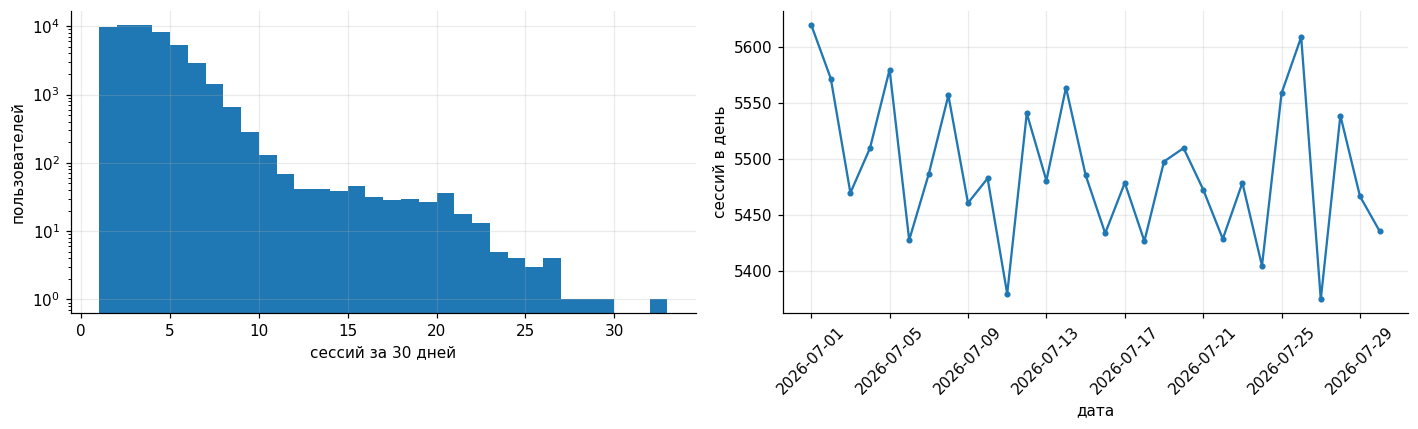

In [14]:
spu = sessions.groupby('user_id').size()
display(spu.describe().rename('сессий на пользователя').to_frame())

q99 = spu.quantile(0.99)
bots_preview = set(users.loc[users.is_bot_candidate == 1, 'user_id'])
high = spu[spu > q99]
print(f'99-й перцентиль: {q99:.0f} сессий, максимум: {spu.max()}')
print(f'Пользователей выше 99-го перцентиля: {len(high)}, из них помечены ботами: {high.index.isin(bots_preview).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(spu.values, bins=range(1, int(spu.max()) + 2))
axes[0].set_xlabel('сессий за 30 дней')
axes[0].set_ylabel('пользователей')
axes[0].set_yscale('log')

daily_ses = sessions.groupby(sessions.session_date.dt.date).size()
axes[1].plot(list(daily_ses.index), daily_ses.values, marker='o', markersize=3)
axes[1].set_xlabel('дата')
axes[1].set_ylabel('сессий в день')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Расхождений между таблицами нет вообще: устройство и регион в сессии всегда совпадают
с профилем пользователя, ни одна сессия не датирована раньше регистрации **и раньше
назначения в эксперимент**, все 50 000 пользователей имеют хотя бы одну сессию и все
сессии укладываются в окно 1-30 июля. Дневная динамика ровная, без провалов и всплесков,
логирование не прерывалось.

Отдельно отметим: **периода «до эксперимента» в данных нет**. Это лишает нас возможности
сделать A/A-проверку на исторических данных или использовать предэкспериментальные
ковариаты для повышения чувствительности (CUPED). Ограничение фиксируем.

Распределение сессий имеет тяжёлый правый хвост: медиана 3, 99-й перцентиль 10, максимум 32.
Флаг `is_bot_candidate` покрывает его в основном, но не один в один, детальный разбор в 1.6.

Поскольку `device` и `region` дублируются без конфликтов, для сегментации дальше
берём версию из `users`: она зафиксирована на уровне пользователя и не зависит
от того, сколько сессий он совершил.

## 1.5 Корректность распределения пользователей между группами

Это ключевой блок для A/B-теста. Проверяем четыре вещи: нет ли пользователей,
попавших в обе группы; сходятся ли размеры групп с ожидаемым сплитом (SRM);
сбалансированы ли группы по характеристикам, на которые эксперимент повлиять не мог;
и не смещает ли выборку само исключение проблемных пользователей.

In [15]:
print('строк в experiment_assignments:', len(assign))
print('уникальных пользователей      :', assign.user_id.nunique())
print()
print(assign.assignment_source.value_counts().to_string())
print()
print('Даты назначений по источнику:')
print(assign.groupby('assignment_source').assignment_date.agg(['min', 'max']).to_string())

строк в experiment_assignments: 50300
уникальных пользователей      : 50000

assignment_source
assignment_service        50000
assignment_service_bug      300

Даты назначений по источнику:
                              min        max
assignment_source                           
assignment_service     2026-07-01 2026-07-01
assignment_service_bug 2026-07-02 2026-07-06


In [16]:
per_user = assign.groupby('user_id').agg(назначений=('assignment_id', 'size'),
                                         разных_групп=('experiment_group', 'nunique'))

conflict_users = set(per_user.index[per_user.разных_групп > 1])

print('пользователей с более чем одним назначением :', int((per_user.назначений > 1).sum()))
print('пользователей, попавших в ОБЕ группы        :', len(conflict_users),
      f'({len(conflict_users) / assign.user_id.nunique() * 100:.2f}%)')
print('повторные назначения в ту же группу         :',
      int(((per_user.назначений > 1) & (per_user.разных_групп == 1)).sum()))
print()
print('Источник повторных назначений:')
print(assign[assign.user_id.isin(conflict_users)].assignment_source.value_counts().to_string())

пользователей с более чем одним назначением : 300
пользователей, попавших в ОБЕ группы        : 300 (0.60%)
повторные назначения в ту же группу         : 0

Источник повторных назначений:
assignment_source
assignment_service        300
assignment_service_bug    300


300 пользователей (0.6%) получили назначение и в control, и в test, и все повторные записи
пришли из источника `assignment_service_bug`, то есть это сбой сервиса рандомизации,
а не легитимная перезапись.

Важная деталь из таблицы дат выше: **все легитимные назначения датированы 1 июля,
а баговые 2-6 июля**. Значит «первое назначение» определено однозначно, без произвола,
и альтернативный вариант обработки (оставить пользователя в изначальной группе по логике ITT)
технически доступен. Мы проверим его в разделе 1.12.

Сначала выясним, насколько сбой испортил опыт этих пользователей: если такой
пользователь фактически видел оба варианта, отнести его к какой-то одной группе нельзя.

In [17]:
conf_sessions = sessions[sessions.user_id.isin(conflict_users)]
n_groups_in_sessions = conf_sessions.groupby('user_id').experiment_group.nunique()

print('сессий у конфликтных пользователей:', len(conf_sessions))
print('\nсколько разных вариантов реально видел пользователь:')
print(n_groups_in_sessions.value_counts().rename('пользователей').to_string())

mv = impr.merge(sessions[['session_id', 'experiment_group']], on='session_id')
print('\nВерсия модели в показах против группы сессии:')
print(pd.crosstab(mv.model_version, mv.experiment_group))

сессий у конфликтных пользователей: 1021

сколько разных вариантов реально видел пользователь:
experiment_group
2    185
1    115

Версия модели в показах против группы сессии:
experiment_group  control    test
model_version                    
ai_v2                   0  536188
baseline_v1        530246       0


Подтвердилось: 185 из 300 конфликтных пользователей действительно видели оба варианта
в разных сессиях. При этом на уровне сессии всё чисто, `model_version` в показах
на 100% соответствует группе сессии (`baseline_v1` только в control, `ai_v2` только в test),
то есть утечки самого варианта нет, испорчена именно принадлежность пользователя к группе.

Такие пользователи загрязняют обе группы одновременно и размывают эффект.
Основное решение состоит в том, чтобы исключить их из анализа целиком. Их 0.6%,
потеря мощности незначительна.

### 1.5.1 Не смещает ли исключение выборку

Аргумент «их всего 0.6%» говорит о потере **мощности**, но ничего не говорит о **смещении**.
Если сбой сервиса рандомизации задевал, скажем, преимущественно iOS-пользователей,
то исключение изменило бы состав выборки. Проверяем формально.

In [18]:
usr_excl = users.copy()
usr_excl['исключается'] = usr_excl.user_id.isin(conflict_users)

bias_rows = []
for col in ['device', 'region', 'age_group', 'traffic_source', 'is_premium', 'is_bot_candidate']:
    ct = pd.crosstab(usr_excl[col], usr_excl.исключается)
    bias_rows.append({'признак': col, 'критерий': 'chi2',
                      'p_value': round(stats.chi2_contingency(ct)[1], 4)})

tenure = (EXP_START - usr_excl.registration_date).dt.days
bias_rows.append({'признак': 'tenure_days', 'критерий': 'Mann-Whitney',
                  'p_value': round(stats.mannwhitneyu(tenure[usr_excl.исключается],
                                                      tenure[~usr_excl.исключается]).pvalue, 4)})
display(pd.DataFrame(bias_rows))

,признак,критерий,p_value
0,device,chi2,0.1875
1,region,chi2,0.1535
2,age_group,chi2,0.8372
3,traffic_source,chi2,0.1466
4,is_premium,chi2,0.5302
5,is_bot_candidate,chi2,0.5585
6,tenure_days,Mann-Whitney,0.0780


Ни по одному признаку значимых различий нет, минимальный p-value 0.15. Исключаемые
пользователи представляют собой случайную подвыборку, поэтому их удаление уменьшает объём
данных, но не сдвигает состав аудитории. Решение об исключении обосновано.

In [19]:
clean_assign = (assign[~assign.user_id.isin(conflict_users)]
                .drop_duplicates('user_id')[['user_id', 'experiment_group']])

vc_all   = first_assign.experiment_group.value_counts()
vc_clean = clean_assign.experiment_group.value_counts()

srm = pd.DataFrame({'до очистки': vc_all, 'после очистки': vc_clean})
srm.loc['всего'] = srm.sum()
display(srm)

n_c, n_t = int(vc_clean['control']), int(vc_clean['test'])
bt = stats.binomtest(n_c, n_c + n_t, 0.5)
print(f'Доля control после очистки: {n_c / (n_c + n_t):.4f}')
print(f'SRM-проверка (биномиальный тест против 50/50): p = {bt.pvalue:.4f}')

,до очистки,после очистки
experiment_group,,
test,25185,25026
control,24815,24674
всего,50000,49700


Доля control после очистки: 0.4965
SRM-проверка (биномиальный тест против 50/50): p = 0.1154


Sample Ratio Mismatch не обнаружен: наблюдаемая доля control составляет 49.65%
при ожидаемых 50%, p = 0.115. Отклонение укладывается в случайный разброс, так что
систематической проблемы с механизмом сплита нет и данные для сравнения групп пригодны.

Дальше идёт проверка баланса. Если рандомизация корректна, группы должны совпадать
по всем характеристикам, которые сформировались **до** эксперимента:
устройство, регион, возраст, источник трафика, премиум-статус на старте и стаж.

In [20]:
u_bal = users.merge(clean_assign, on='user_id')
u_bal['tenure_days'] = (EXP_START - u_bal.registration_date).dt.days

balance = []
for col in ['device', 'region', 'age_group', 'traffic_source', 'is_premium', 'is_bot_candidate']:
    ct = pd.crosstab(u_bal[col], u_bal.experiment_group)
    p = stats.chi2_contingency(ct)[1]
    balance.append({'признак': col, 'критерий': 'chi2', 'p_value': round(p, 4)})

tc = u_bal.loc[u_bal.experiment_group == 'control', 'tenure_days']
tt = u_bal.loc[u_bal.experiment_group == 'test', 'tenure_days']
balance.append({'признак': 'tenure_days', 'критерий': 'Mann-Whitney',
                'p_value': round(stats.mannwhitneyu(tc, tt).pvalue, 4)})

display(pd.DataFrame(balance))
print(f'Стаж, медиана дней: control {tc.median():.0f} | test {tt.median():.0f}')

,признак,критерий,p_value
0,device,chi2,0.1518
1,region,chi2,0.6367
2,age_group,chi2,0.6638
3,traffic_source,chi2,0.1983
4,is_premium,chi2,0.3347
5,is_bot_candidate,chi2,0.8083
6,tenure_days,Mann-Whitney,0.3802


Стаж, медиана дней: control 164 | test 165


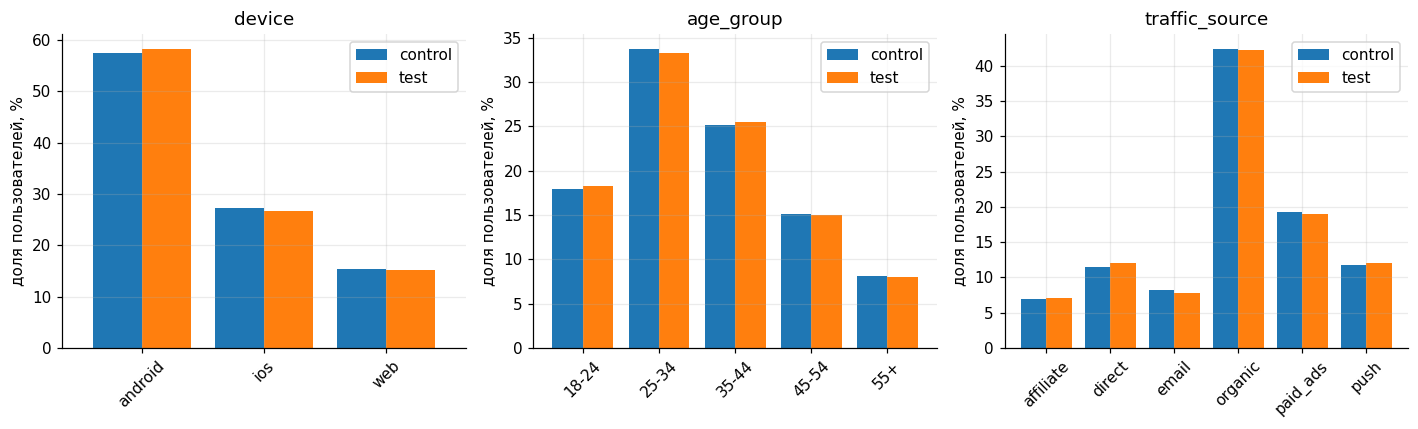

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ['device', 'age_group', 'traffic_source']):
    share = pd.crosstab(u_bal[col], u_bal.experiment_group, normalize='columns') * 100
    share.plot(kind='bar', ax=ax, width=0.8)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('доля пользователей, %')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='')
plt.tight_layout()
plt.show()

Все проверки баланса проходят: минимальный p-value среди признаков равен 0.15,
медианный стаж отличается на один день. Группы сопоставимы, поэтому наблюдаемые
различия в метриках можно интерпретировать как эффект самой модели, а не как
следствие разного состава аудитории.

## 1.6 Аномальная активность: бот-подобные пользователи

В `users` есть флаг `is_bot_candidate`. Его нельзя просто принять на веру или просто
проигнорировать: надо понять, какой вклад эти пользователи вносят в метрики
и насколько сам флаг согласуется с наблюдаемым поведением.

In [22]:
bots = set(users.loc[users.is_bot_candidate == 1, 'user_id'])
print(f'Помечено как боты: {len(bots)} пользователей ({len(bots) / len(users) * 100:.2f}%)')

contrib = pd.DataFrame({
    'сущность': ['пользователи', 'сессии', 'показы', 'клики', 'заказы', 'GMV'],
    'доля_ботов_%': [
        len(bots) / len(users) * 100,
        sessions.user_id.isin(bots).mean() * 100,
        impr.user_id.isin(bots).mean() * 100,
        clicks.user_id.isin(bots).mean() * 100,
        orders.user_id.isin(bots).mean() * 100,
        orders.loc[orders.user_id.isin(bots), 'gmv_rub'].sum() / orders.gmv_rub.sum() * 100,
    ]
}).round(2)
display(contrib)

sess_per_user = sessions.groupby('user_id').size()
print('Сессий на пользователя, медиана:')
print(f'  боты    : {sess_per_user[sess_per_user.index.isin(bots)].median():.0f}')
print(f'  обычные : {sess_per_user[~sess_per_user.index.isin(bots)].median():.0f}')

print('\nCTR:')
print(f'  боты    : {impr.loc[impr.user_id.isin(bots), "is_clicked"].mean() * 100:.2f}%')
print(f'  обычные : {impr.loc[~impr.user_id.isin(bots), "is_clicked"].mean() * 100:.2f}%')

Помечено как боты: 400 пользователей (0.80%)


,сущность,доля_ботов_%
0,пользователи,0.8000
1,сессии,3.9100
2,показы,3.9100
3,клики,8.2500
4,заказы,0.4900
5,GMV,0.4400


Сессий на пользователя, медиана:
  боты    : 16
  обычные : 3

CTR:
  боты    : 18.03%
  обычные : 8.17%


In [23]:
overlap = pd.DataFrame({
    'сессий: min': [sess_per_user[sess_per_user.index.isin(bots)].min(),
                    sess_per_user[~sess_per_user.index.isin(bots)].min()],
    'медиана':     [sess_per_user[sess_per_user.index.isin(bots)].median(),
                    sess_per_user[~sess_per_user.index.isin(bots)].median()],
    'max':         [sess_per_user[sess_per_user.index.isin(bots)].max(),
                    sess_per_user[~sess_per_user.index.isin(bots)].max()],
}, index=['помечены ботами', 'остальные'])
display(overlap)

unflagged_high = high[~high.index.isin(bots)]
print(f'Выше 99-го перцентиля ({q99:.0f} сессий): {len(high)} пользователей, '
      f'из них НЕ помечены: {len(unflagged_high)}')
print(f'  у непомеченных сессий: от {unflagged_high.min():.0f} до {unflagged_high.max():.0f}, '
      f'медиана {unflagged_high.median():.0f}')
print(f'Помеченных ботами НИЖЕ 99-го перцентиля: {len(bots) - high.index.isin(bots).sum()}')

,сессий: min,медиана,max
помечены ботами,7,16.0000,32
остальные,1,3.0000,16


Выше 99-го перцентиля (10 сессий): 441 пользователей, из них НЕ помечены: 70
  у непомеченных сессий: от 11 до 16, медиана 11
Помеченных ботами НИЖЕ 99-го перцентиля: 29


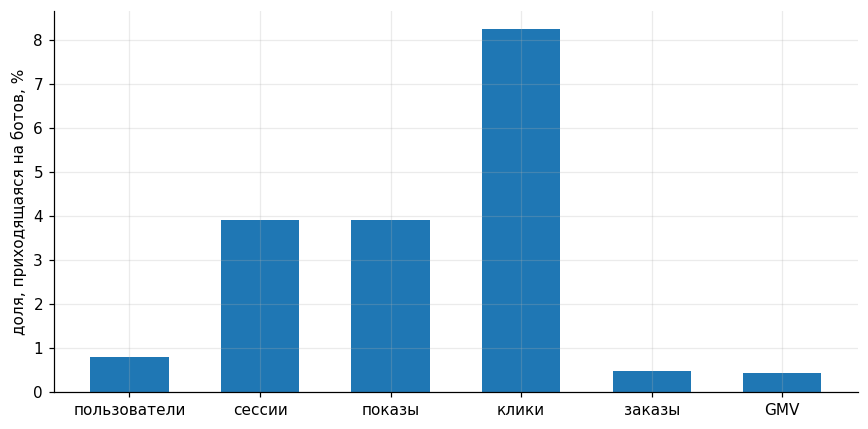

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(contrib['сущность'], contrib['доля_ботов_%'], width=0.6)
ax.set_ylabel('доля, приходящаяся на ботов, %')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

Картина однозначная. Бот-подобных пользователей всего 0.8%, но на них приходится 3.9% показов
и **8.3% всех кликов**, при этом лишь 0.5% заказов и 0.4% GMV. Их медианная активность
составляет 16 сессий против 3 у обычного пользователя, а CTR примерно втрое выше.

То есть эта горстка аккаунтов кликает много, а покупает почти ничего. Если оставить их
в выборке, CTR будет систематически завышен, а конверсия из клика в заказ занижена,
причём для обеих групп сразу.

**Насколько флаг надёжен.** Диапазоны активности помеченных и обычных пользователей
перекрываются: у ботов минимум 7 сессий, у обычных максимум 16. Из 441 пользователя
выше 99-го перцентиля 70 не помечены, но их активность (11-16 сессий, медиана 11)
лежит в пределах правдоподобного поведения живого человека, оснований считать их
пропущенными ботами нет. Одновременно 29 помеченных ботов сами находятся ниже
99-го перцентиля. Вывод: флаг задан внешней разметкой и не воспроизводится точно
по одному лишь числу сессий, но содержательно он выделяет именно ту группу,
у которой аномально высокий CTR при почти нулевых покупках.

Критично, что рандомизация развела ботов между группами поровну (p = 0.81 в таблице
баланса выше), значит источником смещения эффекта они быть не могут, только
источником искажения абсолютных уровней.

**Решение:** исключаем ботов из основного анализа, но обязательно показываем
результат и с ними, и без них, чтобы было видно, что вывод не держится на этом решении.

## 1.7 Границы окна наблюдения: возвраты и обращения в поддержку

Самое неочевидное место датасета. Эксперимент шёл 30 дней, а возврат товара
и обращение в поддержку происходят существенно позже покупки. Разберём обе метрики
отдельно, выводы по ним получатся **разные**.

In [25]:
returned = orders.dropna(subset=['return_date']).copy()
returned['lag_days'] = (returned.return_date - returned.order_date).dt.days

print('Всего возвратов:', len(returned))
print(f'Лаг возврата, дней: медиана {returned.lag_days.median():.0f}, '
      f'мин {returned.lag_days.min():.0f}, макс {returned.lag_days.max():.0f}')
after = (returned.return_date > EXP_END).sum()
print(f'\nВозвратов ПОСЛЕ окна наблюдения: {after} ({after / len(returned) * 100:.1f}% всех возвратов)')
print(f'Последняя дата возврата в данных: {returned.return_date.max().date()}')

Всего возвратов: 462
Лаг возврата, дней: медиана 22, мин 3, макс 37

Возвратов ПОСЛЕ окна наблюдения: 300 (64.9% всех возвратов)
Последняя дата возврата в данных: 2026-09-04


In [26]:
LAST_RET = returned.return_date.max()
o_chk = orders.copy()
o_chk['день_заказа'] = (o_chk.order_date - EXP_START).dt.days
o_chk['неделя']      = o_chk['день_заказа'] // 7
o_chk['запас_дней']  = (LAST_RET - o_chk.order_date).dt.days

by_week = o_chk.groupby('неделя').agg(
    заказов=('order_id', 'size'),
    return_rate=('is_returned', 'mean'),
    мин_запас_дней=('запас_дней', 'min'))
by_week['макс_лаг_в_данных'] = returned.lag_days.max()
display(by_week.round(4))

print(f'Минимальный запас времени по всем заказам : {o_chk.запас_дней.min():.0f} дней')
print(f'Максимальный наблюдённый лаг возврата     : {returned.lag_days.max():.0f} дней')
print(f'Заказов с запасом меньше максимального лага: {int((o_chk.запас_дней < returned.lag_days.max()).sum())} '
      f'({(o_chk.запас_дней < returned.lag_days.max()).mean() * 100:.1f}%)')

o_chk['возврат_в_окне'] = ((o_chk.is_returned == 1) & (o_chk.return_date <= EXP_END)).astype(int)
print(f'\nReturn Rate по полной истории  : {o_chk.is_returned.mean() * 100:.2f}%')
print(f'Return Rate «только внутри окна»: {o_chk.возврат_в_окне.mean() * 100:.2f}%')

,заказов,return_rate,мин_запас_дней,макс_лаг_в_данных
неделя,,,,
0,1769,0.0701,59,37
1,1737,0.0581,52,37
2,1750,0.0577,45,37
3,1653,0.0641,38,37
4,498,0.0602,36,37


Минимальный запас времени по всем заказам : 36 дней
Максимальный наблюдённый лаг возврата     : 37 дней
Заказов с запасом меньше максимального лага: 245 (3.3%)

Return Rate по полной истории  : 6.24%
Return Rate «только внутри окна»: 2.19%


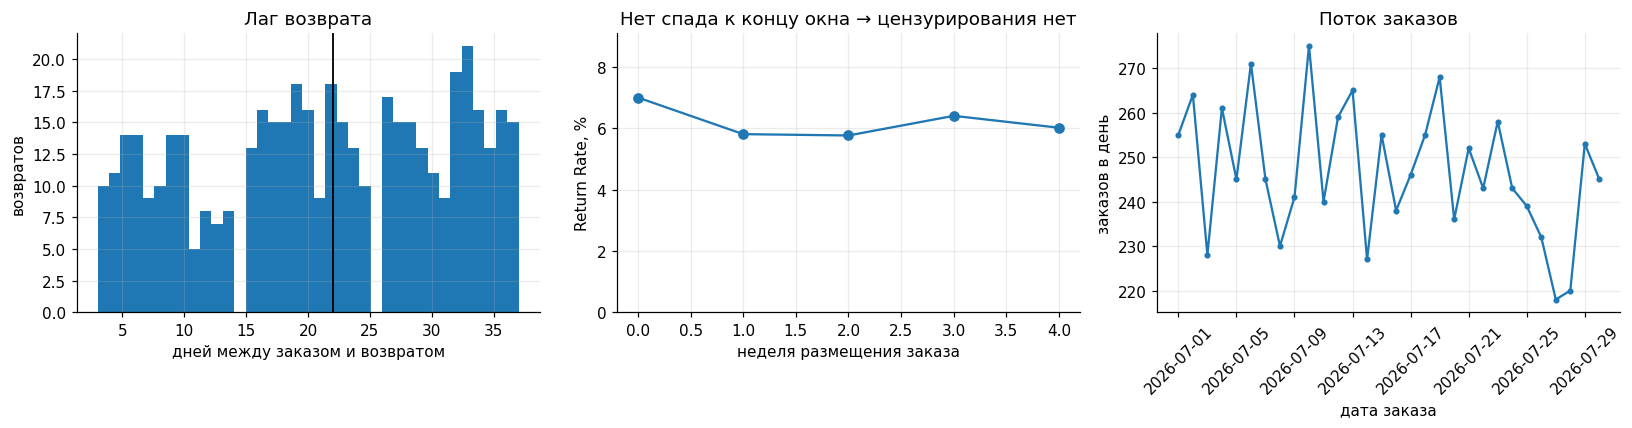

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(returned.lag_days, bins=37)
axes[0].axvline(returned.lag_days.median(), linestyle='-', linewidth=1.2, color='black')
axes[0].set_xlabel('дней между заказом и возвратом')
axes[0].set_ylabel('возвратов')
axes[0].set_title('Лаг возврата')

axes[1].plot(by_week.index, by_week.return_rate * 100, marker='o')
axes[1].set_xlabel('неделя размещения заказа')
axes[1].set_ylabel('Return Rate, %')
axes[1].set_title('Нет спада к концу окна → цензурирования нет')
axes[1].set_ylim(0, by_week.return_rate.max() * 130)

daily = orders.groupby(orders.order_date.dt.date).size()
axes[2].plot(list(daily.index), daily.values, marker='o', markersize=3)
axes[2].set_xlabel('дата заказа')
axes[2].set_ylabel('заказов в день')
axes[2].set_title('Поток заказов')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Возвраты: цензурирования нет, и это надо доказать

Медианный возврат случается через 22 дня после заказа, и **65% всех возвратов приходятся
на период после окончания эксперимента**, вплоть до 4 сентября. Отсюда легко сделать
неверный вывод, что данные обрезаны и Return Rate представляет собой нижнюю оценку.
Проверка показывает обратное:

- **минимальный запас времени** у самого позднего заказа составляет 36 дней,
  а максимальный наблюдённый лаг возврата за всю историю 37 дней;
- **Return Rate по неделям размещения заказа не падает к концу окна** (график в центре):
  7.0%, 5.8%, 5.8%, 6.4%, 6.0%. Если бы поздние заказы не успевали вернуться,
  здесь был бы явный спад.

Значит история возвратов в датасете **практически полная**, и правостороннее цензурирование
для метрики по полной истории отсутствует. Оговорка остаётся минимальной: у 245 заказов
(3.3%) запас на один день меньше максимального наблюдённого лага.

**Практический вывод, и он крупный.** Наивное «обрежем всё за пределами 30-дневного окна»
даёт Return Rate 2.19% вместо 6.24%, то есть заниженную почти втрое оценку, при которой
модель выглядела бы почти бесплатной. Правильное действие здесь состоит в том, чтобы
**не обрезать данные**, а использовать полную историю возвратов. Обе версии метрики
мы считаем в витрине (`returns_all` и `returns_in_window`) и сравниваем в разделе 4.

In [28]:
print('Последний тикет:', tickets.ticket_date.max().date(),
      '| последний возврат:', returned.return_date.max().date())

tk = tickets.merge(orders[['order_id', 'is_returned', 'return_date']], on='order_id', how='left')
LAST_TICKET = tickets.ticket_date.max()

print(f'\nтикетов всего: {len(tickets)}')
print(f'  из них после окна эксперимента: {int((tickets.ticket_date > EXP_END).sum())}')
print(f'  привязано к возвращённым заказам: {int((tk.is_returned == 1).sum())}')
print(f'\nвозвратов, случившихся ПОСЛЕ последнего тикета ({LAST_TICKET.date()}): '
      f'{int((returned.return_date > LAST_TICKET).sum())} из {len(returned)} '
      f'({(returned.return_date > LAST_TICKET).mean() * 100:.0f}%)')

tk_grp = tickets.merge(first_assign, on='user_id')
print('\nтикетов по группам:')
print(tk_grp.groupby('experiment_group').size().rename('тикетов').to_string())

Последний тикет: 2026-08-03 | последний возврат: 2026-09-04

тикетов всего: 337
  из них после окна эксперимента: 27
  привязано к возвращённым заказам: 77

возвратов, случившихся ПОСЛЕ последнего тикета (2026-08-03): 247 из 462 (53%)

тикетов по группам:
experiment_group
control    133
test       204


### Поддержка: вот здесь усечение реальное

С обращениями в поддержку картина **противоположная**, и объединять их с возвратами
в одну оговорку нельзя:

- возвраты доведены до 4 сентября, история полная;
- тикеты обрываются **3 августа**, всего через 4 дня после конца окна.

При этом **247 из 462 возвратов происходят уже после 3 августа**, а 77 тикетов
в датасете привязаны именно к возвращённым заказам. То есть по августовским
и сентябрьским возвратам обращения в поддержку физически не могли попасть в выгрузку.

Поскольку возвратов больше в тестовой группе, **недоучёт тикетов сильнее бьёт именно
по ней**. Значит наблюдаемый рост обращений в поддержку в test представляет собой
**нижнюю оценку**, и реальный разрыв, вероятно, больше. Для итоговой рекомендации
это существенно: обращения в поддержку составляют прямую операционную стоимость модели,
и занижать её нельзя.

Отдельно помним про объём: 337 тикетов на обе группы. Любые разрезы этой метрики
по сегментам будут статистически неустойчивы.

## 1.8 Аномалии в числовых полях и бизнес-логике

In [29]:
display(orders[['gmv_rub', 'discount_rub', 'delivery_fee_rub', 'gross_margin_rub']].describe())

checks = {
    'gmv_rub <= 0':                        int((orders.gmv_rub <= 0).sum()),
    'discount_rub < 0':                    int((orders.discount_rub < 0).sum()),
    'discount_rub >= gmv_rub':             int((orders.discount_rub >= orders.gmv_rub).sum()),
    'delivery_fee_rub < 0':                int((orders.delivery_fee_rub < 0).sum()),
    'gross_margin_rub < 0':                int((orders.gross_margin_rub < 0).sum()),
    '  ...из них возвраты':                int(((orders.gross_margin_rub < 0) & (orders.is_returned == 1)).sum()),
    'return_date раньше order_date':       int((returned.return_date < returned.order_date).sum()),
    'session_duration_sec <= 0':           int((sessions.session_duration_sec <= 0).sum()),
    'page_views <= 0':                     int((sessions.page_views <= 0).sum()),
    'gross_margin_rate вне [0, 1]':        int(((products.gross_margin_rate < 0) | (products.gross_margin_rate > 1)).sum()),
    'product_rating вне [1, 5]':           int(((products.product_rating < 1) | (products.product_rating > 5)).sum()),
    'категория заказа != категории товара': int(orders.merge(products[['product_id', 'category']], on='product_id',
                                                             suffixes=('_o', '_p'))
                                                     .eval('category_o != category_p').sum()),
    'регистрация после старта эксперимента': int((users.registration_date > EXP_START).sum()),
}
pd.Series(checks, name='нарушений').to_frame()

,gmv_rub,discount_rub,delivery_fee_rub,gross_margin_rub
count,"7,407.0000","7,407.0000","7,104.0000","7,407.0000"
mean,"1,676.4642",67.1890,150.4569,274.4980
std,"1,645.5829",126.0133,109.2412,257.1337
min,84.0000,0.0000,0.0000,-331.9800
25%,615.0000,0.0000,16.5000,103.9650
50%,"1,165.0000",24.0000,166.0000,213.7700
75%,"2,140.5000",79.0000,233.0000,382.9950
max,"21,926.0000","2,193.0000",481.0000,"2,433.0400"


,нарушений
gmv_rub <= 0,0
discount_rub < 0,0
discount_rub >= gmv_rub,0
delivery_fee_rub < 0,0
gross_margin_rub < 0,462
...из них возвраты,462
return_date раньше order_date,0
session_duration_sec <= 0,0
page_views <= 0,0
"gross_margin_rate вне [0, 1]",0


Грубых нарушений нет. Отрицательная маржа встречается ровно у 462 заказов, и это
в точности все возвращённые заказы, что соответствует бизнес-логике: возврат съедает
маржу и оставляет компанию в небольшом минусе на логистике. Категория заказа всегда
совпадает с категорией товара из каталога, рейтинги и ставки маржи лежат в допустимых границах.

**Следствие для расчёта маржи:** поскольку `gross_margin_rub` уже отрицательна
у возвращённых заказов, потери от возвратов в ней **учтены**. Вычитать их повторно нельзя.

Отдельно стоит посмотреть на распределение GMV: там есть длинный правый хвост,
который повлияет на выбор статистического критерия при сравнении среднего чека.

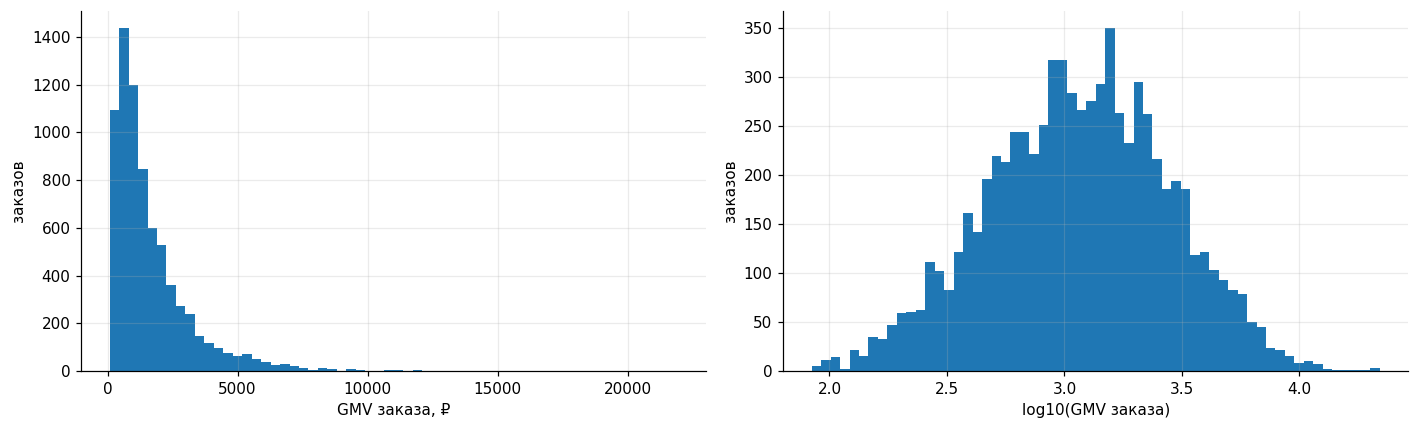

GMV: медиана 1,165 ₽, среднее 1,676 ₽, максимум 21,926 ₽
Асимметрия распределения: 3.07


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(orders.gmv_rub, bins=60)
axes[0].set_xlabel('GMV заказа, ₽')
axes[0].set_ylabel('заказов')

axes[1].hist(np.log10(orders.gmv_rub), bins=60)
axes[1].set_xlabel('log10(GMV заказа)')
axes[1].set_ylabel('заказов')
plt.tight_layout()
plt.show()

print(f'GMV: медиана {orders.gmv_rub.median():,.0f} ₽, среднее {orders.gmv_rub.mean():,.0f} ₽, '
      f'максимум {orders.gmv_rub.max():,.0f} ₽')
print(f'Асимметрия распределения: {stats.skew(orders.gmv_rub):.2f}')

Распределение GMV сильно скошено вправо (асимметрия ≈ 3), среднее почти в полтора раза
выше медианы. Значит, при сравнении среднего чека нельзя опираться на один только t-тест:
понадобится либо бутстрап, либо непараметрический критерий, либо и то и другое.
Зафиксируем это как вводную к разделу 4.

## 1.9 Премиум-статус меняется внутри эксперимента

In [31]:
print('users.is_premium = 1                            :', int(users.is_premium.sum()))
print('уникальных пользователей в premium_subscriptions:', premium.user_id.nunique())
print('строк в premium_subscriptions                   :', len(premium))
print()
prem_users = set(premium.user_id)
print('is_premium=1, но нет строки о подписке          :',
      int((~users.loc[users.is_premium == 1, 'user_id'].isin(prem_users)).sum()))
print('есть подписка, но is_premium=0                  :',
      int(users[(users.is_premium == 0) & (users.user_id.isin(prem_users))].shape[0]))
print()
in_window = premium[(premium.premium_start_date >= EXP_START) & (premium.premium_start_date <= EXP_END)]
print(f'Подписок, оформленных внутри окна эксперимента  : {len(in_window)}')
print(in_window.is_trial.value_counts().rename('подписок').to_string())

users.is_premium = 1                            : 8254
уникальных пользователей в premium_subscriptions: 9127
строк в premium_subscriptions                   : 9127

is_premium=1, но нет строки о подписке          : 0
есть подписка, но is_premium=0                  : 873

Подписок, оформленных внутри окна эксперимента  : 945
is_trial
1    511
0    434


In [32]:
prem_chk = premium.merge(users[['user_id', 'is_premium']], on='user_id')
prem_chk['началась_в_окне'] = ((prem_chk.premium_start_date >= EXP_START) &
                               (prem_chk.premium_start_date <= EXP_END))

tab = pd.crosstab(prem_chk.началась_в_окне, prem_chk.is_premium,
                  rownames=['подписка началась внутри окна'], colnames=['is_premium на старте'])
display(tab)

contradiction = int(((prem_chk.началась_в_окне) & (prem_chk.is_premium == 1)).sum())
print(f'ПРОТИВОРЕЧИЕ: подписка началась внутри окна, но is_premium=1 на старте: {contradiction}')
print(f'Корректных конверсий (началась в окне, is_premium=0)                  : '
      f'{int(((prem_chk.началась_в_окне) & (prem_chk.is_premium == 0)).sum())}')
print(f'Подписок до окна у пользователей с is_premium=0                       : '
      f'{int(((~prem_chk.началась_в_окне) & (prem_chk.is_premium == 0)).sum())}')

is_premium на старте,0,1
подписка началась внутри окна,,
False,0,8182
True,873,72


ПРОТИВОРЕЧИЕ: подписка началась внутри окна, но is_premium=1 на старте: 72
Корректных конверсий (началась в окне, is_premium=0)                  : 873
Подписок до окна у пользователей с is_premium=0                       : 0


Поле `users.is_premium` описывает статус **на момент старта эксперимента**, а
`premium_subscriptions` содержит и подписки, оформленные уже во время теста, 945 штук,
из них больше половины триальные. Расхождение в 873 пользователя объясняется именно этим.

**Найденная аномалия.** У 72 записей подписка начинается внутри окна эксперимента,
но при этом `is_premium = 1`, то есть пользователь якобы уже был премиумом на 1 июля.
Это логическое противоречие: нельзя иметь Premium на старте, если подписка оформлена
5 июля. Проверка границ показывает, что несогласованность локализована ровно в этих
72 строках: подписок до окна у пользователей с `is_premium=0` нет вовсе, как нет
и премиумов без строки о подписке.

На расчёт Premium Conversion это не влияет: фильтр `is_premium == 0` отсекает такие записи
автоматически, и корректных конверсий остаётся 873. Но как дефект качества данных
аномалию фиксируем.

**Практический вывод двойной:** `is_premium` можно использовать как сегментирующий
признак (он зафиксирован до воздействия и потому не загрязнён экспериментом),
а метрику Premium Conversion надо считать по `premium_subscriptions` с фильтром на окно,
причём среди тех, у кого подписки на старте не было.

## 1.10 Базовые метрики до очистки

Прежде чем что-либо менять, фиксируем метрики на **сыром** датасете: со всеми ботами,
дублями показов и задвоенными назначениями. Эти числа не являются результатом
исследования, они нужны как точка отсчёта, чтобы в разделе 1.12 показать, насколько
выводы зависят от качества подготовки данных.

Для каждой метрики сохраняем не только значение, но и **числитель со знаменателем**,
иначе будет непонятно, за счёт чего именно она изменилась.

Обратите внимание на первую строку вывода: наивное присоединение таблицы назначений
размножает строки задвоенных пользователей, и их события попадают в обе группы сразу.

In [33]:
def build_user_mart(users_df, assign_df, sessions_df, impr_df, clicks_df, orders_df):
    '''Одна строка = один пользователь. Все счётчики агрегируются из событийных таблиц.'''
    m = users_df.merge(assign_df, on='user_id', how='inner')

    agg_ses = sessions_df.groupby('user_id').agg(
        sessions=('session_id', 'size'),
        total_duration=('session_duration_sec', 'sum'),
        page_views=('page_views', 'sum'))
    agg_imp = impr_df.groupby('user_id').agg(impressions=('impression_id', 'size'))
    agg_clk = clicks_df.groupby('user_id').agg(clicks=('click_id', 'size'))

    ord_in = orders_df.copy()
    ord_in['returned_in_window'] = ((ord_in.is_returned == 1) &
                                    (ord_in.return_date <= EXP_END)).astype(int)
    agg_ord = ord_in.groupby('user_id').agg(
        orders=('order_id', 'size'),
        gmv=('gmv_rub', 'sum'),
        margin=('gross_margin_rub', 'sum'),
        returns_all=('is_returned', 'sum'),
        returns_in_window=('returned_in_window', 'sum'))

    m = (m.join(agg_ses, on='user_id')
           .join(agg_imp, on='user_id')
           .join(agg_clk, on='user_id')
           .join(agg_ord, on='user_id'))

    fill0 = ['sessions', 'total_duration', 'page_views', 'impressions', 'clicks',
             'orders', 'gmv', 'margin', 'returns_all', 'returns_in_window']
    m[fill0] = m[fill0].fillna(0)

    m['tenure_days'] = (EXP_START - m.registration_date).dt.days
    m['converted']   = (m.orders > 0).astype(int)

    new_prem = set(premium.loc[(premium.premium_start_date >= EXP_START) &
                               (premium.premium_start_date <= EXP_END), 'user_id'])
    m['premium_converted'] = ((m.user_id.isin(new_prem)) & (m.is_premium == 0)).astype(int)

    tick_cnt = tickets.groupby('user_id').size().rename('tickets')
    m = m.join(tick_cnt, on='user_id')
    m['tickets'] = m.tickets.fillna(0)
    return m

In [34]:
METRIC_ORDER = [
    'CTR (по показам)', 'CTR (по пользователям)', 'Click→Order CR', 'Orders per user',
    'AOV, ₽', 'GMV per user (ARPU), ₽', 'Margin per user, ₽',
    'Return Rate (полная история)', 'Return Rate (внутри окна)',
    'Repeat purchase rate', 'Premium CR', 'Support rate (на пользователя)',
    'Sessions per user', 'Impressions per session',
]

def metrics(mart, stage):
    '''Свернуть витрину в tidy-набор метрик по группам: stage|group|metric|num|den|value.'''
    rows = []
    for grp, g in mart.groupby('experiment_group'):
        n_users = len(g)
        imp, clk = g.impressions.sum(), g.clicks.sum()
        ords, gmv, marg = g.orders.sum(), g.gmv.sum(), g.margin.sum()
        ret_a, ret_w = g.returns_all.sum(), g.returns_in_window.sum()
        tick, prem, sess = g.tickets.sum(), g.premium_converted.sum(), g.sessions.sum()
        buyers, repeat = (g.orders >= 1).sum(), (g.orders >= 2).sum()
        premium_eligible = (g.is_premium == 0).sum()

        specs = [
            ('CTR (по показам)',              clk,    imp),
            ('Click→Order CR',                ords,   clk),
            ('Orders per user',               ords,   n_users),
            ('AOV, ₽',                        gmv,    ords),
            ('GMV per user (ARPU), ₽',        gmv,    n_users),
            ('Margin per user, ₽',            marg,   n_users),
            ('Return Rate (полная история)',  ret_a,  ords),
            ('Return Rate (внутри окна)',     ret_w,  ords),
            ('Repeat purchase rate',          repeat, buyers),
            ('Premium CR',                    prem,   premium_eligible),
            ('Support rate (на пользователя)', tick,  n_users),
            ('Sessions per user',             sess,   n_users),
            ('Impressions per session',       imp,    sess),
        ]
        for name, num, den in specs:
            rows.append({'stage': stage, 'group': grp, 'metric': name,
                         'num': num, 'den': den,
                         'value': num / den if den else np.nan})

        exposed = g[g.impressions > 0]
        rows.append({'stage': stage, 'group': grp, 'metric': 'CTR (по пользователям)',
                     'num': np.nan, 'den': len(exposed),
                     'value': (exposed.clicks / exposed.impressions).mean()})
    return pd.DataFrame(rows)


def compare(m, stage):
    '''Развернуть метрики одного этапа в таблицу control / test / дельта.'''
    p = (m[m.stage == stage].pivot(index='metric', columns='group', values='value')
         .reindex(METRIC_ORDER))
    p['Δ абс.'] = p.test - p.control
    p['Δ %']    = (p.test / p.control - 1) * 100
    return p.round(4)

In [35]:
mart_naive = build_user_mart(users, assign[['user_id', 'experiment_group']],
                             sessions, impr, clicks, orders)

print(f'пользователей в users            : {len(users):,}')
print(f'строк в наивной витрине          : {len(mart_naive):,}  '
      f'(+{len(mart_naive) - len(users)} за счёт задвоенных назначений)')
print(f'показов учтено                   : {mart_naive.impressions.sum():,.0f}  '
      f'(в impressions всего {len(impr):,})')
print(f'заказов учтено                   : {mart_naive.orders.sum():,.0f}  '
      f'(в orders всего {len(orders):,})')

m_all = metrics(mart_naive, 'naive')
compare(m_all, 'naive')

пользователей в users            : 50,000
строк в наивной витрине          : 50,300  (+300 за счёт задвоенных назначений)
показов учтено                   : 1,073,049  (в impressions всего 1,066,434)
заказов учтено                   : 7,451  (в orders всего 7,407)


group,control,test,Δ абс.,Δ %
metric,,,,
CTR (по показам),0.0765,0.0945,0.0180,23.5092
CTR (по пользователям),0.0760,0.0940,0.0179,23.5615
Click→Order CR,0.0776,0.0839,0.0063,8.1189
Orders per user,0.1269,0.1690,0.0421,33.1703
"AOV, ₽","1,664.8274","1,687.6337",22.8063,1.3699
"GMV per user (ARPU), ₽",211.3199,285.2705,73.9506,34.9946
"Margin per user, ₽",35.1515,46.1262,10.9747,31.2211
Return Rate (полная история),0.0546,0.0677,0.0132,24.1269
Return Rate (внутри окна),0.0199,0.0234,0.0035,17.5367


Наивная витрина завышает объёмы: показов учтено на 6 615 больше, чем есть в `impressions`,
заказов на 44 больше, чем в `orders`. Это события 300 задвоенных пользователей,
посчитанные дважды и попавшие в обе группы одновременно.

Отдельно обратите внимание на две строки Return Rate: по полной истории 5.5% против 6.8%,
«внутри окна» 2.0% против 2.3%. Оценка, обрезанная по окну, занижена почти втрое,
причём вместе с уровнем сжимается и сам эффект: +24% превращаются в +18%. Это подтверждает
разбор из раздела 1.7: обрезка по окну не просто занижает метрику, она искажает вывод.

## 1.11 Итог аудита: правила очистки и витрина

Сводка найденного и принятых решений:

| Проблема | Масштаб | Решение |
|---|---|---|
| Пользователи в обеих группах (`assignment_service_bug`) | 300 (0.6%), из них 185 реально видели оба варианта | Исключить полностью. Смещения не вносит (все p > 0.15) |
| Бот-подобные пользователи | 400 (0.8%), но 8.3% кликов и 0.4% GMV | Исключить из основного расчёта, показать чувствительность |
| События, помеченные `is_duplicate_event` | 3 193 (0.30%); фактических повторов не обнаружено | Удалить, следуя разметке источника; цена вопроса 310 кликов и 25 заказов |
| Пропуски `delivery_fee_rub` | 303 (4.1%), механизм близок к MCAR | Строки сохранить; на GMV и маржу не влияет |
| Пропуски `return_date` | 93.8% | Не пропуск, структурное отсутствие |
| Возвраты за пределами окна | 65% всех возвратов | **Не обрезать.** Цензурирования нет (запас 36 дней при макс. лаге 37) |
| Обращения в поддержку | обрываются 3 августа, 247 возвратов позже | Метрика занижена, сильнее в test. Учесть при интерпретации |
| Противоречие `is_premium` и даты подписки | 72 записи | На метрики не влияет; зафиксировано как дефект |
| Сильная скошенность GMV | асимметрия около 3 | Бутстрап и непараметрические критерии в разделе 4 |
| SRM, баланс ковариат | отклонений нет (p = 0.115; все p > 0.15) | Данные пригодны для сравнения групп |
| Отсутствие предэкспериментального периода | нет данных до 1 июля | A/A-проверка и CUPED недоступны |

Собираем очищенные таблицы и витрину, которая станет основой для всех следующих разделов.

In [36]:
EXCLUDED = conflict_users | bots
print(f'Исключаем пользователей: {len(EXCLUDED)} ({len(EXCLUDED) / len(users) * 100:.2f}% аудитории)')

users_c    = users[~users.user_id.isin(EXCLUDED)].copy()
assign_c   = clean_assign[~clean_assign.user_id.isin(EXCLUDED)].copy()
sessions_c = sessions[~sessions.user_id.isin(EXCLUDED)].copy()
impr_c     = impr[(~impr.user_id.isin(EXCLUDED)) & (impr.is_duplicate_event == 0)].copy()
clicks_c   = clicks[(~clicks.user_id.isin(EXCLUDED)) &
                    (clicks.impression_id.isin(set(impr_c.impression_id)))].copy()
orders_c   = orders[(~orders.user_id.isin(EXCLUDED)) &
                    (orders.click_id.isin(set(clicks_c.click_id)))].copy()

kept = pd.DataFrame({
    'до очистки':    [len(users), len(sessions), len(impr), len(clicks), len(orders)],
    'после очистки': [len(users_c), len(sessions_c), len(impr_c), len(clicks_c), len(orders_c)],
}, index=['users', 'sessions', 'impressions', 'clicks', 'orders'])
kept['потеряно_%'] = ((1 - kept['после очистки'] / kept['до очистки']) * 100).round(2)
kept

Исключаем пользователей: 699 (1.40% аудитории)


,до очистки,после очистки,потеряно_%
users,50000,49301,1.4000
sessions,164739,157302,4.5100
impressions,1066434,1015160,4.8100
clicks,91266,82916,9.1500
orders,7407,7302,1.4200


In [37]:
user_mart = build_user_mart(users_c, assign_c, sessions_c, impr_c, clicks_c, orders_c)
print('Витрина:', user_mart.shape)
print(user_mart.groupby('experiment_group').size().rename('пользователей').to_string())
user_mart.head()

Витрина: (49301, 23)
experiment_group
control    24473
test       24828


,user_id,registration_date,region,device,age_group,traffic_source,is_premium,is_bot_candidate,experiment_group,sessions,total_duration,page_views,impressions,clicks,orders,gmv,margin,returns_all,returns_in_window,tenure_days,converted,premium_converted,tickets
0,u_000001,2026-04-29,Volga,android,18-24,paid_ads,0,0,control,2,362,10,15.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,63,0,0,0.0000
1,u_000002,2026-02-25,Central Russia,android,35-44,direct,0,0,test,1,116,6,6.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,126,0,0,0.0000
2,u_000003,2026-04-01,Moscow,web,18-24,push,1,0,control,3,869,20,21.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,91,0,0,0.0000
3,u_000004,2026-03-08,Ural,ios,25-34,paid_ads,0,0,control,3,667,17,14.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,115,0,0,0.0000
4,u_000005,2025-07-28,Central Russia,android,18-24,organic,1,0,test,4,1022,30,25.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,338,0,0,0.0000


## 1.12 Проверка устойчивости выводов к правилам очистки

Прежде чем идти дальше, убедимся, что принятые решения не «делают» результат.
Сначала сравним весь набор метрик до и после очистки, затем разберём вклад
каждого фильтра по отдельности.

In [38]:
m_all = pd.concat([m_all, metrics(user_mart, 'cleaned')], ignore_index=True)

both = (m_all.pivot_table(index='metric', columns=['stage', 'group'], values='value')
        .reindex(METRIC_ORDER))
both[('naive', 'Δ %')]   = (both[('naive', 'test')]   / both[('naive', 'control')]   - 1) * 100
both[('cleaned', 'Δ %')] = (both[('cleaned', 'test')] / both[('cleaned', 'control')] - 1) * 100
both[('сдвиг', 'Δ, п.п.')] = both[('cleaned', 'Δ %')] - both[('naive', 'Δ %')]

both = both[[('naive', 'control'), ('naive', 'test'), ('naive', 'Δ %'),
             ('cleaned', 'control'), ('cleaned', 'test'), ('cleaned', 'Δ %'),
             ('сдвиг', 'Δ, п.п.')]]
both.round(4)

stage                               naive                       cleaned                      сдвиг
group                             control       test     Δ %    control       test     Δ % Δ, п.п.
metric                                                                                            
CTR (по показам)                   0.0765     0.0945 23.5092     0.0730     0.0902 23.5461  0.0369
CTR (по пользователям)             0.0760     0.0940 23.5615     0.0753     0.0932 23.8948  0.3332
Click→Order CR                     0.0776     0.0839  8.1189     0.0841     0.0913  8.5574  0.4385
Orders per user                    0.1269     0.1690 33.1703     0.1266     0.1693 33.7602  0.5898
AOV, ₽                         1,664.8274 1,687.6337  1.3699 1,657.3651 1,686.5711  1.7622  0.3923
GMV per user (ARPU), ₽           211.3199   285.2705 34.9946   209.8033   285.5786 36.1173  1.1227
Margin per user, ₽                35.1515    46.1262 31.2211    34.9612    46.1364 31.9644  0.7433
Return Rate (полная история)       0.0546     0.0677 24.1269     0.0555     0.0685 23.3908 -0.7361
Return Rate (внутри окна)          0.0199     0.0234 17.5367     0.0200     0.0235 17.6690  0.1323
Repeat purchase rate               0.0698     0.1082 54.9971     0.0705     0.1075 52.5303 -2.4668
Premium CR                         0.0181     0.0237 30.5948     0.0181     0.0236 30.0932 -0.5016
Support rate (на пользователя)     0.0054     0.0081 50.1229     0.0054     0.0081 49.7081 -0.4148
Sessions per user                  3.2949     3.2960  0.0338     3.1894     3.1919  0.0780  0.0442
Impressions per session            6.4836     6.4636 -0.3081     6.4648     6.4425 -0.3449 -0.0368

Абсолютные уровни после очистки меняются заметно, а **относительный эффект test vs control
почти нет**. Это главный результат раздела: выводы об эффекте модели не держатся
на решениях по очистке.

In [39]:
def ctr_for(imp_df, assign_df):
    g = imp_df.merge(assign_df, on='user_id').groupby('experiment_group').is_clicked.agg(['sum', 'size'])
    return (g['sum'] / g['size'] * 100).round(3)

itt_assign = first_assign.copy()

variants = {}
variants['без очистки']                       = ctr_for(impr, assign[['user_id', 'experiment_group']])
variants['конфликтные по первому (ITT)']      = ctr_for(impr, itt_assign)
variants['− конфликтные']                     = ctr_for(impr[~impr.user_id.isin(conflict_users)], clean_assign)
variants['− конфликтные, боты']               = ctr_for(impr[~impr.user_id.isin(EXCLUDED)], assign_c)
variants['− конфликтные, боты, дубли']        = ctr_for(impr_c, assign_c)

sens = pd.DataFrame(variants).T
sens['разница, п.п.']            = (sens.test - sens.control).round(3)
sens['относительный прирост, %'] = ((sens.test / sens.control - 1) * 100).round(2)
sens

experiment_group,control,test,"разница, п.п.","относительный прирост, %"
без очистки,7.6540,9.4530,1.7990,23.5000
конфликтные по первому (ITT),7.6470,9.4580,1.8110,23.6800
− конфликтные,7.6420,9.4630,1.8210,23.8300
"− конфликтные, боты",7.3060,9.0250,1.7190,23.5300
"− конфликтные, боты, дубли",7.3030,9.0230,1.7200,23.5500


Абсолютный уровень CTR после очистки заметно падает, примерно с 7.65% до 7.30% в control
и с 9.46% до 9.02% в test, то есть боты раздували метрику на 0.35-0.45 п.п. в обеих группах.
Но направление и величина эффекта устойчивы: **относительный прирост CTR держится
в диапазоне 23.5-23.9% при любом наборе фильтров**, включая альтернативный ITT-вариант,
где конфликтные пользователи не исключаются, а относятся к группе первого назначения.

Это хороший знак: вывод об эффекте модели на кликабельность не зависит от того,
как именно мы поступили со спорными пользователями. Дальше работаем на очищенных данных,
а для ключевых метрик дублируем расчёт «как есть», чтобы разница была прозрачна.

## 1.13 Ограничения, которые нужно держать в голове до самого конца

1. **Обращения в поддержку усечены справа.** Тикеты обрываются 3 августа, тогда как 247 из 462
   возвратов происходят позже. По этим возвратам обращения физически не могли попасть
   в выгрузку, а возвратов больше в тестовой группе, значит рост Customer Support Rate
   в test является **нижней оценкой**. Возвратов это ограничение, в отличие от поддержки,
   **не касается**: их история полна (см. 1.7).

2. **Малые выборки на «негативных» метриках.** 462 возврата и 337 тикетов на обе группы.
   Разрезы этих метрик по сегментам будут статистически неустойчивы, и опираться
   на них при сегментных рекомендациях нельзя.

3. **Эксперимент длился 30 дней.** Эффект новизны от изменения ленты рекомендаций
   в такой срок не отделяется от устойчивого эффекта. Это ключевой аргумент против
   немедленной полной раскатки.

4. **Предэкспериментального периода в данных нет.** Все сессии начинаются 1 июля,
   одновременно с назначением. Поэтому недоступны ни A/A-проверка на исторических данных,
   ни снижение дисперсии через предэкспериментальные ковариаты (CUPED).

5. **Долгосрочные метрики не наблюдаемы.** Retention за пределами месяца, LTV,
   отток после негативного опыта возврата по данным 30 дней можно только
   аппроксимировать, но не измерить.

6. **Исключено 1.4% пользователей.** Решение обосновано и смещения не вносит (раздел 1.5.1),
   но результат по определению относится к «чистой» аудитории, а раскатка коснётся всех,
   включая ботов.

7. **Каннибализация неизмерима.** Все 7 407 заказов происходят из кликов
   по рекомендательной ленте, покупок через поиск или прямой заход в данных нет вовсе
   (подробно в 2.5.7). Поэтому отличить покупки, которые модель создала, от покупок,
   которые она перехватила у других каналов, невозможно. **Все оценки прироста GMV
   в разделах 4 и 6 являются верхней границей эффекта.** Запрос недостающих данных
   приведён в разделе 8.

---

# 2. Исследовательский анализ данных (EDA)

Весь раздел считается на **очищенных** данных из раздела 1, это 49 301 пользователь.
Задача здесь описательная: понять, кто наша аудитория, как она себя ведёт и из чего
складываются заказы. Сравнением групп занимаемся не здесь, а в разделе 4, сейчас
важно получить общую картину, на фоне которой эффект эксперимента будет читаться.

Порядок такой: сначала структура аудитории и её профиль (возраст, стаж, устройства,
трафик, регионы), затем активность, затем структура заказов. В конце идёт блок
дополнительного анализа, который выходит за рамки формального требования, но
готовит почву для разделов 3-5.

## 2.1 Структура аудитории

Смотрим на состав по возрасту, стажу и премиум-статусу. Стаж считаем на момент
старта эксперимента: это признак, зафиксированный до воздействия, поэтому им
безопасно сегментировать.

In [40]:
TENURE_BINS   = [-1, 30, 90, 180, 365, 10**5]
TENURE_LABELS = ['до 1 мес', '1-3 мес', '3-6 мес', '6-12 мес', 'более года']
user_mart['tenure_bucket'] = pd.cut(user_mart.tenure_days, bins=TENURE_BINS, labels=TENURE_LABELS)

display(pd.DataFrame({
    'возраст, %': (user_mart.age_group.value_counts(normalize=True) * 100).round(2).sort_index(),
}))

print('Стаж на старте эксперимента, дней:')
print(user_mart.tenure_days.describe()[['mean', '50%', 'min', 'max']].to_string())
print('\nРаспределение по стажу, %:')
print((user_mart.tenure_bucket.value_counts(normalize=True).sort_index() * 100).round(2).to_string())
print(f'\nПремиум на старте: {user_mart.is_premium.mean() * 100:.2f}% аудитории')

,"возраст, %"
age_group,
18-24,18.0400
25-34,33.5100
35-44,25.3200
45-54,15.0500
55+,8.0700


Стаж на старте эксперимента, дней:
mean     238.7106
50%      165.0000
min        0.0000
max    3,331.0000

Распределение по стажу, %:
tenure_bucket
до 1 мес     12.1200
1-3 мес      19.3900
3-6 мес      21.6300
6-12 мес     25.3900
более года   21.4700

Премиум на старте: 16.53% аудитории


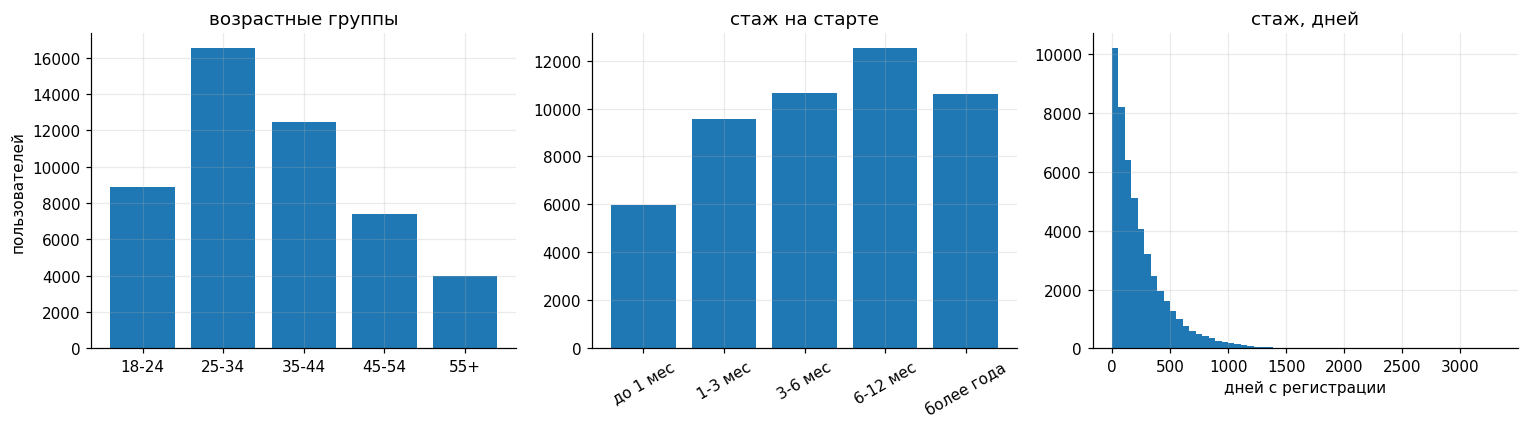

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

age = user_mart.age_group.value_counts().sort_index()
axes[0].bar(age.index, age.values)
axes[0].set_title('возрастные группы')
axes[0].set_ylabel('пользователей')

ten = user_mart.tenure_bucket.value_counts().sort_index()
axes[1].bar(ten.index.astype(str), ten.values)
axes[1].set_title('стаж на старте')
axes[1].tick_params(axis='x', rotation=30)

axes[2].hist(user_mart.tenure_days, bins=60)
axes[2].set_title('стаж, дней')
axes[2].set_xlabel('дней с регистрации')

plt.tight_layout()
plt.show()

Ядро аудитории составляют пользователи 25-44 лет, это почти 59%. Молодёжь 18-24 даёт 18%,
старшая группа 55+ всего 8%. Для маркетплейса профиль обычный.

По стажу аудитория распределена на удивление ровно: в каждой из пяти когорт от 12%
до 25%, резкого перекоса в сторону новичков или ветеранов нет. Медианный стаж 165 дней.
Правый хвост длинный, есть аккаунты с 2017 года, максимум 3 331 день.

Премиум-подписка на старте была у 16.5%. Это заметная доля, и в разделе 5 премиум
станет одним из ключевых сегментов.

## 2.2 Устройства, источники трафика и регионы

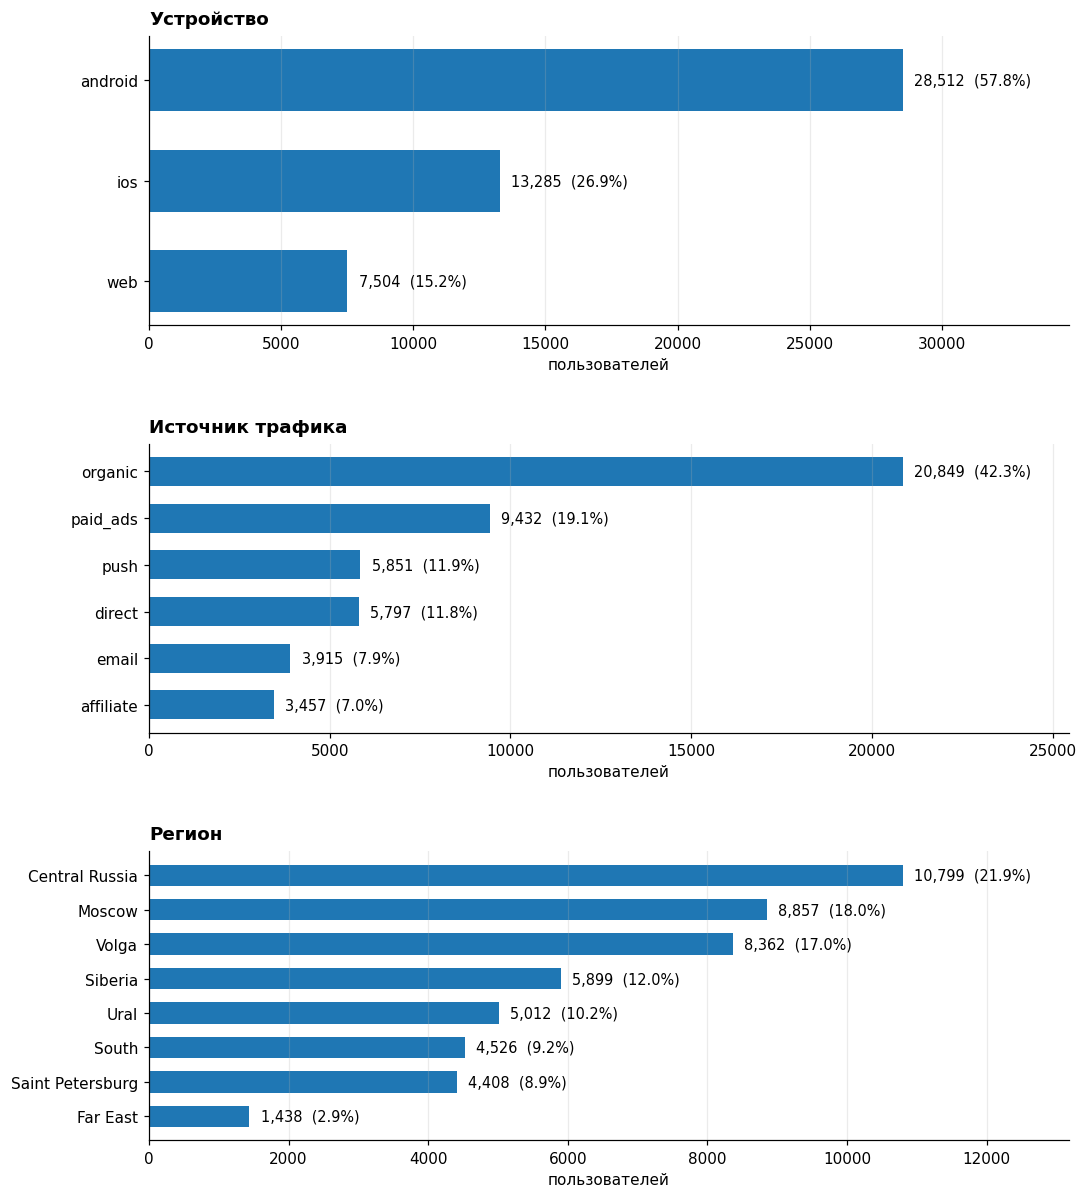

,признак,значение,пользователей,%
0,device,android,28512,57.8300
1,device,ios,13285,26.9500
2,device,web,7504,15.2200
3,traffic_source,organic,20849,42.2900
4,traffic_source,paid_ads,9432,19.1300
5,traffic_source,push,5851,11.8700
6,traffic_source,direct,5797,11.7600
7,traffic_source,email,3915,7.9400
8,traffic_source,affiliate,3457,7.0100
9,region,Central Russia,10799,21.9000


In [42]:
fig, axes = plt.subplots(3, 1, figsize=(10, 11))

for ax, col, title in zip(axes, ['device', 'traffic_source', 'region'],
                          ['Устройство', 'Источник трафика', 'Регион']):
    vc = user_mart[col].value_counts().sort_values()
    bars = ax.barh(vc.index, vc.values, height=0.62)
    ax.set_title(title, loc='left', fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('пользователей')
    ax.grid(axis='y', alpha=0)
    ax.set_xlim(0, vc.max() * 1.22)
    for b, v in zip(bars, vc.values):
        ax.text(v + vc.max() * 0.015, b.get_y() + b.get_height() / 2,
                f'{v:,}  ({v / len(user_mart) * 100:.1f}%)',
                va='center', fontsize=9.5)

plt.tight_layout(h_pad=3)
plt.show()

struct = pd.concat([
    pd.DataFrame({'признак': c,
                  'значение': user_mart[c].value_counts().index,
                  'пользователей': user_mart[c].value_counts().values,
                  '%': (user_mart[c].value_counts(normalize=True) * 100).round(2).values})
    for c in ['device', 'traffic_source', 'region']
], ignore_index=True)
display(struct)

Аудитория преимущественно мобильная: Android 57.8%, iOS 26.9%, веб только 15.2%.
Это важно помнить, эксперимент проводился на главной странице **мобильного приложения**,
то есть веб-пользователи в нём участвуют условно, и в разделе 5 стоит проверить,
не отличается ли для них эффект.

По трафику доминирует organic с 42.3%, платная реклама даёт 19.1%, остальное
распределено между push, direct, email и affiliate примерно поровну.

География ожидаемая для российского маркетплейса: Центральная Россия 21.9%,
Москва 18.0%, Поволжье 17.0%, дальше по убыванию до Дальнего Востока с 2.9%.
Москва и Питер вместе дают 26.9%, почти четверть аудитории в двух столицах.

## 2.3 Активность пользователей

In [43]:
display(pd.DataFrame({
    'сессий на пользователя':  user_mart.sessions.describe(),
    'показов на пользователя': user_mart.impressions.describe(),
    'кликов на пользователя':  user_mart.clicks.describe(),
}).round(2))

print('Длительность сессии, сек:')
print(sessions_c.session_duration_sec.describe()[['mean', '50%', '75%', 'max']].round(0).to_string())
print('\nПросмотров страниц за сессию:')
print(sessions_c.page_views.describe()[['mean', '50%', '75%', 'max']].round(1).to_string())
print(f'\nПоказов на сессию: {len(impr_c) / len(sessions_c):.2f}')
print('\nТочка входа в сессию, %:')
print((sessions_c.entry_point.value_counts(normalize=True) * 100).round(2).to_string())

,сессий на пользователя,показов на пользователя,кликов на пользователя
count,"49,301.0000","49,301.0000","49,301.0000"
mean,3.1900,20.5900,1.6800
std,1.8100,12.3900,1.5900
min,1.0000,0.0000,0.0000
25%,2.0000,11.0000,0.0000
50%,3.0000,19.0000,1.0000
75%,4.0000,28.0000,2.0000
max,16.0000,100.0000,12.0000


Длительность сессии, сек:
mean     273.0000
50%      222.0000
75%      343.0000
max    4,721.0000

Просмотров страниц за сессию:
mean    7.0000
50%     7.0000
75%     9.0000
max    21.0000

Показов на сессию: 6.45

Точка входа в сессию, %:
entry_point
homepage       34.0500
search         25.0200
category       18.0400
product_page   14.0100
push            8.8900


In [44]:
dow_raw    = sessions_c.groupby(sessions_c.session_date.dt.dayofweek).size()
days_count = pd.Series(pd.date_range(EXP_START, EXP_END).dayofweek).value_counts().sort_index()

dow = pd.DataFrame({'сессий всего': dow_raw,
                    'календарных дней в окне': days_count,
                    'сессий на один день': (dow_raw / days_count).round(0)})
dow.index = ['пн', 'вт', 'ср', 'чт', 'пт', 'сб', 'вс']
display(dow)

print(f'разброс по сырым счётчикам   : {dow["сессий всего"].max() / dow["сессий всего"].min():.3f}×')
print(f'разброс после нормировки     : {dow["сессий на один день"].max() / dow["сессий на один день"].min():.3f}×')

,сессий всего,календарных дней в окне,сессий на один день
пн,20815,4,"5,204.0000"
вт,21043,4,"5,261.0000"
ср,26350,5,"5,270.0000"
чт,26115,5,"5,223.0000"
пт,20901,4,"5,225.0000"
сб,20867,4,"5,217.0000"
вс,21211,4,"5,303.0000"


разброс по сырым счётчикам   : 1.266×
разброс после нормировки     : 1.019×


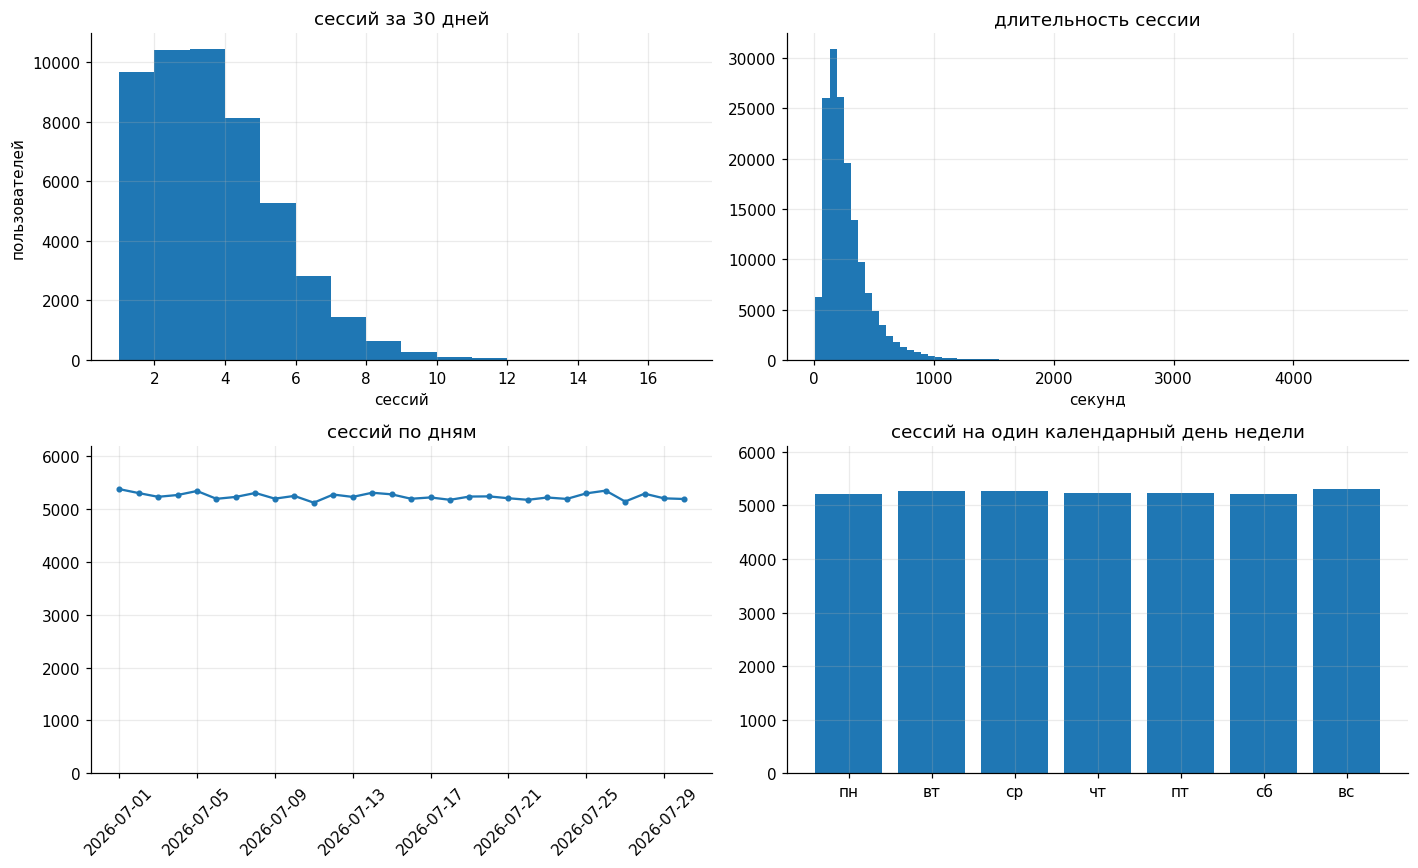

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].hist(user_mart.sessions, bins=range(1, int(user_mart.sessions.max()) + 2))
axes[0, 0].set_title('сессий за 30 дней')
axes[0, 0].set_xlabel('сессий')
axes[0, 0].set_ylabel('пользователей')

axes[0, 1].hist(sessions_c.session_duration_sec, bins=80)
axes[0, 1].set_title('длительность сессии')
axes[0, 1].set_xlabel('секунд')

daily = sessions_c.groupby(sessions_c.session_date.dt.date).size()
axes[1, 0].plot(list(daily.index), daily.values, marker='o', markersize=3)
axes[1, 0].set_title('сессий по дням')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].set_ylim(0, daily.max() * 1.15)

axes[1, 1].bar(dow.index, dow['сессий на один день'])
axes[1, 1].set_title('сессий на один календарный день недели')
axes[1, 1].set_ylim(0, dow['сессий на один день'].max() * 1.15)

plt.tight_layout()
plt.show()

Типичный пользователь заходит 3 раза за месяц, проводит в сессии около 3.7 минуты
(медиана; среднее выше, 4.6 минуты из-за правого хвоста) и смотрит 7 страниц.
За сессию ему показывают в среднем 6.45 рекомендаций.
Распределение сессий скошено вправо, но после удаления ботов хвост стал разумным,
максимум 16 сессий вместо прежних 32.

**Недельного цикла в данных нет, хотя на первый взгляд кажется, что есть.** Сырые
счётчики по дням недели дают среду и четверг примерно на 26% выше остальных дней,
и это легко принять за поведенческий паттерн. На самом деле причина календарная:
окно 1-30 июля 2026 начинается в среду и заканчивается в четверг, поэтому среда
и четверг попадают в него **по 5 раз, а остальные дни по 4**. Отношение 5/4 = 1.25
почти целиком объясняет наблюдаемый разрыв.

После нормировки на число календарных дней разброс падает с 1.27× до **1.02×**,
то есть посещаемость по дням недели практически одинаковая. Это согласуется
с дневной динамикой: от 5 123 до 5 380 сессий в день, размах всего 5%.

Вывод для раздела 4: **сезонность внутри окна отсутствует**, дневные колебания
списывать не на что, и любые различия в динамике между группами можно
интерпретировать напрямую. Логирование при этом не прерывалось и никакие внешние
события (распродажи, сбои) в окно не попали.

Точка входа: главная страница 34%, поиск 25%, категории 18%. То есть примерно треть
сессий начинается именно там, где стоит тестируемая модель.

## 2.4 Структура заказов

In [46]:
print(f'Заказов: {len(orders_c):,}')
print(f'Уникальных покупателей: {orders_c.user_id.nunique():,}')
print(f'Конверсия аудитории в покупку: {orders_c.user_id.nunique() / len(user_mart) * 100:.2f}%')
print(f'\nAOV (средний чек): {orders_c.gmv_rub.mean():,.0f} руб')
print(f'Медианный чек:     {orders_c.gmv_rub.median():,.0f} руб')
print(f'Общий GMV:         {orders_c.gmv_rub.sum():,.0f} руб')
print('\nЗаказов на покупателя:')
print(orders_c.groupby('user_id').size().value_counts().sort_index().rename('покупателей').to_string())
print(f'\nДоля заказов со скидкой: {(orders_c.discount_rub > 0).mean() * 100:.1f}%')
print(f'Средняя скидка, когда она есть: {orders_c.loc[orders_c.discount_rub > 0, "discount_rub"].mean():.0f} руб')

Заказов: 7,302
Уникальных покупателей: 6,640
Конверсия аудитории в покупку: 13.47%

AOV (средний чек): 1,674 руб
Медианный чек:     1,165 руб
Общий GMV:         12,224,862 руб

Заказов на покупателя:
1    6033
2     556
3      47
4       4

Доля заказов со скидкой: 62.8%
Средняя скидка, когда она есть: 107 руб


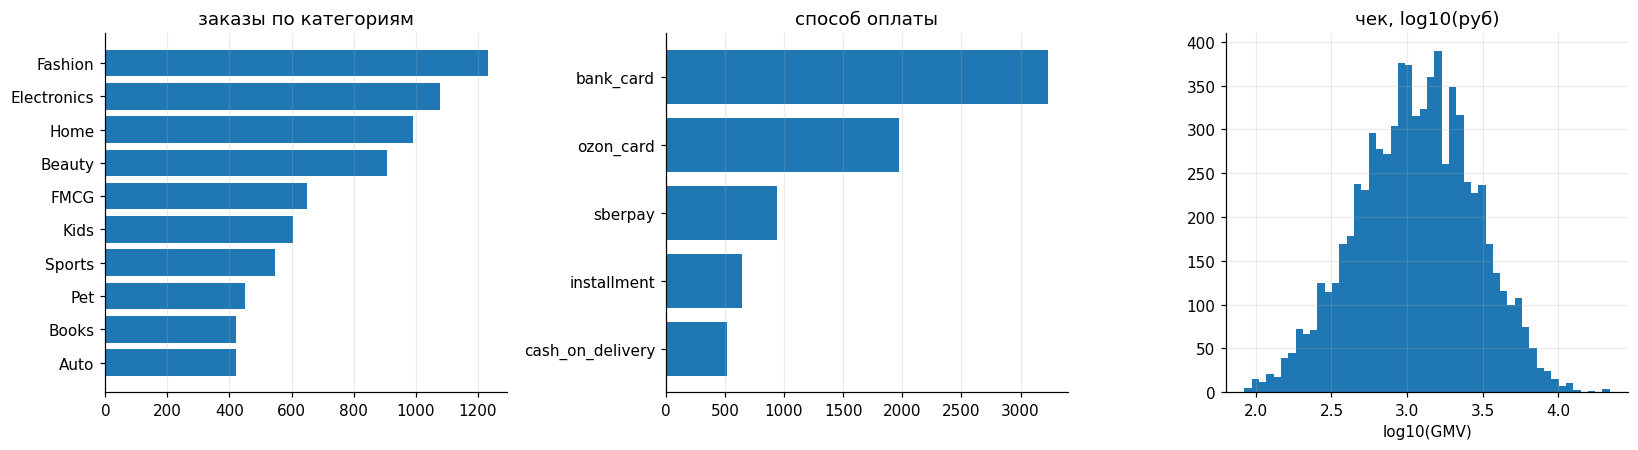

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

cat_cnt = orders_c.category.value_counts()
axes[0].barh(cat_cnt.index[::-1], cat_cnt.values[::-1])
axes[0].set_title('заказы по категориям')
axes[0].grid(axis='y', alpha=0)

pay = orders_c.payment_type.value_counts()
axes[1].barh(pay.index[::-1], pay.values[::-1])
axes[1].set_title('способ оплаты')
axes[1].grid(axis='y', alpha=0)

axes[2].hist(np.log10(orders_c.gmv_rub), bins=50)
axes[2].set_title('чек, log10(руб)')
axes[2].set_xlabel('log10(GMV)')

plt.tight_layout()
plt.show()

Покупает только 13.5% аудитории, 6 640 человек из 49 301. Это нормально для
маркетплейса за месяц, но означает, что все метрики, связанные с деньгами,
опираются на узкую подвыборку, и мощность по ним будет заметно ниже, чем по CTR.

Средний чек 1 674 рубля при медиане 1 165, распределение скошено, что мы уже
видели в разделе 1.8. Повторных покупателей мало: 6 033 человека купили один раз
и только 607 сделали два и более заказа.

По категориям лидирует Fashion (16.9% заказов), затем Electronics и Home.
Оплата: банковская карта 44.3%, карта маркетплейса 27.0%, остальное приходится
на SberPay, рассрочку и наличные при получении.

---

## 2.5 Дополнительный анализ

Формальные требования пункта 2 закрыты выше. Дальше идёт то, что задание прямо не просит,
но что понадобится в следующих разделах. Каждый блок здесь отвечает на конкретный
вопрос, который иначе всплывёт при интерпретации A/B-результатов.

### 2.5.1 Концентрация GMV и денежные метрики на пользователя

**Зачем:** понять, насколько GMV зависит от небольшой группы людей. Если выручка
сильно сконцентрирована, среднее становится неустойчивым и сравнение групп по GMV
потребует бутстрапа, а не t-теста.

,топ_%_покупателей,человек,доля_GMV_%
0,1,66,6.1000
1,5,332,20.2000
2,10,664,32.6000
3,20,1328,50.3000
4,50,3320,81.2000


ARPU  (выручка на всю аудиторию): 248.0 руб
ARPPU (выручка на покупателя)   : 1,841.1 руб
AOV   (выручка на заказ)        : 1,674.2 руб
Маржа на пользователя           : 40.6 руб


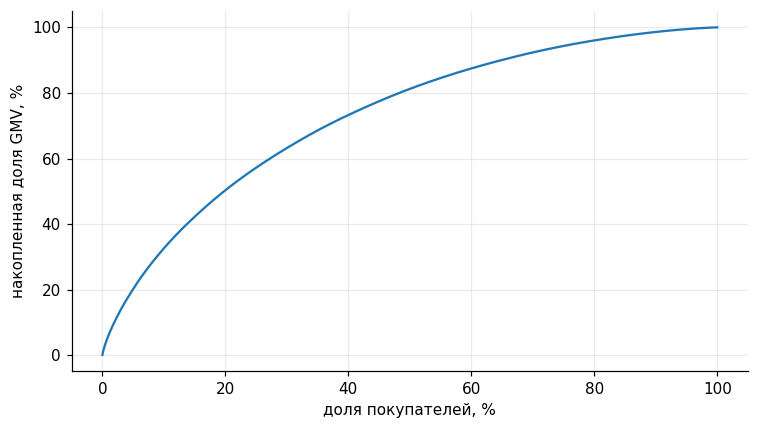

In [48]:
gmv_by_user = user_mart.loc[user_mart.gmv > 0, 'gmv'].sort_values(ascending=False)
total_gmv = gmv_by_user.sum()

conc = []
for p in [0.01, 0.05, 0.10, 0.20, 0.50]:
    k = max(1, int(len(gmv_by_user) * p))
    conc.append({'топ_%_покупателей': int(p * 100), 'человек': k,
                 'доля_GMV_%': round(gmv_by_user.head(k).sum() / total_gmv * 100, 1)})
display(pd.DataFrame(conc))

print(f'ARPU  (выручка на всю аудиторию): {total_gmv / len(user_mart):,.1f} руб')
print(f'ARPPU (выручка на покупателя)   : {total_gmv / len(gmv_by_user):,.1f} руб')
print(f'AOV   (выручка на заказ)        : {orders_c.gmv_rub.mean():,.1f} руб')
print(f'Маржа на пользователя           : {user_mart.margin.sum() / len(user_mart):,.1f} руб')

fig, ax = plt.subplots(figsize=(7, 4))
cum = gmv_by_user.cumsum() / total_gmv * 100
ax.plot(np.arange(1, len(cum) + 1) / len(cum) * 100, cum.values)
ax.set_xlabel('доля покупателей, %')
ax.set_ylabel('накопленная доля GMV, %')
plt.tight_layout()
plt.show()

Концентрация умеренная: топ-20% покупателей дают половину GMV, топ-10% треть.
До классического Парето 80/20 не дотягивает, что скорее хорошо, выручка не висит
на десятке китов. Но самый крупный заказ в 21 926 рублей при медиане 1 165 всё равно
означает тяжёлый хвост, поэтому в разделе 4 средний чек будем сравнивать бутстрапом.

Ключевые денежные ориентиры: ARPU 248 рублей на пользователя, ARPPU 1 841 на покупателя,
маржа всего **40.6 рубля** на пользователя. Последняя цифра важна: маржинальность тонкая,
и рост возвратов способен съесть прирост GMV целиком. Это станет центральным сюжетом
раздела 6.

### 2.5.2 Позиционное смещение в ленте рекомендаций

**Зачем:** CTR зависит не только от качества рекомендации, но и от места в ленте.
Если новая модель просто показывает больше карточек или меняет их порядок,
часть прироста CTR будет механической. Нужно знать масштаб эффекта позиции.

,показов,кликов,CTR_%
position,,,
1,156803,20636,13.1600
2,156124,17065,10.9300
3,152699,14056,9.2100
4,142766,11074,7.7600
5,124912,7777,6.2300
6,100513,5477,5.4500
7,73763,3340,4.5300
8,49028,1868,3.8100
9,29792,913,3.0600


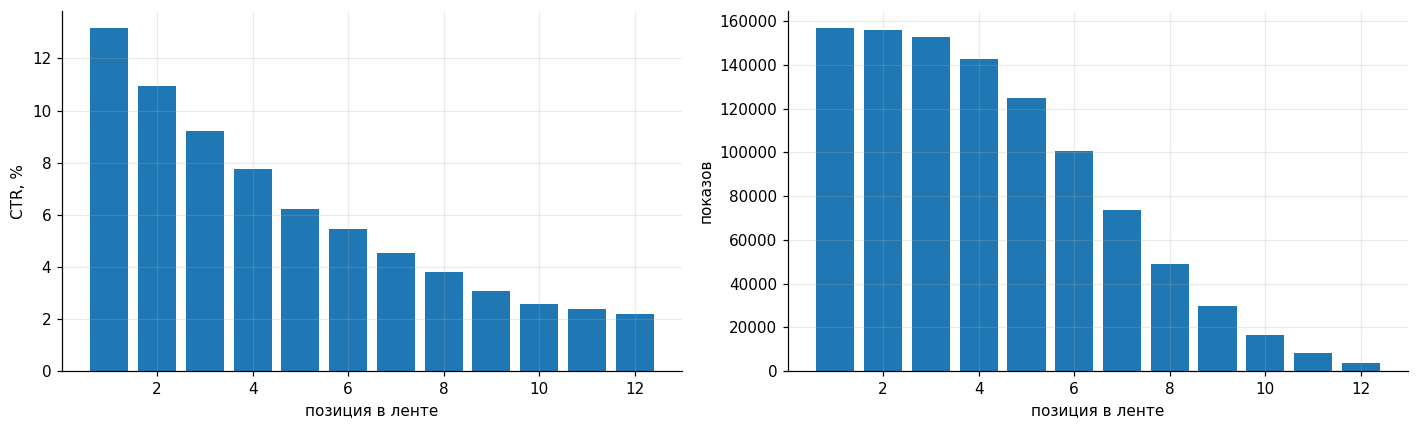

In [49]:
pos = impr_c.groupby('position').is_clicked.agg(показов='size', кликов='sum')
pos['CTR_%'] = (pos.кликов / pos.показов * 100).round(2)
display(pos)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(pos.index, pos['CTR_%'])
axes[0].set_xlabel('позиция в ленте')
axes[0].set_ylabel('CTR, %')
axes[1].bar(pos.index, pos.показов)
axes[1].set_xlabel('позиция в ленте')
axes[1].set_ylabel('показов')
plt.tight_layout()
plt.show()

Эффект позиции огромный: первая карточка собирает CTR 13.2%, двенадцатая 2.2%,
разница в шесть раз. Падение монотонное и плавное.

Отсюда прямое следствие для раздела 4: сравнивая CTR между группами, нужно проверить,
одинаково ли распределены показы по позициям. Если новая модель отдаёт больше показов
на верхние позиции, часть прироста CTR объясняется не качеством рекомендаций, а
перераспределением внимания. Обязательно посчитаем CTR отдельно по каждой позиции,
это разделит два эффекта.

### 2.5.3 Категории: где показы, где деньги, где возвраты

**Зачем:** доля в показах и доля в выручке представляют собой разные вещи. Если модель
сместит показы в сторону категорий с высокой кликабельностью, но низким чеком, CTR вырастет,
а GMV нет. Плюс категории сильно различаются по возвратам, а рост возвратов относится
к известным побочным эффектам этого эксперимента.

,показы_%,CTR_%,заказы_%,GMV_%,маржа_%,AOV,возвраты_%
category,,,,,,,
Electronics,13.8500,8.3600,14.7800,35.5800,23.9600,"4,030.8100",5.8400
Fashion,16.1000,8.3800,16.8900,15.7200,19.2400,"1,558.6700",14.2700
Home,13.7700,8.0400,13.5600,15.1800,16.8200,"1,874.1000",6.5700
Auto,5.9000,7.9900,5.7500,8.2900,8.2600,"2,414.0700",4.7600
Sports,7.8500,8.0600,7.5000,6.1500,7.6000,"1,372.9000",7.3000
Kids,8.8700,7.9800,8.3000,6.0700,7.1200,"1,224.8300",7.1000
Beauty,12.1000,8.4600,12.4100,5.9500,9.9400,802.7200,2.2100
Pet,5.9000,8.1000,6.1500,3.4300,3.8000,935.2200,3.3400
FMCG,9.8000,7.9500,8.8900,2.4400,2.0100,458.9400,1.3900


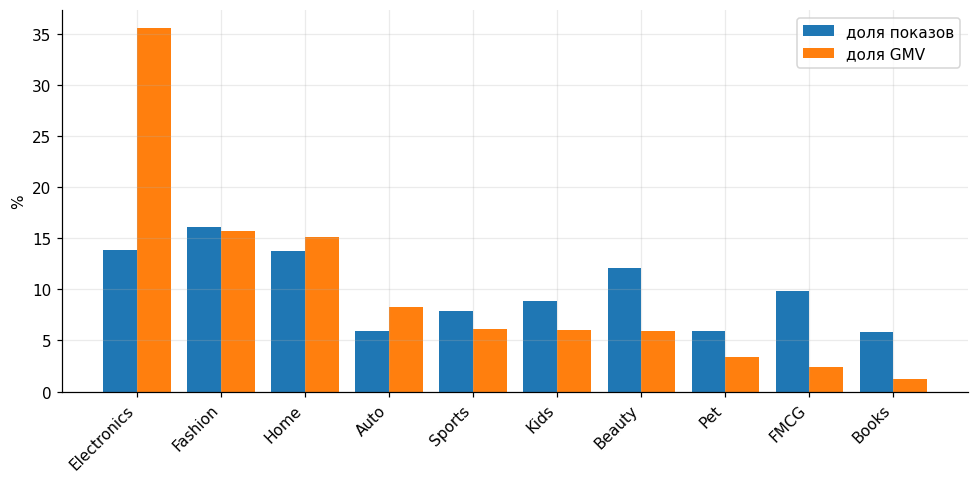

In [50]:
impr_cat  = impr_c.merge(products[['product_id', 'category']], on='product_id')
click_cat = clicks_c.merge(products[['product_id', 'category']], on='product_id')

cat = pd.DataFrame({
    'показы_%':   impr_cat.category.value_counts(normalize=True) * 100,
    'CTR_%':      click_cat.category.value_counts() / impr_cat.category.value_counts() * 100,
    'заказы_%':   orders_c.category.value_counts(normalize=True) * 100,
    'GMV_%':      orders_c.groupby('category').gmv_rub.sum() / orders_c.gmv_rub.sum() * 100,
    'маржа_%':    orders_c.groupby('category').gross_margin_rub.sum() / orders_c.gross_margin_rub.sum() * 100,
    'AOV':        orders_c.groupby('category').gmv_rub.mean(),
    'возвраты_%': orders_c.groupby('category').is_returned.mean() * 100,
}).round(2).sort_values('GMV_%', ascending=False)
display(cat)

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(cat))
ax.bar(x - 0.2, cat['показы_%'], width=0.4, label='доля показов')
ax.bar(x + 0.2, cat['GMV_%'], width=0.4, label='доля GMV')
ax.set_xticks(x)
ax.set_xticklabels(cat.index, rotation=45, ha='right')
ax.set_ylabel('%')
ax.legend()
plt.tight_layout()
plt.show()

Здесь самая содержательная находка раздела. Electronics занимает 13.9% показов,
но приносит 35.6% всей выручки, средний чек 4 031 рубль против 343 у книг.
Обратная картина у Beauty и FMCG: показов много, денег мало.

При этом CTR по категориям почти не различается, от 7.9% до 8.5%. То есть
кликабельность плохо предсказывает ценность категории, и оптимизация под клики
не тождественна оптимизации под выручку.

Возвраты различаются драматически: Fashion возвращают в 14.3% случаев, FMCG в 1.4%.
Разница в десять раз. Если новая модель сдвинет показы в сторону Fashion, возвраты
вырастут просто из-за смены товарного микса, а не из-за качества рекомендаций.
В разделе 4 это нужно будет проверить напрямую.

### 2.5.4 Активность и конверсия: связь с числом сессий

**Зачем:** если эксперимент влияет на частоту возвращения в приложение, это отдельный
канал воздействия на выручку помимо CTR. Полезно заранее понимать, насколько сильно
активность связана с деньгами.

,пользователей,ARPU,конверсия_%
sessions,,,
1,9664,70.7000,4.2500
2,10422,155.8000,8.8900
3,10458,231.6000,12.6700
4,8115,305.0000,16.8100
5,5271,367.5000,20.4100
6,2833,463.5000,24.8500
7,1436,621.8000,31.0600
8,646,748.4000,33.2800
9,273,782.1000,33.7000


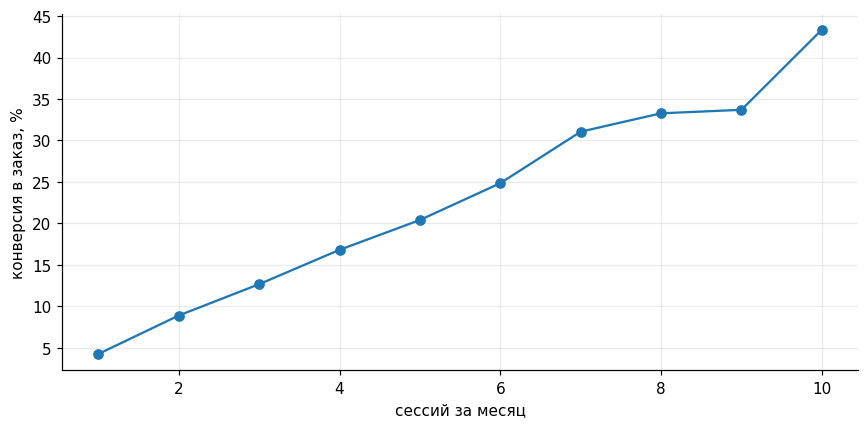

In [51]:
by_sessions = (user_mart.groupby('sessions')
               .agg(пользователей=('user_id', 'size'),
                    конверсия=('converted', 'mean'),
                    ARPU=('gmv', 'mean'))
               .head(10))
by_sessions['конверсия_%'] = (by_sessions.конверсия * 100).round(2)
by_sessions = by_sessions.drop(columns='конверсия')
by_sessions['ARPU'] = by_sessions.ARPU.round(1)
display(by_sessions)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(by_sessions.index, by_sessions['конверсия_%'], marker='o')
ax.set_xlabel('сессий за месяц')
ax.set_ylabel('конверсия в заказ, %')
plt.tight_layout()
plt.show()

Связь очень сильная и почти линейная: у пользователя с одной сессией конверсия 4.2%,
с пятью 20.4%, с десятью 43.4%. ARPU растёт в том же темпе, от 71 до 991 рубля.

Причинность тут двусторонняя, активные покупают чаще, но и намерение купить
приводит человека в приложение. Тем не менее для раздела 4 это означает, что число
сессий на пользователя надо мерить как самостоятельную метрику: если новая модель
увеличит частоту визитов, эффект на выручку будет больше, чем даёт один только CTR.

### 2.5.5 Профиль сегментов: кто приносит деньги

**Зачем:** это прямая заготовка под раздел 5. Прежде чем искать, где эффект модели
сильнее, надо знать базовые различия сегментов, иначе разницу в эффекте легко
спутать с разницей в исходном уровне.

In [52]:
def segment_profile(col):
    g = (user_mart.groupby(col, observed=True)
         .agg(пользователей=('user_id', 'size'),
              сессий=('sessions', 'mean'),
              конверсия=('converted', 'mean'),
              ARPU=('gmv', 'mean')))
    g['конверсия_%'] = (g.конверсия * 100).round(2)
    g['сессий'] = g.сессий.round(2)
    g['ARPU'] = g.ARPU.round(1)
    return g.drop(columns='конверсия')

for col in ['is_premium', 'device', 'traffic_source', 'tenure_bucket']:
    print(f'- {col} -')
    display(segment_profile(col))

- is_premium -


,пользователей,сессий,ARPU,конверсия_%
is_premium,,,,
0,41151,2.9500,217.3000,12.0600
1,8150,4.4100,402.6000,20.5900


- device -


,пользователей,сессий,ARPU,конверсия_%
device,,,,
android,28512,3.1900,254.5000,13.8300
ios,13285,3.1800,244.0000,12.9500
web,7504,3.2200,230.4000,13.0200


- traffic_source -


,пользователей,сессий,ARPU,конверсия_%
traffic_source,,,,
affiliate,3457,3.0000,227.8000,12.5300
direct,5797,3.7600,301.3000,15.9200
email,3915,2.9900,230.6000,12.3100
organic,20849,3.0100,231.4000,12.6000
paid_ads,9432,3.0200,234.0000,12.8400
push,5851,3.8000,300.2000,16.4600


- tenure_bucket -


,пользователей,сессий,ARPU,конверсия_%
tenure_bucket,,,,
до 1 мес,5974,3.1700,264.0000,14.5600
1-3 мес,9559,3.2100,275.0000,14.2900
3-6 мес,10666,3.1900,227.0000,12.9000
6-12 мес,12516,3.2000,244.4000,13.0900
более года,10586,3.1800,239.7000,13.1300


Премиум-статус расслаивает аудиторию сильнее всего: подписчики заходят в полтора раза
чаще (4.4 сессии против 3.0), конвертируются вдвое лучше (20.6% против 12.1%) и дают
почти вдвое больший ARPU (403 против 217 рублей). Это самый очевидный кандидат
на отдельный сегмент в разделе 5.

Устройства почти не различаются по поведению, Android чуть впереди по ARPU, но разрыв
в пределах 10%. А вот источник трафика расслаивает заметно: direct и push дают ARPU
около 300 рублей, тогда как organic, email и affiliate примерно 230. Логично:
человек, пришедший напрямую или по push, уже знаком с сервисом.

Стаж, что интересно, почти не влияет, конверсия колеблется в узком коридоре без
внятного тренда. То есть новички покупают не хуже старожилов, и когортный разрез
по стажу вряд ли даст сильный сигнал в разделе 5.

### 2.5.6 Обращения в поддержку

**Зачем:** Customer Support Rate входит в метрики задания, а рост нагрузки на поддержку
назван вероятным побочным эффектом. Полезно понять структуру обращений заранее.

In [53]:
tick_c = tickets[tickets.user_id.isin(set(user_mart.user_id))]
print(f'Обращений: {len(tick_c)} от {tick_c.user_id.nunique()} пользователей')
print(f'Доля заказов, породивших обращение: {tick_c.order_id.nunique() / len(orders_c) * 100:.2f}%')
print(f'Решено в течение 24 часов: {tick_c.resolved_within_24h.mean() * 100:.1f}%')
print('\nПричины обращений, %:')
print((tick_c.reason.value_counts(normalize=True) * 100).round(2).to_string())
print('\nТональность (sentiment_score):')
print(tick_c.sentiment_score.describe()[['mean', '50%', 'min', 'max']].round(3).to_string())

Обращений: 335 от 334 пользователей
Доля заказов, породивших обращение: 4.59%
Решено в течение 24 часов: 71.6%

Причины обращений, %:
reason
product_quality          34.3300
delivery_delay           22.6900
return_request           14.9300
wrong_item               11.3400
payment_issue             9.8500
recommendation_quality    6.8700

Тональность (sentiment_score):
mean    0.0750
50%     0.0800
min    -1.0000
max     1.0000


Обращений всего 335, и это главное ограничение: выборка настолько мала, что уловить
статистически значимое различие между группами почти нереально. Заранее фиксируем,
что по этой метрике мы сможем говорить только о направлении, но не о значимости.

К малому объёму добавляется усечение данных, разобранное в разделе 1.7: тикеты
обрываются 3 августа, тогда как больше половины возвратов происходит позже.
Значит наблюдаемая нагрузка на поддержку представляет собой заниженную оценку,
причём заниженную сильнее в той группе, где больше возвратов.

Структура причин осмысленная: качество товара 34.3%, задержка доставки 22.7%,
запрос возврата 14.9%. Отдельно интересна причина `recommendation_quality`, 6.9%
обращений, то есть 23 штуки. Это единственная категория, напрямую связанная
с тестируемой моделью, и в разделе 4 стоит посмотреть на неё отдельно, пусть
и с оговоркой про размер выборки.

### 2.5.7 Что мы принципиально не можем измерить

**Зачем:** заказы в датасете привязаны к конкретным кликам, а клики к показам.
Это даёт редкую возможность проверить напрямую, покупает ли пользователь именно то,
что ему порекомендовали, или уходит искать другое. Прямая мера полезности модели,
а не косвенный признак вроде CTR.

In [54]:
print(f'заказов в исходных данных : {len(orders):,}')
print(f'из них с непустым click_id: {orders.click_id.notna().sum():,} '
      f'({orders.click_id.notna().mean() * 100:.2f}%)')

chain = orders_c.merge(clicks_c[['click_id', 'product_id', 'impression_id']],
                       on='click_id', suffixes=('', '_clk'))
chain['product_id_imp'] = chain.impression_id.map(
    impr_c.set_index('impression_id').product_id)
prod_cat = products.set_index('product_id').category

checks_chain = {
    'товар заказа = товар клика':      (chain.product_id == chain.product_id_clk),
    'товар клика = товар показа':      (chain.product_id_clk == chain.product_id_imp),
    'категория заказа = категория показа':
        (chain.product_id.map(prod_cat) == chain.product_id_imp.map(prod_cat)),
}
display(pd.DataFrame({
    'совпало':      {k: int(v.sum()) for k, v in checks_chain.items()},
    'всего':        {k: len(v) for k, v in checks_chain.items()},
    'доля_%':       {k: round(v.mean() * 100, 2) for k, v in checks_chain.items()},
}))

ep = pd.DataFrame({
    'все сессии, %':          sessions_c.entry_point.value_counts(normalize=True) * 100,
    'сессии с заказом, %':    orders_c.session_id.map(
                                  sessions_c.set_index('session_id').entry_point
                              ).value_counts(normalize=True) * 100,
}).round(1)
display(ep)

заказов в исходных данных : 7,407
из них с непустым click_id: 7,407 (100.00%)


,совпало,всего,доля_%
товар заказа = товар клика,7302,7302,100.0000
товар клика = товар показа,7302,7302,100.0000
категория заказа = категория показа,7302,7302,100.0000


,"все сессии, %","сессии с заказом, %"
homepage,34.0000,36.6000
search,25.0000,23.1000
category,18.0000,17.9000
product_page,14.0000,13.4000
push,8.9000,9.0000


Совпадение **стопроцентное по всей цепочке**: товар заказа равен товару клика, товар клика
равен товару показа, категория сохраняется. Ни один пользователь не «ушёл искать другое».

Как измерение полезности модели это бесполезно, метрика вырождена в константу 100%
и одинакова в обеих группах. Но сама её вырожденность и есть находка.

**Вывод первый, технический.** Цепочка показ → клик → заказ внутренне непротиворечива
не только по пользователю и сессии (это проверено в 1.4), но и по товару. Значит любые
разрезы заказов по категориям, позициям и товарам корректны, атрибуция однозначна.

**Вывод второй, и он ограничивает всю работу.** Все 7 407 заказов имеют непустой
`click_id`, то есть **в датасете нет ни одной покупки помимо рекомендательной ленты**.
Ни через поиск, ни через прямой заход в категорию, ни из карточки товара.

При этом сессии с покупками начинаются откуда угодно: 36.6% с главной, 23.1% с поиска,
17.9% с категории. То есть путь пользователя разнообразен, а вот покупка почему-то
всегда проходит через клик по рекомендации. В реальном маркетплейсе так не бывает.

Отсюда прямое следствие для рекомендации руководству:

> **Каннибализацию измерить невозможно.** Мы не можем отличить покупки, которые
> модель *создала*, от покупок, которые она *перехватила* у поиска и прямых заходов.

Если часть прироста представляет собой перехват, то реальная прибавка к выручке меньше
наблюдаемых +35%, а рост возвратов и нагрузки на поддержку при этом настоящий. Экономика
решения меняется качественно. Поэтому **все оценки прироста GMV в разделах 4 и 6 следует
читать как верхнюю границу эффекта**, а не как точечную оценку.

Ограничение внесено в список раздела 1.13, а соответствующий запрос данных
в раздел 8.

## 2.6 Что EDA даёт следующим разделам

Собираю выводы, которые дальше будут работать как рабочие гипотезы.

**Про воронку (раздел 3).** Покупает 13.5% аудитории, повторно только 9.1%
покупателей. Основные потери, судя по всему, между показом и кликом: из 1.02 млн
показов кликов всего 83 тысячи. Узкое место надо будет измерить точно.

**Про A/B-анализ (раздел 4).** Четыре вещи. Позиция в ленте меняет CTR в шесть раз,
поэтому прирост CTR обязательно разложить по позициям. Категории различаются
по возвратам в десять раз, поэтому рост возвратов надо проверять на смену
товарного микса. Распределение GMV скошено, поэтому средний чек сравнивать бутстрапом.
И сезонности внутри окна нет, дневные различия между группами можно читать напрямую.

**Про сегментацию (раздел 5).** Премиум это самый расслаивающий признак, разница
по ARPU почти двукратная. Веб-пользователей 15%, и они в мобильном эксперименте
участвуют условно. Стаж, наоборот, слабый разделитель.

**Про бизнес-интерпретацию (раздел 6).** Маржа на пользователя всего 40.6 рубля
при ARPU 248. Запас прочности тонкий, и рост возвратов может обнулить прирост выручки.
Это будет главный вопрос при выработке рекомендации.

---

# 3. Анализ пользовательской воронки

Строим сквозной путь пользователя и смотрим, что с ним делает новая модель.
Воронку считаем в двух проекциях, потому что они отвечают на разные вопросы:

- **на уровне пользователей**, сколько *людей* доходит до каждого этапа. Это ответ
  на вопрос «кого модель затрагивает»;
- **на уровне событий**, сколько *показов, кликов и заказов* происходит. Это ответ
  на вопрос «какой объём она создаёт».

Дальше идут поиск узких мест и разложение эффекта по этапам: нужно понять, за счёт
какого именно шага растут заказы, а не просто зафиксировать, что они выросли.

Всё считается на очищенных данных (`user_mart`, `impr_c`, `clicks_c`, `orders_c`).

## 3.1 Воронка на уровне пользователей

In [55]:
STAGES = [
    ('Назначен в эксперимент',   lambda d: pd.Series(True, index=d.index)),
    ('Была хотя бы 1 сессия',    lambda d: d.sessions > 0),
    ('Получил хотя бы 1 показ',  lambda d: d.impressions > 0),
    ('Кликнул хотя бы раз',      lambda d: d.clicks > 0),
    ('Сделал заказ',             lambda d: d.orders > 0),
    ('Сделал 2+ заказа',         lambda d: d.orders >= 2),
]

rows = []
for name, f in STAGES:
    r = {'этап': name}
    for g, sub in user_mart.groupby('experiment_group'):
        r[g] = int(f(sub).sum())
    rows.append(r)

fun = pd.DataFrame(rows).set_index('этап')
for g in ['control', 'test']:
    fun[f'{g}, % от базы'] = (fun[g] / fun[g].iloc[0] * 100).round(2)
    fun[f'{g}, % от пред.'] = (fun[g] / fun[g].shift(1) * 100).round(2)
fun['Δ шага, п.п.'] = (fun['test, % от пред.'] - fun['control, % от пред.']).round(2)
display(fun[['control', 'test', 'control, % от базы', 'test, % от базы',
             'control, % от пред.', 'test, % от пред.', 'Δ шага, п.п.']])

,control,test,"control, % от базы","test, % от базы","control, % от пред.","test, % от пред.","Δ шага, п.п."
этап,,,,,,,
Назначен в эксперимент,24473,24828,100.0000,100.0000,NaN,NaN,NaN
Была хотя бы 1 сессия,24473,24828,100.0000,100.0000,100.0000,100.0000,0.0000
Получил хотя бы 1 показ,24472,24828,100.0000,100.0000,100.0000,100.0000,0.0000
Кликнул хотя бы раз,17488,19238,71.4600,77.4900,71.4600,77.4900,6.0300
Сделал заказ,2881,3759,11.7700,15.1400,16.4700,19.5400,3.0700
Сделал 2+ заказа,203,404,0.8300,1.6300,7.0500,10.7500,3.7000


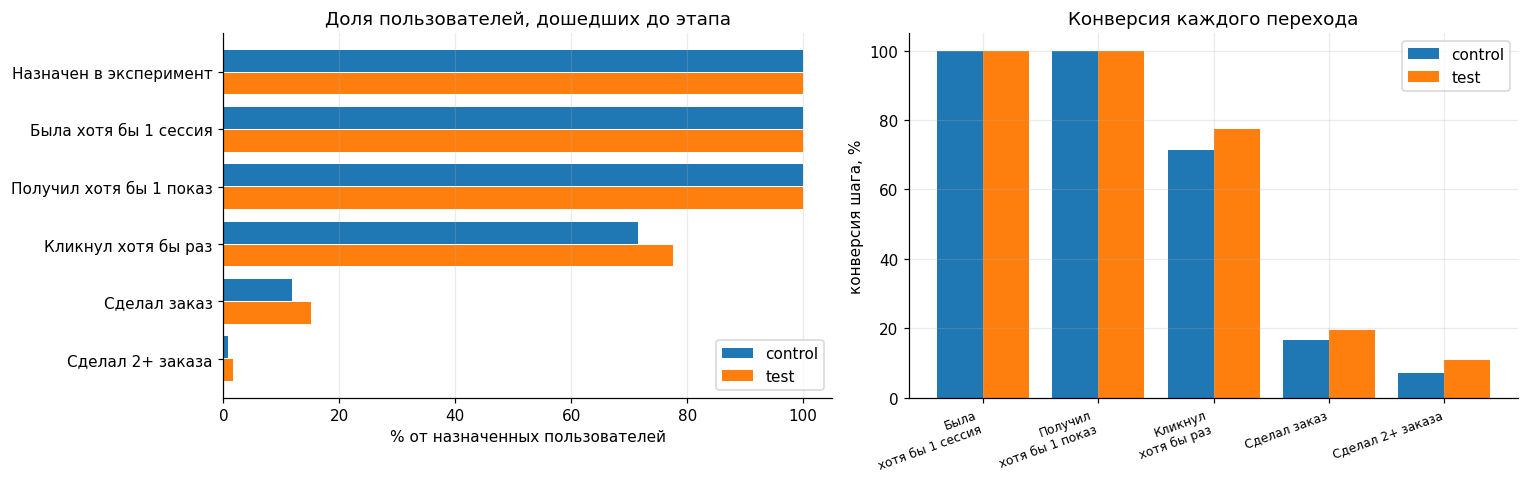

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

y = np.arange(len(fun))[::-1]
axes[0].barh(y + 0.2, fun['control, % от базы'], height=0.38, label='control')
axes[0].barh(y - 0.2, fun['test, % от базы'],    height=0.38, label='test')
axes[0].set_yticks(y)
axes[0].set_yticklabels(fun.index)
axes[0].set_xlabel('% от назначенных пользователей')
axes[0].set_title('Доля пользователей, дошедших до этапа')
axes[0].legend()
axes[0].grid(axis='y', alpha=0)

step = fun[['control, % от пред.', 'test, % от пред.']].dropna()
x = np.arange(len(step))
axes[1].bar(x - 0.2, step['control, % от пред.'], width=0.4, label='control')
axes[1].bar(x + 0.2, step['test, % от пред.'],    width=0.4, label='test')
axes[1].set_xticks(x)
axes[1].set_xticklabels([s.replace(' хотя бы', '\nхотя бы') for s in step.index],
                        rotation=20, ha='right', fontsize=8)
axes[1].set_ylabel('конверсия шага, %')
axes[1].set_title('Конверсия каждого перехода')
axes[1].legend()

plt.tight_layout()
plt.show()

Первые три этапа вырождены: **все 49 301 пользователь имели сессию и получили показы**
(ровно один человек в control не получил ни одного показа). Спящей аудитории в датасете
нет, поэтому содержательная воронка начинается с клика, это отмечено ещё в разделе 1.4.1
как особенность синтетических данных.

Дальше расхождение групп нарастает на каждом шаге:

| Переход | control | test | разница |
|---|---|---|---|
| показ → клик (охват) | 71.46% | 77.49% | **+6.03 п.п.** |
| кликнувшие → покупатели | 16.47% | 19.54% | **+3.07 п.п.** |
| покупатели → повторные | 7.05% | 10.75% | **+3.70 п.п.** |

Накопленный эффект: доля покупателей выросла с 11.77% до 15.14% аудитории, а доля
повторных покупателей почти вдвое, с 0.83% до 1.63%.

Важно, что растёт **охват**, а не только интенсивность: модель не просто заставляет
активных кликать чаще, она втягивает в клики тех, кто раньше не кликал вовсе.
Разложим это отдельно в 3.5.

## 3.2 Воронка на уровне событий

In [57]:
ev = []
for g in ['control', 'test']:
    uids = set(assign_c.loc[assign_c.experiment_group == g, 'user_id'])
    o_g  = orders_c[orders_c.user_id.isin(uids)]
    ev.append({
        'группа': g,
        'показы':   int(impr_c.user_id.isin(uids).sum()),
        'клики':    int(clicks_c.user_id.isin(uids).sum()),
        'заказы':   len(o_g),
        'возвраты': int(o_g.is_returned.sum()),
        'тикеты':   int(tickets.user_id.isin(uids).sum()),
    })
evt = pd.DataFrame(ev).set_index('группа')

evt['CTR, %']            = (evt.клики    / evt.показы * 100).round(3)
evt['клик→заказ, %']     = (evt.заказы   / evt.клики  * 100).round(3)
evt['заказ→возврат, %']  = (evt.возвраты / evt.заказы * 100).round(3)
evt['показ→заказ, %']    = (evt.заказы   / evt.показы * 100).round(4)
display(evt)

print('Относительная разница test / control, %:')
print(((evt.loc['test'] / evt.loc['control'] - 1) * 100).round(2).to_string())

,показы,клики,заказы,возвраты,тикеты,"CTR, %","клик→заказ, %","заказ→возврат, %","показ→заказ, %"
группа,,,,,,,,,
control,504604,36851,3098,172,133,7.3030,8.4070,5.5520,0.6139
test,510556,46065,4204,288,202,9.0230,9.1260,6.8510,0.8234


Относительная разница test / control, %:
показы              1.1800
клики              25.0000
заказы             35.7000
возвраты           67.4400
тикеты             51.8800
CTR, %             23.5500
клик→заказ, %       8.5500
заказ→возврат, %   23.4000
показ→заказ, %     34.1300


Событийная картина подтверждает пользовательскую и добавляет масштаб.
Показов в группах поровну (+1.2%, ровно разница в размере групп), а всё, что дальше,
растёт: кликов +25.0%, заказов +35.7%.

Сквозная конверсия «показ → заказ» поднимается с **0.614% до 0.823%**, то есть на 34.1%.
Это самая компактная сводка эффекта модели.

Но в той же таблице видна и цена: возвраты выросли на **67.4%**, обращения в поддержку
на **51.9%**, быстрее, чем заказы. Причём часть этого роста механическая (больше заказов,
больше возвратов), поэтому смотреть надо на нормированную строку: доля возвратов
**на заказ** выросла с 5.55% до 6.85%, то есть на 23.4%. Это уже не механика,
а ухудшение качества самих заказов.

## 3.3 Где узкое место

Классическая ошибка при чтении воронки состоит в том, чтобы назвать узким местом тот шаг,
где теряется больше всего людей в абсолюте. В мультипликативной воронке это неверно: самый
широкий шаг теряет больше просто потому, что через него проходит больше.

In [58]:
i0, c0, o0 = len(impr_c), len(clicks_c), len(orders_c)
loss = pd.DataFrame([
    {'переход': 'показ → клик', 'вход': i0, 'выход': c0, 'конверсия_%': round(c0 / i0 * 100, 2),
     'потеряно': i0 - c0, 'доля потерь от входа_%': round((1 - c0 / i0) * 100, 2)},
    {'переход': 'клик → заказ', 'вход': c0, 'выход': o0, 'конверсия_%': round(o0 / c0 * 100, 2),
     'потеряно': c0 - o0, 'доля потерь от входа_%': round((1 - o0 / c0) * 100, 2)},
])
display(loss)
print(f'Сквозная конверсия показ → заказ: {o0 / i0 * 100:.3f}%')

,переход,вход,выход,конверсия_%,потеряно,доля потерь от входа_%
0,показ → клик,1015160,82916,8.1700,932244,91.8300
1,клик → заказ,82916,7302,8.8100,75614,91.1900


Сквозная конверсия показ → заказ: 0.719%


Оба перехода пропускают дальше примерно одинаковую долю: **8.17%** на шаге показ → клик
и **8.81%** на шаге клик → заказ. В абсолюте на первом шаге теряется 932 244 события,
на втором 75 614, но это лишь следствие того, что воронка сверху в двенадцать раз шире.

Отсюда практический вывод: **выделенного узкого места в этой воронке нет**. Оба шага
одинаково «дырявые», и относительное улучшение любого из них на 10% даёт одинаковый
прирост заказов, потому что итог есть произведение конверсий. Приоритет нужно выбирать
не по величине потерь, а по тому, где у нас есть рычаг.

Тестируемая модель влияет ровно на первый шаг, на то, что показано в ленте. Насколько
через него удалось потянуть весь остальной путь, показывает следующий блок.

## 3.4 Декомпозиция: за счёт какого этапа растут заказы

Число заказов на пользователя раскладывается в произведение трёх множителей:

$$\frac{\text{заказы}}{\text{юзер}} = \frac{\text{показы}}{\text{юзер}} \times \frac{\text{клики}}{\text{показ}} \times \frac{\text{заказы}}{\text{клик}}$$

Сравнив каждый множитель между группами, увидим, какой этап на самом деле создаёт эффект.

In [59]:
dec = []
for g, sub in user_mart.groupby('experiment_group'):
    n = len(sub)
    dec.append({'группа': g,
                'показов на юзера': sub.impressions.sum() / n,
                'CTR':              sub.clicks.sum() / sub.impressions.sum(),
                'клик→заказ':       sub.orders.sum() / sub.clicks.sum(),
                'заказов на юзера': sub.orders.sum() / n})
dd = pd.DataFrame(dec).set_index('группа')
display(dd.round(5))

ratio = dd.loc['test'] / dd.loc['control']
check  = ratio['показов на юзера'] * ratio['CTR'] * ratio['клик→заказ']

contrib = pd.DataFrame({
    'test / control':      ratio.round(5),
    'прирост, %':          ((ratio - 1) * 100).round(2),
})
contrib['вклад в общий прирост, %'] = [
    round(np.log(ratio[k]) / np.log(ratio['заказов на юзера']) * 100, 1)
    if k != 'заказов на юзера' else np.nan
    for k in ratio.index]
display(contrib)

print(f'произведение трёх множителей : {check:.5f}')
print(f'фактический рост заказов/юзер: {ratio["заказов на юзера"]:.5f}')

,показов на юзера,CTR,клик→заказ,заказов на юзера
группа,,,,
control,20.6188,0.0730,0.0841,0.1266
test,20.5637,0.0902,0.0913,0.1693


,test / control,"прирост, %","вклад в общий прирост, %"
показов на юзера,0.9973,-0.2700,-0.9000
CTR,1.2355,23.5500,72.7000
клик→заказ,1.0856,8.5600,28.2000
заказов на юзера,1.3376,33.7600,NaN


произведение трёх множителей : 1.33760
фактический рост заказов/юзер: 1.33760


Тождество выполняется точно: 0.99733 × 1.23546 × 1.08557 = **1.33760**, что в точности
равно фактическому росту заказов на пользователя.

Расшифровка по этапам:

- **показов на пользователя: −0.3%.** Объём выдачи не изменился. Это важная проверка,
  прирост не куплен тем, что тесту просто показали больше карточек;
- **CTR: +23.5%**, вклад в общий прирост **72.7%**. Основной двигатель;
- **клик→заказ: +8.6%**, вклад **28.2%**. Меньший, но самостоятельный эффект.

Второй пункт содержательнее, чем кажется. Модель влияет напрямую только на то, *что*
показано, то есть на CTR. Рост конверсии из клика в заказ означает, что **кликнутые
товары стали лучше подходить пользователю**: человек не просто чаще нажимает, он чаще
доводит дело до покупки. Это признак реального улучшения релевантности, а не «кликбейта»
в ленте.

Проверим, не является ли этот рост композиционным артефактом: в тесте люди кликают чаще,
а активные кликеры могут конвертироваться лучше сами по себе.

In [60]:
cl = user_mart[user_mart.clicks > 0].copy()
cl['кликов'] = pd.cut(cl.clicks, [0, 1, 2, 3, 5, 100], labels=['1', '2', '3', '4-5', '6+'])

strat = (cl.groupby(['кликов', 'experiment_group'], observed=True)
           .agg(юзеров=('user_id', 'size'), заказов=('orders', 'sum'), кликов_всего=('clicks', 'sum')))
strat['заказ на клик, %'] = (strat.заказов / strat.кликов_всего * 100).round(2)
display(strat.unstack('experiment_group'))

юзеров        заказов            кликов_всего             заказ на клик, %       
experiment_group control  test  control       test      control        test          control   test
кликов                                                                                             
1                   7343  6828 601.0000   594.0000   7,343.0000  6,828.0000           8.1800 8.7000
2                   5010  5283 863.0000   935.0000  10,020.0000 10,566.0000           8.6100 8.8500
3                   2759  3348 715.0000   907.0000   8,277.0000 10,044.0000           8.6400 9.0300
4-5                 1954  2870 670.0000 1,172.0000   8,426.0000 12,482.0000           7.9500 9.3900
6+                   422   909 249.0000   596.0000   2,785.0000  6,145.0000           8.9400 9.7000

Композицией это не объясняется: конверсия клика в заказ выше в тесте **внутри каждой
страты по числу кликов**, 8.70% против 8.18% у однокликовых, 9.39% против 7.95%
у делающих 4-5 кликов, 9.70% против 8.94% у самых активных. Эффект устойчив
к контролю на активность, значит он настоящий.

## 3.5 Охват против интенсивности

Прирост кликов на пользователя можно разложить ещё раз: за счёт того, что кликать стало
**больше людей**, или того, что каждый кликает **чаще**. Для продукта это разные истории.

In [61]:
ri = []
for g, s in user_mart.groupby('experiment_group'):
    n, ck = len(s), int((s.clicks > 0).sum())
    ri.append({'группа': g, 'пользователей': n, 'кликнувших': ck,
               'охват (доля кликнувших)': ck / n,
               'кликов на кликнувшего':   s.clicks.sum() / ck,
               'кликов на пользователя':  s.clicks.sum() / n})
ri = pd.DataFrame(ri).set_index('группа')
display(ri.round(4))

rr = ri.loc['test'] / ri.loc['control']
split = pd.DataFrame({
    'test / control': rr[['охват (доля кликнувших)', 'кликов на кликнувшего', 'кликов на пользователя']].round(5),
    'прирост, %':     ((rr[['охват (доля кликнувших)', 'кликов на кликнувшего', 'кликов на пользователя']] - 1) * 100).round(2),
})
split['вклад, %'] = [round(np.log(rr[k]) / np.log(rr['кликов на пользователя']) * 100, 1)
                     for k in ['охват (доля кликнувших)', 'кликов на кликнувшего', 'кликов на пользователя']]
split.loc['кликов на пользователя', 'вклад, %'] = np.nan
display(split)

,пользователей,кликнувших,охват (доля кликнувших),кликов на кликнувшего,кликов на пользователя
группа,,,,,
control,24473,17488,0.7146,2.1072,1.5058
test,24828,19238,0.7749,2.3945,1.8554


,test / control,"прирост, %","вклад, %"
охват (доля кликнувших),1.0843,8.4300,38.8000
кликов на кликнувшего,1.1363,13.6300,61.2000
кликов на пользователя,1.2322,23.2200,NaN


Прирост кликов на пользователя (+23.2%) делится так: **38.8% даёт расширение охвата**
(кликает 77.5% вместо 71.5%) и **61.2% рост интенсивности** (2.39 клика на кликнувшего
вместо 2.11).

То есть эффект двойной. Модель одновременно вовлекает новую аудиторию и углубляет
взаимодействие с уже вовлечённой. Для раскатки это скорее хорошая новость: рост
не держится на узкой активной прослойке, а размазан по базе, а значит, вероятность,
что эффект «схлопнется» при переносе на всех, ниже.

## 3.6 Негативная ветка: возврат, поддержка, повторная покупка

Воронка не заканчивается заказом. Дальше идут этапы, которые определяют, была ли покупка
удачной для пользователя и прибыльной для компании.

In [62]:
neg = []
for g, sub in user_mart.groupby('experiment_group'):
    buyers = int((sub.orders > 0).sum())
    neg.append({
        'группа': g,
        'покупателей': buyers,
        'заказов на покупателя':        round(sub.orders.sum() / buyers, 4),
        'вернувших хотя бы раз, %':     round((sub.returns_all > 0).sum() / buyers * 100, 2),
        'обращавшихся в поддержку, %':  round((sub.tickets > 0).sum() / buyers * 100, 2),
        'повторных покупателей, %':     round((sub.orders >= 2).sum() / buyers * 100, 2),
    })
display(pd.DataFrame(neg).set_index('группа'))

,покупателей,заказов на покупателя,"вернувших хотя бы раз, %","обращавшихся в поддержку, %","повторных покупателей, %"
группа,,,,,
control,2881,1.0753,5.9400,4.5800,7.0500
test,3759,1.1184,7.6100,5.3700,10.7500


In [63]:
first_order = (orders_c.sort_values('order_date').drop_duplicates('user_id')
               [['user_id', 'is_returned']].rename(columns={'is_returned': 'первый заказ вернули'}))
fo = first_order.merge(user_mart[['user_id', 'orders', 'experiment_group']], on='user_id')
fo['повторил'] = (fo.orders >= 2).astype(int)

display(fo.groupby('первый заказ вернули')
          .agg(покупателей=('user_id', 'size'), доля_повторивших=('повторил', 'mean'))
          .assign(доля_повторивших_=lambda d: (d.доля_повторивших * 100).round(2))
          .drop(columns='доля_повторивших')
          .rename(columns={'доля_повторивших_': 'повторили, %'}))

,покупателей,"повторили, %"
первый заказ вернули,,
0,6224,9.0500
1,416,10.5800


Среди покупателей доля вернувших выросла с **5.94% до 7.61%**, доля обращавшихся
в поддержку с 4.58% до 5.37%. При этом заказов на покупателя стало больше
(1.075 → 1.118), а повторных покупателей заметно больше (7.05% → 10.75%).

Получается смешанная картина: модель одновременно **углубляет отношения** с покупателем
и **чаще приводит к неудачной покупке**. Какой из эффектов перевешивает в деньгах,
разбираем в разделе 6.

**Отдельная проверка, важная для прогноза.** Обычно возврат снижает вероятность
повторной покупки, и тогда рост возвратов бил бы по будущей выручке. В этих данных
такой связи нет: среди тех, чей первый заказ вернули, повторно покупают **10.6%**,
среди остальных **9.1%**, то есть даже чуть чаще.

Скорее всего это артефакт синтетики: возвраты генерировались независимо от последующего
поведения. Поэтому **отсутствие связи здесь не является доказательством её отсутствия
в реальности**, и рассуждать о долгосрочном ущербе от возвратов по этим данным нельзя.
Фиксируем как ограничение и переносим в список вопросов к продуктовой команде (раздел 8).

## 3.7 Итог по воронке

**Что делает модель.** Эффект возникает на первом шаге и усиливается дальше по цепочке:

```
показы     +1.2%   (только за счёт размера группы, на пользователя даже −0.3%)
клики     +25.0%   основной эффект, вклад 72.7%
заказы    +35.7%   добавляется рост конверсии клика, вклад 28.2%
возвраты  +67.4%   растут быстрее заказов
тикеты    +51.9%
```

**Узкого места в классическом смысле нет.** Оба перехода воронки пропускают около 8-9%,
и относительное улучшение любого из них даёт одинаковый прирост заказов. Точка
приложения усилий выбирается не по величине потерь, а по наличию рычага, и модель
работает ровно там, где рычаг у команды есть.

**Эффект качественный, а не только количественный.** Рост конверсии из клика в заказ
на 8.6% устойчив к контролю на активность пользователя, то есть кликнутые товары
действительно стали релевантнее. Это отличает результат от простого «раскрутили ленту».

**Рост широкий, а не точечный.** 38.8% прироста кликов приходится на расширение охвата,
61.2% на интенсивность. Эффект не держится на узкой прослойке активных.

**Цена видна уже здесь.** Возвраты на заказ выросли на 23.4%. Тикетов на заказ стало
на 11.9% больше, однако формальная проверка в разделе 4 покажет, что для поддержки
данных недостаточно, чтобы отделить ухудшение качества от случайного разброса.
Оценка компромисса в деньгах приведена в разделе 6.

Для раздела 4 отсюда следуют две проверки: разложить прирост CTR по позициям в ленте
(2.5.2) и проверить, не объясняется ли рост возвратов сдвигом товарного микса
в сторону Fashion (2.5.3).

# 4. Анализ результатов A/B-теста

В предыдущем разделе мы увидели, **где** меняется воронка. Здесь формально оцениваем,
какие различия между control и test статистически подтверждаются, насколько велик эффект
и какие отрицательные последствия сопровождают рост продаж.

Анализ проводится на очищенной витрине `user_mart` из раздела 1.11. Единица
рандомизации это пользователь, поэтому и неопределённость считаем **на уровне пользователя**.
Один активный пользователь может создать много показов, кликов и заказов, но не должен
считаться множеством независимых наблюдений.

## 4.1 Дизайн статистического анализа

### Иерархия метрик

| Роль | Метрики | Зачем нужны |
|---|---|---|
| Ключевая продуктовая | CTR | Проверяет прямой эффект модели на релевантность выдачи |
| Ключевые бизнес-метрики | GMV на пользователя, маржа на пользователя | Показывают денежную ценность на всю назначенную аудиторию, включая пользователей без заказов |
| Метрики механизма | Click→Order, конверсия пользователя в заказ, заказы на пользователя, AOV | Объясняют, за счёт какого звена возникает денежный эффект |
| Дополнительная | Premium Conversion | Проверяет возможный побочный эффект на подписку |
| Guardrails (цена роста) | Return Rate, Customer Support Rate | Показывают цену роста для качества покупки и операционной нагрузки |
| Инварианты | Показы на пользователя, сессии на пользователя, показы на сессию, страницы за сессию | Не должны меняться в принципе: подтверждают, что модель поменяла содержание выдачи, а не её объём |

Главную денежную метрику считаем **на пользователя**, а не только на покупателя. Анализ
только среди покупателей нарушил бы рандомизацию: сам факт покупки уже зависит от варианта.
По этой же причине общий GMV групп напрямую не сравниваем, в test немного больше людей.

### Методы

- Для всех отношений вида `сумма числителя / сумма знаменателя` используем
  кластерную оценку дисперсии по пользователям. Это относится к CTR, Click→Order,
  AOV и Return Rate.
- 95%-е доверительные интервалы строим **бутстрапом пользователей**. При пересэмплировании
  пользователь переносится вместе со всеми своими событиями, поэтому сохраняется зависимость
  между повторными показами и заказами одного человека.
- AOV не сравниваем обычным t-тестом по заказам: распределение чека скошено, максимум
  равен 21 926 ₽, а несколько заказов одного пользователя зависимы. Точечную оценку
  и p-value даёт та же кластерная линеаризация, что и для прочих отношений, а
  доверительный интервал строится кластерным бутстрапом, устойчивым к скошенности.
- Для денежных метрик на пользователя нули сохраняются: пользователь без заказа
  представляет собой полноценную часть экспериментальной группы.
- Так как в постановке не была заранее зафиксирована одна primary metric, проверяется
  несколько гипотез. Чтобы снизить риск случайных находок, p-value корректируются
  методом Холма. Это консервативнее FDR и удобно для итогового решения.
- **Важная оговорка про направление поправки.** Холм контролирует вероятность хотя бы
  одной ложной находки и потому делает выводы строже. Для метрик успеха это правильно:
  мы не хотим объявить рост там, где его нет. Но для метрик вреда, то есть Return Rate
  и Customer Support Rate, консерватизм работает в опасную сторону, снижая шанс
  **обнаружить** ухудшение. По ним поправка приведена для полноты картины, а решение
  принимается по нескорректированному p-value и доверительному интервалу.
  В нашем случае это не меняет выводов: Return Rate остаётся значимым и после Холма
  (p 0.022 → 0.044), но зафиксировать логику важно.

Уровень значимости: `α = 0.05`. Статистическую значимость всегда читаем вместе с размером
эффекта и доверительным интервалом.

In [64]:
ab_mart = user_mart.copy()
ab_mart['support_user'] = (ab_mart.tickets > 0).astype(int)


def ratio_delta_test(df, num_col, den_col=None):
    'Разность двух ratio-of-sums с кластерной дисперсией на уровне пользователя.'
    out = {}
    for grp in ['control', 'test']:
        s = df[df.experiment_group == grp]
        x = s[num_col].to_numpy(dtype=float)
        y = np.ones(len(s)) if den_col is None else s[den_col].to_numpy(dtype=float)

        theta = x.sum() / y.sum()
        mu_y = y.mean()
        influence = x - theta * y
        se = np.sqrt(influence.var(ddof=1) / (len(s) * mu_y ** 2))
        out[grp] = {'value': theta, 'se': se, 'n': len(s)}

    diff = out['test']['value'] - out['control']['value']
    se_diff = np.sqrt(out['test']['se'] ** 2 + out['control']['se'] ** 2)
    z = diff / se_diff
    p = 2 * stats.norm.sf(abs(z))
    return out, diff, z, p


def bootstrap_ratio(df, num_col, den_col=None, n_boot=3000, seed=42, chunk=100):
    'Кластерный bootstrap: пересэмплируются пользователи целиком.'
    rng = np.random.default_rng(seed)
    arrays = {}
    for grp in ['control', 'test']:
        s = df[df.experiment_group == grp]
        x = s[num_col].to_numpy(dtype=float)
        y = np.ones(len(s)) if den_col is None else s[den_col].to_numpy(dtype=float)
        arrays[grp] = (x, y)

    samples = []
    for start in range(0, n_boot, chunk):
        b = min(chunk, n_boot - start)
        vals = {}
        for grp in ['control', 'test']:
            x, y = arrays[grp]
            idx = rng.integers(0, len(x), size=(b, len(x)))
            vals[grp] = x[idx].sum(axis=1) / y[idx].sum(axis=1)

        abs_diff = vals['test'] - vals['control']
        rel_diff = vals['test'] / vals['control'] - 1
        samples.append(np.column_stack([abs_diff, rel_diff]))

    samples = np.vstack(samples)
    return {
        'abs_low': np.quantile(samples[:, 0], 0.025),
        'abs_high': np.quantile(samples[:, 0], 0.975),
        'rel_low': np.quantile(samples[:, 1], 0.025),
        'rel_high': np.quantile(samples[:, 1], 0.975),
    }


def holm_adjust(p_values):
    'Поправка Холма без дополнительной зависимости от statsmodels.'
    p = np.asarray(p_values, dtype=float)
    order = np.argsort(p)
    adjusted = np.empty(len(p))
    running_max = 0.0
    m = len(p)
    for rank, idx in enumerate(order):
        candidate = (m - rank) * p[idx]
        running_max = max(running_max, candidate)
        adjusted[idx] = min(running_max, 1.0)
    return adjusted

## 4.2 Инварианты экспозиции: модель поменяла содержание, а не объём

Прежде чем читать таблицу эффектов, нужно закрыть альтернативное объяснение. Рост заказов
на пользователя мог бы возникнуть не от качества рекомендаций, а просто оттого, что новая
модель стала показывать больше карточек или чаще приводить людей в приложение.

Проверяем четыре величины, которые эксперимент менять не должен: сколько показов получает
пользователь, сколько раз он заходит, насколько плотная лента в сессии и как глубоко
он смотрит. Если хотя бы одна сдвинулась, условия показа в группах различались, и
поведенческие метрики сравнивать уже некорректно.

Формально это тот же тест, что и для остальных метрик, но читается он наоборот:
здесь мы **надеемся не найти** различий.

In [65]:
INVARIANTS = [
    ('Показов на пользователя', 'impressions', None),
    ('Сессий на пользователя',  'sessions',    None),
    ('Показов на сессию',       'impressions', 'sessions'),
    ('Страниц за сессию',       'page_views',  'sessions'),
]

inv_rows = []
for name, num, den in INVARIANTS:
    out, diff, z, p = ratio_delta_test(ab_mart, num, den)
    c, t = out['control']['value'], out['test']['value']
    ci = bootstrap_ratio(ab_mart, num, den, n_boot=3000, seed=101)
    inv_rows.append({
        'инвариант': name,
        'control': round(c, 4),
        'test': round(t, 4),
        'Δ %': round((t / c - 1) * 100, 2),
        '95% CI uplift': f'[{ci["rel_low"] * 100:+.2f}%; {ci["rel_high"] * 100:+.2f}%]',
        'p-value': round(p, 3),
        'вывод': 'без изменений' if p >= 0.05 else 'ВНИМАНИЕ: сдвиг',
    })

invariants = pd.DataFrame(inv_rows)
display(invariants)

print('Размеры групп после очистки:')
print(ab_mart.groupby('experiment_group').size().rename('пользователей').to_string())

,инвариант,control,test,Δ %,95% CI uplift,p-value,вывод
0,Показов на пользователя,20.6188,20.5637,-0.2700,[-1.32%; +0.78%],0.6220,без изменений
1,Сессий на пользователя,3.1894,3.1919,0.0800,[-0.92%; +1.07%],0.8790,без изменений
2,Показов на сессию,6.4648,6.4425,-0.3400,[-0.71%; +0.00%],0.0530,без изменений
3,Страниц за сессию,7.0011,6.9888,-0.1700,[-0.54%; +0.17%],0.3250,без изменений


Размеры групп после очистки:
experiment_group
control    24473
test       24828


Все четыре инварианта на месте, ни один не сдвинулся.

Показов на пользователя 20.62 против 20.56, разница −0.27% при p = 0.62. Сессий
на пользователя 3.189 против 3.192, +0.08%, p = 0.88. Страниц за сессию −0.17%, p = 0.33.

Отдельного комментария требует плотность ленты: показов на сессию 6.465 против 6.443,
то есть −0.34% при p = 0.053. Значение пограничное, но смотреть надо на размер, а не
на порог: сдвиг составляет три десятых процента и направлен **против** теста, в тестовой
группе показов чуть меньше. Если бы этот мизерный дефицит на что-то влиял, он занижал бы
эффект, а не создавал его. Как объяснение прироста заказов на 33.8% он не годится.

Вывод для всего раздела: новая модель изменила **содержание** выдачи при неизменном объёме.
Значит различия в поведении можно относить на счёт качества рекомендаций, а не условий показа.

## 4.3 Сводная таблица эффектов

Ниже одна таблица для всех основных метрик. Для Premium Conversion знаменателем
служат только пользователи, у которых Premium отсутствовал на старте. В остальных
пользовательских метриках знаменатель это вся соответствующая экспериментальная группа.

In [66]:
metric_specs = [
    {'metric': 'CTR',                'num': 'clicks',            'den': 'impressions', 'kind': 'pct',   'subset': 'all'},
    {'metric': 'Click→Order',        'num': 'orders',            'den': 'clicks',      'kind': 'pct',   'subset': 'all'},
    {'metric': 'Order conversion',   'num': 'converted',         'den': None,          'kind': 'pct',   'subset': 'all'},
    {'metric': 'Orders per user',    'num': 'orders',            'den': None,          'kind': 'count', 'subset': 'all'},
    {'metric': 'AOV',                'num': 'gmv',               'den': 'orders',      'kind': 'money', 'subset': 'all'},
    {'metric': 'GMV per user',       'num': 'gmv',               'den': None,          'kind': 'money', 'subset': 'all'},
    {'metric': 'Margin per user',    'num': 'margin',            'den': None,          'kind': 'money', 'subset': 'all'},
    {'metric': 'Return Rate',        'num': 'returns_all',       'den': 'orders',      'kind': 'pct',   'subset': 'all'},
    {'metric': 'Premium Conversion', 'num': 'premium_converted', 'den': None,          'kind': 'pct',   'subset': 'non_premium'},
    {'metric': 'Support user rate',  'num': 'support_user',      'den': None,          'kind': 'pct',   'subset': 'all'},
]

result_rows = []
for i, spec in enumerate(metric_specs):
    d = ab_mart if spec['subset'] == 'all' else ab_mart[ab_mart.is_premium == 0]
    test, diff, z, p = ratio_delta_test(d, spec['num'], spec['den'])
    ci = bootstrap_ratio(d, spec['num'], spec['den'], n_boot=3000, seed=2026 + i)

    c = test['control']['value']
    t = test['test']['value']
    result_rows.append({
        'metric': spec['metric'],
        'kind': spec['kind'],
        'control': c,
        'test': t,
        'abs_diff': diff,
        'rel_uplift': t / c - 1,
        'abs_ci_low': ci['abs_low'],
        'abs_ci_high': ci['abs_high'],
        'rel_ci_low': ci['rel_low'],
        'rel_ci_high': ci['rel_high'],
        'p_value': p,
    })

ab_results = pd.DataFrame(result_rows)
ab_results['p_holm'] = holm_adjust(ab_results.p_value)
ab_results['significant_holm'] = ab_results.p_holm < 0.05


def fmt_value(v, kind):
    if kind == 'pct':
        return f'{v * 100:.2f}%'
    if kind == 'money':
        return f'{v:,.2f} ₽'
    return f'{v:.4f}'


def fmt_p(v):
    return '<0.001' if v < 0.001 else f'{v:.3f}'

shown = []
for _, r in ab_results.iterrows():
    shown.append({
        'метрика': r.metric,
        'control': fmt_value(r.control, r.kind),
        'test': fmt_value(r.test, r.kind),
        'Δ': fmt_value(r.abs_diff, r.kind),
        'uplift': f'{r.rel_uplift * 100:+.1f}%',
        '95% CI uplift': f'[{r.rel_ci_low * 100:+.1f}%; {r.rel_ci_high * 100:+.1f}%]',
        'p-value': fmt_p(r.p_value),
        'p Холма': fmt_p(r.p_holm),
        'значимо после Холма': 'да' if r.significant_holm else 'нет',
    })

pd.DataFrame(shown)

,метрика,control,test,Δ,uplift,95% CI uplift,p-value,p Холма,значимо после Холма
0,CTR,7.30%,9.02%,1.72%,+23.5%,[+22.0%; +25.1%],<0.001,<0.001,да
1,Click→Order,8.41%,9.13%,0.72%,+8.6%,[+3.8%; +13.3%],<0.001,<0.001,да
2,Order conversion,11.77%,15.14%,3.37%,+28.6%,[+23.2%; +34.9%],<0.001,<0.001,да
3,Orders per user,0.1266,0.1693,0.0427,+33.8%,[+27.5%; +40.4%],<0.001,<0.001,да
4,AOV,"1,657.37 ₽","1,686.57 ₽",29.21 ₽,+1.8%,[-2.7%; +6.5%],0.451,0.451,нет
5,GMV per user,209.80 ₽,285.58 ₽,75.78 ₽,+36.1%,[+27.7%; +45.6%],<0.001,<0.001,да
6,Margin per user,34.96 ₽,46.14 ₽,11.18 ₽,+32.0%,[+24.0%; +40.6%],<0.001,<0.001,да
7,Return Rate,5.55%,6.85%,1.30%,+23.4%,[+2.5%; +48.3%],0.022,0.044,да
8,Premium Conversion,1.81%,2.36%,0.55%,+30.1%,[+14.4%; +49.6%],<0.001,<0.001,да
9,Support user rate,0.54%,0.81%,0.27%,+50.8%,[+21.3%; +89.9%],<0.001,<0.001,да


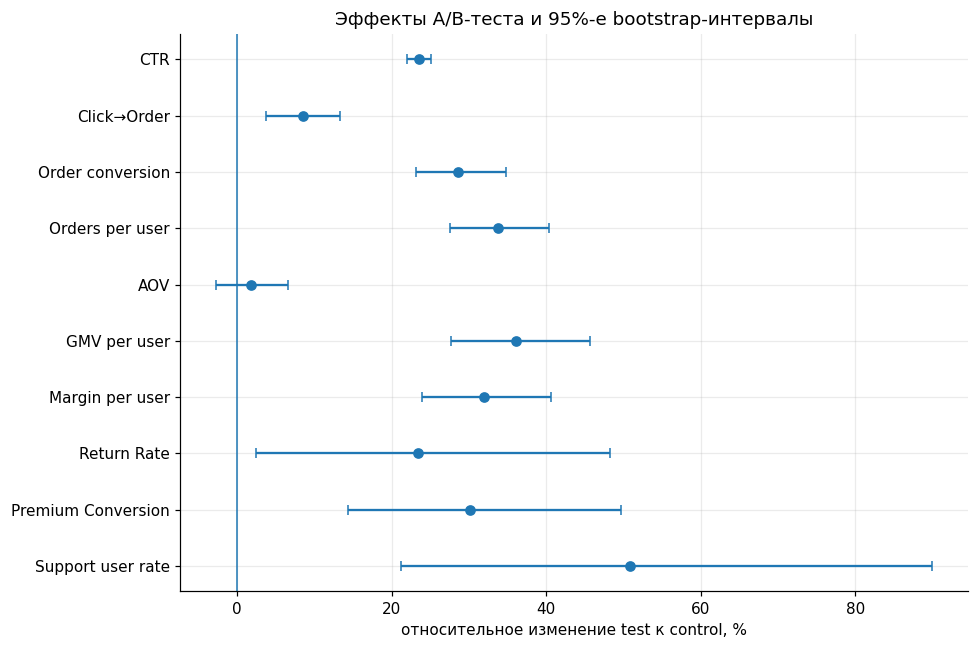

In [67]:
plot_df = ab_results.copy()
y = np.arange(len(plot_df))
x = plot_df.rel_uplift.to_numpy() * 100
xerr = np.vstack([
    (plot_df.rel_uplift - plot_df.rel_ci_low).to_numpy() * 100,
    (plot_df.rel_ci_high - plot_df.rel_uplift).to_numpy() * 100,
])

fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(x, y, xerr=xerr, fmt='o', capsize=3)
ax.axvline(0, linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(plot_df.metric)
ax.set_xlabel('относительное изменение test к control, %')
ax.set_title('Эффекты A/B-теста и 95%-е bootstrap-интервалы')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Что следует из основной таблицы

**Прямой продуктовый эффект большой и точный.** CTR вырос с **7.30% до 9.02%**:
абсолютно это +1.72 п.п., относительно **+23.5%**. Интервал узкий и полностью лежит
выше нуля. Конверсия из клика в заказ также выросла, с 8.41% до 9.13%, или на **8.6%**.
Значит новая выдача создаёт больше кликов и приводит к более качественным кликам.

**Рост доходит до пользователя и денег.** Доля пользователей с заказом выросла
с 11.77% до 15.14% (**+3.37 п.п.**), заказов на пользователя стало на 33.8% больше.
GMV на пользователя вырос на **75.78 ₽**, или на 36.1%, а маржа на пользователя
на **11.18 ₽**, или на 32.0%. Оба эффекта статистически устойчивы.

**Средний чек не изменился.** AOV вырос лишь на 29 ₽ (+1.8%), а 95%-й интервал
включает как небольшое снижение, так и рост; `p = 0.45`. Следовательно, денежный результат
создан количеством покупателей и заказов, а не более дорогими корзинами.

**Premium Conversion выросла**, но в абсолюте эффект умеренный: +0.55 п.п.
(+30.1% относительно control). Это дополнительный плюс, а не основной источник ценности.

После консервативной поправки Холма значимы все эффекты, кроме AOV. Особенно важно,
что после поправки сохраняется и рост Return Rate: это не случайная находка среди
множества проверенных метрик.

### Чувствительность: какой эффект мы вообще были способны уловить

Значимый результат отвечает на вопрос «есть ли эффект», но ничего не говорит о том,
насколько мелкий эффект мы бы заметили. Для метрик с редкими событиями это критично:
отсутствие значимости там может означать не отсутствие эффекта, а нехватку данных.

Считаю MDE, минимальный обнаружимый эффект при мощности 80% и α = 0.05. Формула
простая: `MDE = (z(0.975) + z(0.80)) × SE разности`, то есть примерно 2.80 стандартной
ошибки. Сравниваю его с фактически наблюдённым эффектом.

In [68]:
Z_SUM = stats.norm.ppf(0.975) + stats.norm.ppf(0.80)

mde_rows = []
for spec in metric_specs:
    d = ab_mart if spec['subset'] == 'all' else ab_mart[ab_mart.is_premium == 0]
    out, diff, z, p = ratio_delta_test(d, spec['num'], spec['den'])
    se_diff = np.sqrt(out['test']['se'] ** 2 + out['control']['se'] ** 2)
    base = out['control']['value']
    mde_abs = Z_SUM * se_diff
    mde_rows.append({
        'метрика': spec['metric'],
        'MDE отн., %': round(mde_abs / base * 100, 2),
        'наблюдённый эффект, %': round(diff / base * 100, 2),
        'эффект / MDE': round(abs(diff) / mde_abs, 2),
    })

mde = pd.DataFrame(mde_rows).sort_values('эффект / MDE', ascending=False)
display(mde)

,метрика,"MDE отн., %","наблюдённый эффект, %",эффект / MDE
0,CTR,2.1000,23.5500,11.2400
3,Orders per user,7.8400,33.7600,4.3100
2,Order conversion,7.3000,28.6100,3.9200
5,GMV per user,10.9300,36.1200,3.3000
6,Margin per user,10.5300,31.9600,3.0400
8,Premium Conversion,21.7600,30.0900,1.3800
9,Support user rate,38.3200,50.8400,1.3300
1,Click→Order,6.5500,8.5600,1.3100
7,Return Rate,28.5900,23.3900,0.8200
4,AOV,6.5500,1.7600,0.2700


Таблица показывает запас прочности по каждой метрике, отношение наблюдённого эффекта
к минимально обнаружимому. Значение выше единицы означает, что эксперимент был достаточно
мощным для такого эффекта; чем оно больше, тем увереннее оценка.

По CTR запас громадный, свыше одиннадцати: эффект многократно превышает порог
чувствительности в 2.1%, и здесь хватило бы гораздо меньшей выборки. Заказы на
пользователя, конверсия, ARPU и маржа держат запас от трёх до четырёх с лишним,
тоже уверенно.

**Return Rate требует отдельного разбора.** Порог чувствительности 28.6%, наблюдённый
эффект +23.4%, то есть эффект оказался значимым (p = 0.022), будучи **ниже** MDE.
Противоречия здесь нет, и объясняется это не случайностью выборки, а арифметикой двух
разных порогов:

| Величина | Формула | Значение |
|---|---|---|
| стандартная ошибка разности | SE | 10.2% |
| порог статистической значимости | 1.96 × SE | 20.0% |
| **наблюдённый эффект** | | **23.4%** |
| MDE при мощности 80% | 2.80 × SE | 28.6% |

Наблюдённый эффект попал в полосу между двумя порогами. Любой эффект внутри этой полосы
обязан одновременно быть значимым и лежать ниже MDE, это следствие того, что значимость
требует 1.96 стандартной ошибки, а восьмидесятипроцентная мощность 2.80.

Практический смысл важнее формального. Фактическая мощность для эффекта такого размера
составляет около **63%, а не 80%**: повторный эксперимент не обнаружил бы его примерно
в трети случаев. И, что существеннее для планирования, эффект, едва перешагнувший порог
значимости в недостаточно мощном тесте, с высокой вероятностью **завышен**. Значимость
получают преимущественно те выборки, где случайный шум сыграл в сторону эффекта, поэтому
центральная оценка смещена вверх (ошибка типа M).

Отсюда вывод: метрика держится всего на 460 возвратах, интервал широкий, от +2.5% до +48.3%.
Направление установлено надёжно, величина нет, а 23.4% следует считать скорее верхней
частью правдоподобного диапазона, чем его серединой. Утверждать, что возвраты выросли,
можно; планировать экономику раскатки по цифре 23.4% нельзя.

**Premium Conversion и Support rate** имеют запас 1.4 и 1.3. Формально это означает
мощность выше 80%, то есть по обеим метрикам эксперимент был достаточным, но запас
наименьший среди значимых метрик, поэтому их интервалы самые широкие
(+14.4%…+49.6% и +21.3%…+89.9%). Направление надёжно, точность оценки низкая.

**AOV** представляет собой обратный случай, запас всего 0.27. Порог чувствительности
около 6.5%, а наблюдённое изменение +1.8%. Это не доказательство отсутствия эффекта,
эксперимент попросту не смог бы различить изменение чека меньше шести с половиной процентов.
Правильная формулировка: изменение среднего чека, если оно и есть, невелико и не
является источником денежного роста.

Практический вывод для раздела 8: если понадобится точнее измерить возвраты или
редкие метрики вроде подписки и обращений в поддержку, нужен либо более длинный
период, либо эксперимент, специально спроектированный под эти метрики.

## 4.4 За счёт чего вырос GMV

Для одного пользователя выполняется разложение:

$$\frac{GMV}{user} = \frac{orders}{user} \times \frac{GMV}{order}.$$

Поэтому рост GMV на пользователя можно разделить на увеличение частоты заказов и изменение
среднего чека.

In [69]:
r = ab_results.set_index('metric')
orders_ratio = r.loc['Orders per user', 'test'] / r.loc['Orders per user', 'control']
aov_ratio = r.loc['AOV', 'test'] / r.loc['AOV', 'control']
gmv_ratio = r.loc['GMV per user', 'test'] / r.loc['GMV per user', 'control']

source = pd.DataFrame({
    'множитель test/control': [orders_ratio, aov_ratio, orders_ratio * aov_ratio],
    'изменение, %': [(orders_ratio - 1) * 100, (aov_ratio - 1) * 100,
                     (orders_ratio * aov_ratio - 1) * 100],
}, index=['Заказы на пользователя', 'AOV', 'GMV на пользователя'])

source['вклад в log-прирост GMV, %'] = [
    np.log(orders_ratio) / np.log(gmv_ratio) * 100,
    np.log(aov_ratio) / np.log(gmv_ratio) * 100,
    np.nan,
]
display(source.round(2))

margin_rate = (ab_mart.groupby('experiment_group').margin.sum() /
               ab_mart.groupby('experiment_group').gmv.sum())
print(f'Gross margin rate: control {margin_rate.control * 100:.2f}% | '
      f'test {margin_rate.test * 100:.2f}% | '
      f'Δ {(margin_rate.test - margin_rate.control) * 100:+.2f} п.п.')

,множитель test/control,"изменение, %","вклад в log-прирост GMV, %"
Заказы на пользователя,1.3400,33.7600,94.3300
AOV,1.0200,1.7600,5.6700
GMV на пользователя,1.3600,36.1200,NaN


Gross margin rate: control 16.66% | test 16.16% | Δ -0.51 п.п.


Проверка сходится с точностью до округления: **1.338 × 1.018 = 1.361**, то есть +36.1%
GMV на пользователя против +36.1% фактических. Около **94% логарифмического прироста GMV**
связано с частотой заказов и только 6% со средним чеком. Причём вклад AOV статистически
не подтверждён.

Маржинальность оборота снизилась с **16.66% до 16.16%** (−0.51 п.п.), поэтому маржа
на пользователя растёт немного медленнее GMV. Тем не менее её абсолютный прирост остаётся
положительным и значимым: увеличение объёма в пределах наблюдаемого месяца перекрывает
ухудшение юнит-экономики заказа.

`gross_margin_rub` уже делает возвращённые заказы маломаржинальными или отрицательными,
поэтому наблюдаемый штраф возвратов частично встроен в эту оценку. В неё могут не входить
долгосрочные потери, полная стоимость поддержки и будущий отток, это ограничение
учитывается в бизнес-интерпретации.

## 4.5 Guardrail-метрики: возвраты и поддержка

Рост негативных событий на пользователя может возникнуть автоматически, если заказов
стало больше. Поэтому для качества покупки дополнительно смотрим негативные события
**на заказ**.

In [70]:
support_test, support_diff, support_z, support_p = ratio_delta_test(
    ab_mart, 'tickets', 'orders'
)
support_ci = bootstrap_ratio(ab_mart, 'tickets', 'orders', n_boot=3000, seed=404)

quality = pd.DataFrame({
    'control': [
        r.loc['Return Rate', 'control'],
        support_test['control']['value'],
        r.loc['Support user rate', 'control'],
    ],
    'test': [
        r.loc['Return Rate', 'test'],
        support_test['test']['value'],
        r.loc['Support user rate', 'test'],
    ],
}, index=['Возвраты / заказ', 'Тикеты / заказ', 'Пользователи с тикетом / все пользователи'])
quality['Δ, п.п.'] = (quality.test - quality.control) * 100
quality['uplift, %'] = (quality.test / quality.control - 1) * 100
quality.loc['Возвраты / заказ', 'p-value'] = r.loc['Return Rate', 'p_value']
quality.loc['Тикеты / заказ', 'p-value'] = support_p
quality.loc['Пользователи с тикетом / все пользователи', 'p-value'] = r.loc['Support user rate', 'p_value']

display((quality.assign(control=quality.control * 100, test=quality.test * 100)
                .rename(columns={'control': 'control, %', 'test': 'test, %'})
                .round(3)))

print('95% CI относительного изменения тикетов на заказ: '
      f'[{support_ci["rel_low"] * 100:+.1f}%; {support_ci["rel_high"] * 100:+.1f}%]')

,"control, %","test, %","Δ, п.п.","uplift, %",p-value
Возвраты / заказ,5.5520,6.8510,1.2990,23.3910,0.0220
Тикеты / заказ,4.2930,4.8050,0.5120,11.9230,0.2980
Пользователи с тикетом / все пользователи,0.5390,0.8140,0.2740,50.8420,0.0000


95% CI относительного изменения тикетов на заказ: [-9.5%; +40.8%]


Здесь два разных вывода.

1. **Возвраты действительно ухудшились.** Return Rate вырос с 5.55% до 6.85%:
   +1.30 п.п., или +23.4%. Интервал не пересекает ноль, а скорректированный p-value
   остаётся ниже 0.05. Это изменение качества заказа, а не просто следствие большего
   числа заказов.
2. **По поддержке доказано увеличение нагрузки, но не ухудшение каждого заказа.**
   Доля всех пользователей с тикетом выросла с 0.54% до 0.81%, что закономерно повышает
   общий объём работы поддержки. При этом тикетов на заказ стало на 11.9% больше,
   но интервал широкий и `p ≈ 0.30`. На имеющихся данных нельзя утверждать, что отдельный
   заказ стал статистически значимо чаще приводить к обращению.

К метрике поддержки добавляется цензурирование из раздела 1.7: выгрузка заканчивается
3 августа и пропускает часть поздних обращений, особенно после возвратов. Поэтому точный
масштаб нагрузки неизвестен; наблюдаемое число тикетов является нижней оценкой.

## 4.6 Не объясняется ли рост CTR позицией в ленте

Первые позиции кликают чаще. Теоретически агрегированный CTR мог вырасти, если test просто
получил больше показов наверху. Проверяем CTR отдельно по каждой позиции и затем
стандартизируем обе группы на одинаковое, объединённое распределение позиций.

,"control CTR, %","test CTR, %","uplift, %",показов control,показов test
position,,,,,
1,11.8500,14.4500,21.9700,77796,79007
2,9.5900,12.2500,27.8000,77464,78660
3,8.3400,10.0600,20.6300,75792,76907
4,6.9900,8.5100,21.8200,70831,71935
5,5.5600,6.8800,23.8200,62006,62906
6,4.8300,6.0600,25.3800,50086,50427
7,4.1000,4.9600,20.9700,36758,37005
8,3.3800,4.2400,25.2700,24614,24414
9,2.7300,3.4000,24.6900,14918,14874


Сырой uplift CTR: 23.55%
Стандартизованный на общий position mix: 23.33%


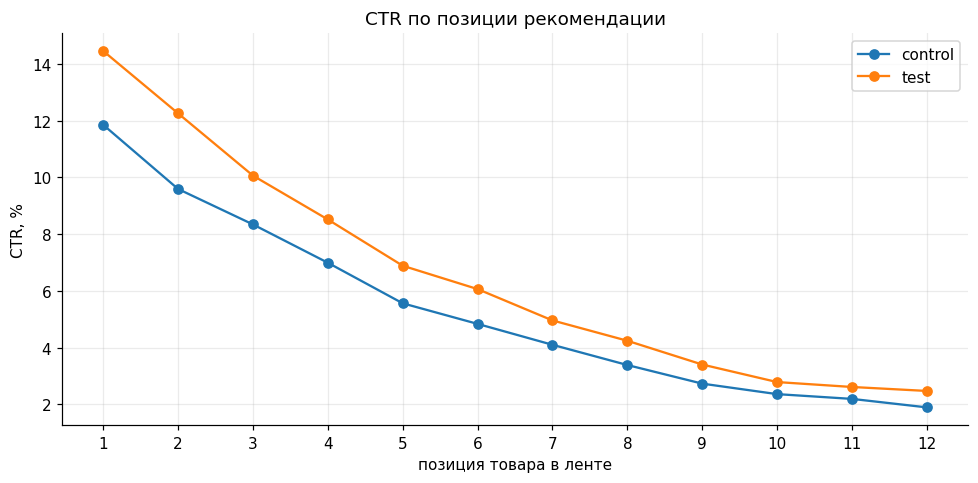

In [71]:
pos = (impr_c.merge(assign_c, on='user_id')
       .groupby(['position', 'experiment_group'])
       .agg(clicks=('is_clicked', 'sum'), impressions=('impression_id', 'size'))
       .reset_index())
pos['ctr'] = pos.clicks / pos.impressions

pos_ctr = pos.pivot(index='position', columns='experiment_group', values='ctr')
pos_n = pos.pivot(index='position', columns='experiment_group', values='impressions')
pos_table = pd.DataFrame({
    'control CTR, %': pos_ctr.control * 100,
    'test CTR, %': pos_ctr.test * 100,
    'uplift, %': (pos_ctr.test / pos_ctr.control - 1) * 100,
    'показов control': pos_n.control.astype(int),
    'показов test': pos_n.test.astype(int),
})
display(pos_table.round(2))

weights = pos.groupby('position').impressions.sum()
weights = weights / weights.sum()
std_control = (pos_ctr.control * weights).sum()
std_test = (pos_ctr.test * weights).sum()

print(f'Сырой uplift CTR: {(r.loc["CTR", "rel_uplift"] * 100):.2f}%')
print(f'Стандартизованный на общий position mix: {(std_test / std_control - 1) * 100:.2f}%')

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(pos_ctr.index, pos_ctr.control * 100, marker='o', label='control')
ax.plot(pos_ctr.index, pos_ctr.test * 100, marker='o', label='test')
ax.set_xlabel('позиция товара в ленте')
ax.set_ylabel('CTR, %')
ax.set_xticks(pos_ctr.index)
ax.set_title('CTR по позиции рекомендации')
ax.legend()
plt.tight_layout()
plt.show()

CTR в test выше **на всех 12 позициях**. На позициях 10-12 показов меньше, поэтому
оценки шумнее, но направление эффекта сохраняется. После приведения обеих групп к одному
распределению позиций uplift равен **23.3%**, почти совпадая с сырым результатом 23.5%.

Следовательно, эффект не создан тем, что test чаще показывал товары наверху. Модель
улучшает вероятность клика внутри одной и той же позиции.

## 4.7 Не объясняется ли рост возвратов товарным миксом

Fashion возвращают чаще других категорий, поэтому рост общей доли возвратов может быть
композиционным: модель могла привести больше заказов именно в Fashion. Это проверка
механизма, а не попытка «вычесть» часть причинного эффекта, категория заказа сама могла
измениться под воздействием модели.

In [72]:
orders_ab = orders_c.merge(assign_c, on='user_id')
cat_ret = (orders_ab.groupby(['category', 'experiment_group'])
           .agg(returns=('is_returned', 'sum'), orders=('order_id', 'size'))
           .reset_index())
cat_ret['return_rate'] = cat_ret.returns / cat_ret.orders

cat_rate = cat_ret.pivot(index='category', columns='experiment_group', values='return_rate')
cat_n = cat_ret.pivot(index='category', columns='experiment_group', values='orders')
cat_show = pd.DataFrame({
    'orders control': cat_n.control.astype(int),
    'orders test': cat_n.test.astype(int),
    'Return Rate control, %': cat_rate.control * 100,
    'Return Rate test, %': cat_rate.test * 100,
    'Δ, п.п.': (cat_rate.test - cat_rate.control) * 100,
})
display(cat_show.round(2).sort_values('Return Rate control, %', ascending=False))

cat_weights = cat_ret.groupby('category').orders.sum()
cat_weights = cat_weights / cat_weights.sum()
std_rr_control = (cat_rate.control * cat_weights).sum()
std_rr_test = (cat_rate.test * cat_weights).sum()

import statsmodels.api as sm
import statsmodels.formula.api as smf
orders_ab['test_flag'] = (orders_ab.experiment_group == 'test').astype(int)
ret_model = smf.glm('is_returned ~ test_flag + C(category)', data=orders_ab,
                    family=sm.families.Binomial()).fit(
                        cov_type='cluster', cov_kwds={'groups': orders_ab.user_id})
coef = ret_model.params['test_flag']
ci = ret_model.conf_int().loc['test_flag']

print(f'Сырой Return Rate: control {r.loc["Return Rate", "control"] * 100:.2f}% | '
      f'test {r.loc["Return Rate", "test"] * 100:.2f}%')
print(f'Стандартизованный по category mix: control {std_rr_control * 100:.2f}% | '
      f'test {std_rr_test * 100:.2f}% | uplift {(std_rr_test / std_rr_control - 1) * 100:.1f}%')
print(f'Категориально скорректированный OR(test): {np.exp(coef):.3f} '
      f'[95% CI {np.exp(ci.iloc[0]):.3f}; {np.exp(ci.iloc[1]):.3f}], '
      f'p={ret_model.pvalues["test_flag"]:.3f}')

,orders control,orders test,"Return Rate control, %","Return Rate test, %","Δ, п.п."
category,,,,,
Fashion,501,732,11.9800,15.8500,3.8700
Electronics,432,647,6.2500,5.5600,-0.6900
Kids,262,344,6.1100,7.8500,1.7400
Home,447,543,6.0400,7.0000,0.9600
Sports,226,322,5.3100,8.7000,3.3900
Auto,171,249,4.6800,4.8200,0.1400
Pet,205,244,3.9000,2.8700,-1.0300
Beauty,389,517,1.8000,2.5100,0.7200
Books,175,247,1.7100,2.4300,0.7100


Сырой Return Rate: control 5.55% | test 6.85%
Стандартизованный по category mix: control 5.62% | test 6.78% | uplift 20.6%
Категориально скорректированный OR(test): 1.227 [95% CI 1.007; 1.496], p=0.042


Fashion действительно имеет самый высокий Return Rate и в test занимает заметную долю заказов.
Но одним миксом рост возвратов не объясняется:

- сырой относительный рост Return Rate составляет **+23.4%**;
- после стандартизации обеих групп на одинаковый набор категорий около **+20.6%**;
- в диагностической логистической модели с контролем категории шансы возврата в test
  выше примерно в **1.23 раза**, нижняя граница 95%-го интервала остаётся чуть выше 1.

Товарный микс объясняет небольшую часть эффекта, основная часть возникает внутри категорий.
Результат пограничный по точности из-за всего 460 возвратов, поэтому его следует считать
серьёзным сигналом риска, а не точной оценкой механизма.

## 4.8 Устойчивость эффекта во времени

Последняя проверка касается того, не был ли средний эффект создан несколькими удачными
днями и не видно ли затухания к концу эксперимента. Для этого считаем CTR отдельно
по каждому дню и сравниваем первую и вторую половину теста.

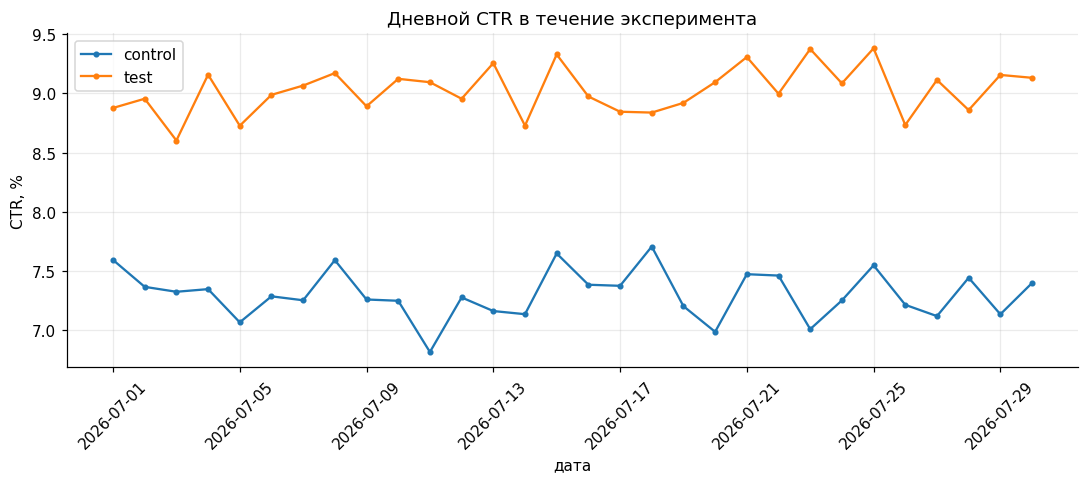

experiment_group,control,test,"uplift, %"
период,,,
1-15 июля,7.2900,8.9900,23.3200
16-30 июля,7.3100,9.0500,23.7800


Дней с положительным uplift: 30 из 30
Диапазон дневного uplift: от 14.7% до 33.8%


In [73]:
daily = impr_c.merge(assign_c, on='user_id').copy()
daily['day'] = daily.event_time.dt.normalize()
daily = (daily.groupby(['day', 'experiment_group'])
         .agg(clicks=('is_clicked', 'sum'), impressions=('impression_id', 'size'))
         .reset_index())
daily['ctr'] = daily.clicks / daily.impressions

daily_ctr = daily.pivot(index='day', columns='experiment_group', values='ctr')
daily_ctr['uplift'] = daily_ctr.test / daily_ctr.control - 1

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(daily_ctr.index, daily_ctr.control * 100, marker='o', markersize=3, label='control')
ax.plot(daily_ctr.index, daily_ctr.test * 100, marker='o', markersize=3, label='test')
ax.set_ylabel('CTR, %')
ax.set_xlabel('дата')
ax.set_title('Дневной CTR в течение эксперимента')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

imp_half = impr_c.merge(assign_c, on='user_id').copy()
imp_half['период'] = np.where(imp_half.event_time.dt.day <= 15, '1-15 июля', '16-30 июля')
half = (imp_half.groupby(['период', 'experiment_group'])
        .agg(clicks=('is_clicked', 'sum'), impressions=('impression_id', 'size')))
half['CTR, %'] = half.clicks / half.impressions * 100

half_pivot = half['CTR, %'].unstack('experiment_group')
half_pivot['uplift, %'] = (half_pivot.test / half_pivot.control - 1) * 100
display(half_pivot.round(2))

print(f'Дней с положительным uplift: {(daily_ctr.uplift > 0).sum()} из {len(daily_ctr)}')
print(f'Диапазон дневного uplift: от {daily_ctr.uplift.min() * 100:.1f}% '
      f'до {daily_ctr.uplift.max() * 100:.1f}%')

Test превосходит control **во все 30 дней**. В первой половине uplift CTR составляет
около 23.3%, во второй 23.8%; признаков затухания внутри месяца не видно. Это снижает
вероятность, что общий результат создан единичным всплеском или техническим сбоем.

При этом 30 дней всё равно недостаточно, чтобы исключить эффект новизны на более длинном
горизонте. Стабильность внутри теста подтверждена, устойчивость после нескольких месяцев нет.

## 4.9 Итог по A/B-тесту

**0. Эксперимент методологически чистый.** Ни один инвариант экспозиции не сдвинулся:
показы на пользователя, сессии, плотность ленты и глубина просмотра остались прежними.
Модель изменила содержание выдачи, а не её объём, поэтому различия в поведении
относятся на счёт качества рекомендаций.

**1. Модель статистически и практически улучшает воронку.** CTR вырос на 23.5%,
Click→Order на 8.6%, конверсия пользователя в заказ на 28.6%, заказы на пользователя
на 33.8%. Эффект сохраняется по дням и внутри позиций ленты.

**2. Денежный эффект существенный и объёмный.** GMV на пользователя вырос на 36.1%,
маржа на пользователя на 32.0%. Средний чек статистически не изменился, поэтому рост
создан расширением числа покупателей и покупок, а не редкими крупными заказами.

**3. Цена роста это возвраты.** Return Rate увеличился на 1.30 п.п. (+23.4%) и остаётся
значимым после поправки на множественные сравнения. Сдвиг в Fashion объясняет лишь
малую часть ухудшения. Это главный подтверждённый guardrail-риск.

Но точность этой оценки низкая: эффект лишь немного превышает порог чувствительности
эксперимента, а интервал тянется от +2.5% до +48.3%. Направление установлено надёжно,
величина нет. Планировать экономику раскатки по центральной оценке в 23.4% нельзя,
считать нужно по диапазону.

**4. Нагрузка на поддержку вырастет, но качество отдельного заказа по тикетам не доказано.**
Пользователей с обращением стало больше, однако рост тикетов на заказ статистически
неотличим от нуля; к тому же история тикетов усечена.

**Вывод именно раздела 4:** новая AI-модель создаёт реальный краткосрочный продуктовый
и денежный эффект. Однако результат ещё не равен рекомендации о полной раскатке:
нужно понять, в каких сегментах возникает рост возвратов, и сопоставить дополнительную
маржу с риском ухудшения пользовательского опыта. Это задачи разделов 5 и 6.

Все денежные оценки остаются верхней границей инкрементального эффекта, поскольку в данных
нет покупок из поиска и других каналов и каннибализацию измерить невозможно.

---

# 5. Сегментационный анализ

Раздел 4 показал средний эффект по всей аудитории. Здесь выясняем, **для кого именно**
новая модель работает лучше и хуже и, что не менее важно, где различий на самом деле нет,
хотя глазами по таблице их легко «увидеть».

Это самый опасный раздел работы с точки зрения ложных выводов, поэтому начинаем
с дисциплины, а не с цифр.

## 5.1 Дизайн сегментного анализа

### Какие признаки можно использовать как сегменты

Сегментировать можно **только по признакам, зафиксированным до воздействия**. Иначе
сегмент сам оказывается следствием эксперимента, и сравнение групп внутри него теряет
защиту рандомизации.

| Признак | Можно? | Почему |
|---|---|---|
| `device`, `region`, `age_group`, `traffic_source` | да | Атрибуты профиля, не меняются от эксперимента |
| `is_premium` (статус на 1 июля) | да | Зафиксирован на старте, см. 1.9 |
| `tenure_bucket` (стаж на старте) | да | Считается от `registration_date`, все регистрации до 1 июля |
| ~~категория заказа~~ | **нет** | Пост-переменная: модель сама меняет товарный микс (проверено в 4.7) |
| ~~число сессий/кликов~~ | **нет** | Пост-переменная: активность выросла под воздействием |
| ~~`premium_converted`~~ | **нет** | Это метрика результата, а не сегмент |

### Проблема множественности, и она здесь главная

Шесть измерений сегментации × пять метрик = **30 проверок**. При α = 0.05 полторы находки
ожидаются просто по случайности. А если смотреть не на измерения, а на отдельные уровни
(3 устройства + 8 регионов + 5 возрастов + 6 источников + 5 когорт стажа + 2 премиум-статуса
= 29 уровней × 5 метрик = 145 сравнений), случайных «побед» будет уже семь.

Поэтому действуем так:

1. Сначала **тест на гетерогенность целиком по измерению**, а не разглядывание уровней.
   Вопрос «различается ли эффект между устройствами вообще» задаётся один раз.
2. Все 30 тестов гетерогенности корректируются **поправкой Холма**.
3. Разбирать отдельные уровни имеет смысл **только внутри тех измерений**, где
   гетерогенность подтвердилась. В остальных наблюдаемый разброс представляет собой шум,
   и «лучший сегмент» там называть нельзя.

### Как считаем гетерогенность

Для каждого уровня сегмента берём log-отношение эффекта `ln(θ_test / θ_control)`
и его стандартную ошибку (та же кластерная линеаризация, что в разделе 4). Затем считаем
**Q-статистику Кокрана**, взвешенную сумму отклонений уровней от общего эффекта.
При однородном эффекте Q распределена как χ² с `k−1` степенями свободы.

Дополнительно приводим **I²**, долю разброса, которая не объясняется случайностью.
Ориентиры: до 25% однородно, выше 75% сильная гетерогенность.

In [74]:
def seg_ratio(s, num, den=None):
    'Точечная оценка отношения и её кластерная стандартная ошибка внутри подвыборки.'
    x = s[num].to_numpy(float)
    y = np.ones(len(s)) if den is None else s[den].to_numpy(float)
    if y.sum() == 0:
        return np.nan, np.nan
    theta = x.sum() / y.sum()
    mu_y = y.mean()
    influence = x - theta * y
    return theta, np.sqrt(influence.var(ddof=1) / (len(s) * mu_y ** 2))


def segment_effects(df, num, den, seg, min_n=30):
    'Эффект по каждому уровню сегмента в log-шкале + доверительные интервалы.'
    rows = []
    for level, g in df.groupby(seg, observed=True):
        c, t = g[g.experiment_group == 'control'], g[g.experiment_group == 'test']
        if len(c) < min_n or len(t) < min_n:
            continue
        th_c, se_c = seg_ratio(c, num, den)
        th_t, se_t = seg_ratio(t, num, den)
        if not (th_c > 0 and th_t > 0):
            continue
        L = np.log(th_t) - np.log(th_c)
        seL = np.hypot(se_t / th_t, se_c / th_c)
        rows.append({'сегмент': str(level), 'n control': len(c), 'n test': len(t),
                     'control': th_c, 'test': th_t,
                     'uplift, %': (np.exp(L) - 1) * 100,
                     'CI низ, %': (np.exp(L - 1.96 * seL) - 1) * 100,
                     'CI верх, %': (np.exp(L + 1.96 * seL) - 1) * 100,
                     'p': 2 * stats.norm.sf(abs(L / seL)),
                     '_L': L, '_seL': seL})
    return pd.DataFrame(rows)


def heterogeneity(eff):
    'Q-тест Кокрана на однородность эффекта между уровнями сегмента.'
    w = 1 / eff._seL ** 2
    L_pooled = (w * eff._L).sum() / w.sum()
    Q = (w * (eff._L - L_pooled) ** 2).sum()
    k = len(eff)
    p = stats.chi2.sf(Q, k - 1) if k > 1 else np.nan
    I2 = max(0.0, (Q - (k - 1)) / Q) * 100 if Q > 0 else 0.0
    return Q, k - 1, p, I2, (np.exp(L_pooled) - 1) * 100


ab_mart['premium_flag'] = np.where(ab_mart.is_premium == 1, 'premium', 'free')
ab_mart['tenure_bucket'] = user_mart['tenure_bucket']

SEG_DIMS = ['device', 'tenure_bucket', 'premium_flag', 'age_group', 'traffic_source', 'region']
SEG_METRICS = [
    ('CTR',                'clicks',      'impressions'),
    ('Конверсия в заказ',  'converted',   None),
    ('GMV на пользователя','gmv',         None),
    ('Маржа на пользователя','margin',    None),
    ('Return Rate',        'returns_all', 'orders'),
]

het_rows, seg_cache = [], {}
for mname, num, den in SEG_METRICS:
    for dim in SEG_DIMS:
        eff = segment_effects(ab_mart, num, den, dim)
        if len(eff) < 2:
            continue
        seg_cache[(mname, dim)] = eff
        Q, dfree, p, I2, pooled = heterogeneity(eff)
        het_rows.append({'метрика': mname, 'измерение': dim, 'уровней': dfree + 1,
                         'Q': round(Q, 2), 'df': dfree, 'p': p,
                         'I², %': round(I2), 'общий uplift, %': round(pooled, 1)})

het = pd.DataFrame(het_rows)
het['p Холма'] = holm_adjust(het.p)
het['гетерогенность'] = np.where(het['p Холма'] < 0.05, 'ДА', 'нет')
print(f'Всего тестов гетерогенности: {len(het)}')
display(het.assign(p=het.p.round(5), **{'p Холма': het['p Холма'].round(4)})
           .sort_values('p').reset_index(drop=True))

Всего тестов гетерогенности: 30


,метрика,измерение,уровней,Q,df,p,"I², %","общий uplift, %",p Холма,гетерогенность
0,CTR,device,3,77.6800,2,0.0000,97,23.4000,0.0000,ДА
1,CTR,tenure_bucket,5,44.9600,4,0.0000,91,23.6000,0.0000,ДА
2,GMV на пользователя,device,3,16.7800,2,0.0002,88,36.2000,0.0063,ДА
3,Конверсия в заказ,device,3,14.7800,2,0.0006,86,28.5000,0.0167,ДА
4,Маржа на пользователя,device,3,9.4800,2,0.0087,79,32.1000,0.2269,нет
5,Return Rate,region,8,14.5100,7,0.0428,52,21.4000,1.0000,нет
6,Return Rate,device,3,5.6200,2,0.0602,64,23.3000,1.0000,нет
7,Конверсия в заказ,tenure_bucket,5,6.5600,4,0.1613,39,28.6000,1.0000,нет
8,Return Rate,tenure_bucket,5,5.4500,4,0.2441,27,21.6000,1.0000,нет
9,Конверсия в заказ,premium_flag,2,1.1200,1,0.2905,10,28.5000,1.0000,нет


Из тридцати проверок поправку Холма переживают **четыре**, и три из них приходятся
на одно и то же измерение, на **устройство**:

| Метрика | Измерение | I² | p Холма |
|---|---|---|---|
| CTR | device | 97% | < 0.0001 |
| CTR | tenure_bucket | 91% | < 0.0001 |
| GMV на пользователя | device | 88% | 0.006 |
| Конверсия в заказ | device | 86% | 0.017 |

Всё остальное однородно. В частности, «маржа × device» имеет сырой p = 0.009, но после
поправки 0.23: сигнал есть, доказательства нет. А эффектный на вид разброс Return Rate
по регионам (сырой p = 0.043, Центральная Россия +127%) после поправки даёт p = 1.00,
то есть это чистый шум, ровно тот случай, ради которого поправка и вводилась.

Дальше разбираем два измерения, где гетерогенность подтверждена.

## 5.2 Устройство, единственный устойчивый разрез

In [75]:
dev_tables = {}
for mname in ['CTR', 'Конверсия в заказ', 'GMV на пользователя', 'Маржа на пользователя']:
    e = seg_cache[(mname, 'device')].copy()
    dev_tables[mname] = e.set_index('сегмент')['uplift, %'].round(1)
    print(f'- {mname} -')
    display(e[['сегмент', 'n control', 'n test', 'control', 'test',
               'uplift, %', 'CI низ, %', 'CI верх, %', 'p']]
           .assign(control=e.control.round(4), test=e.test.round(4))
           .round({'uplift, %': 1, 'CI низ, %': 1, 'CI верх, %': 1, 'p': 4})
           .sort_values('uplift, %', ascending=False).reset_index(drop=True))

- CTR -


,сегмент,n control,n test,control,test,"uplift, %","CI низ, %","CI верх, %",p
0,android,14050,14462,0.0730,0.0945,29.6000,27.4000,31.8000,0.0000
1,web,3746,3758,0.0730,0.0862,18.1000,14.1000,22.1000,0.0000
2,ios,6677,6608,0.0732,0.0831,13.5000,10.6000,16.5000,0.0000


- Конверсия в заказ -


,сегмент,n control,n test,control,test,"uplift, %","CI низ, %","CI верх, %",p
0,android,14050,14462,0.1162,0.1598,37.6000,29.7000,45.9000,0.0000
1,ios,6677,6608,0.1170,0.1421,21.5000,11.2000,32.7000,0.0000
2,web,3746,3758,0.1249,0.1354,8.4000,-3.6000,21.9000,0.1763


- GMV на пользователя -


,сегмент,n control,n test,control,test,"uplift, %","CI низ, %","CI верх, %",p
0,android,14050,14462,201.4840,305.9246,51.8000,39.5000,65.3000,0.0000
1,ios,6677,6608,220.1192,268.0649,21.8000,7.2000,38.3000,0.0024
2,web,3746,3758,222.6191,238.0761,6.9000,-10.0000,27.1000,0.4459


- Маржа на пользователя -


,сегмент,n control,n test,control,test,"uplift, %","CI низ, %","CI верх, %",p
0,android,14050,14462,33.9840,48.7931,43.6000,32.1000,56.0000,0.0000
1,ios,6677,6608,36.8402,43.2672,17.4000,3.7000,33.1000,0.0116
2,web,3746,3758,35.2774,40.9579,16.1000,-2.0000,37.6000,0.0843


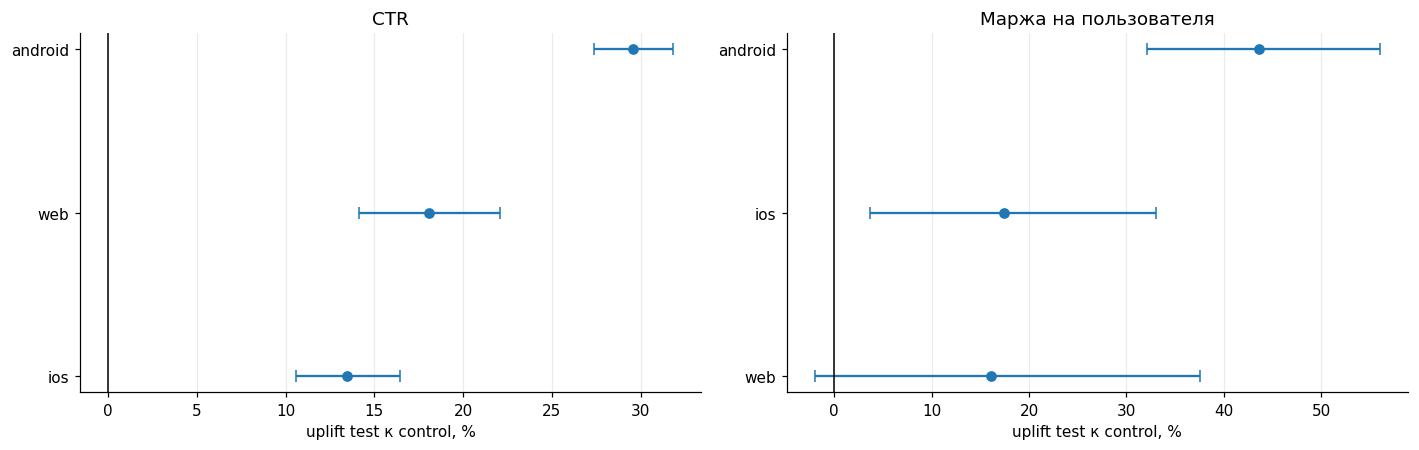

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

for ax, mname in zip(axes, ['CTR', 'Маржа на пользователя']):
    e = seg_cache[(mname, 'device')].sort_values('uplift, %')
    y = np.arange(len(e))
    xerr = np.vstack([e['uplift, %'] - e['CI низ, %'], e['CI верх, %'] - e['uplift, %']])
    ax.errorbar(e['uplift, %'], y, xerr=xerr, fmt='o', capsize=4)
    ax.axvline(0, linewidth=1, color='black')
    ax.set_yticks(y)
    ax.set_yticklabels(e['сегмент'])
    ax.set_xlabel('uplift test к control, %')
    ax.set_title(mname)
    ax.grid(axis='y', alpha=0)

plt.tight_layout()
plt.show()

In [77]:
money = []
for dev, g in ab_mart.groupby('device'):
    c, t = g[g.experiment_group == 'control'], g[g.experiment_group == 'test']
    mc, sc = seg_ratio(c, 'margin')
    mt, st = seg_ratio(t, 'margin')
    rc, _ = seg_ratio(c, 'returns_all', 'orders')
    rt, _ = seg_ratio(t, 'returns_all', 'orders')
    diff, se = mt - mc, np.hypot(st, sc)
    money.append({'устройство': dev, 'пользователей': len(g),
                  'доля аудитории, %': round(len(g) / len(ab_mart) * 100, 1),
                  'маржа control, ₽': round(mc, 2), 'маржа test, ₽': round(mt, 2),
                  'Δ маржи, ₽': round(diff, 2),
                  'CI, ₽': f'[{diff - 1.96 * se:+.2f}; {diff + 1.96 * se:+.2f}]',
                  'p': round(2 * stats.norm.sf(abs(diff / se)), 4),
                  'Return Rate control, %': round(rc * 100, 2),
                  'Return Rate test, %': round(rt * 100, 2)})

money = pd.DataFrame(money).sort_values('Δ маржи, ₽', ascending=False)
total_gain = (money['Δ маржи, ₽'] * money['пользователей']).sum()
money['вклад в общий прирост, %'] = (money['Δ маржи, ₽'] * money['пользователей']
                                     / total_gain * 100).round(1)
display(money.reset_index(drop=True))

,устройство,пользователей,"доля аудитории, %","маржа control, ₽","маржа test, ₽","Δ маржи, ₽","CI, ₽",p,"Return Rate control, %","Return Rate test, %","вклад в общий прирост, %"
0,android,28512,57.8000,33.9800,48.7900,14.8100,[+11.40; +18.21],0.0000,5.4300,6.7500,76.7000
1,ios,13285,26.9000,36.8400,43.2700,6.4300,[+1.47; +11.39],0.0111,4.4400,7.3200,15.5000
2,web,7504,15.2000,35.2800,40.9600,5.6800,[-0.76; +12.12],0.0838,7.8800,6.4600,7.7000


**Эффект убывает от Android к вебу, и по деньгам разрыв драматичнее, чем по кликам.**

По CTR: Android **+29.6%**, веб +18.1%, iOS +13.5%, все три значимы.
По марже на пользователя картина другая: Android **+14.81 ₽** (интервал [+11.40; +18.21]),
iOS +6.43 ₽ (p = 0.011), веб +5.68 ₽, и вот здесь интервал **накрывает ноль**
([−0.76; +12.12], p = 0.084).

Обратите внимание на перестановку: по кликам веб опережает iOS, по деньгам наоборот.
То есть на вебе модель добивается кликов, но они хуже доходят до покупки.

**Решает всё же размер сегмента.** Android это 57.8% аудитории и **76.7% всего прироста маржи**.
iOS даёт 15.5%, веб 7.7%. Даже если бы эффект на вебе был надёжно положительным,
его вклад остался бы маргинальным.

**Оговорка, которую важно проговорить.** По условию задачи эксперимент проводился
на главной странице **мобильного приложения**, а веб-пользователи в данных всё равно
получают показы новой модели и реагируют на них ростом CTR на 18%. Данные и постановка
здесь расходятся. Поэтому слабость веб-сегмента корректнее объяснять не «их не затронули»,
а тем, что это самая маленькая группа (7 504 человека) с самой широкой оценкой.

## 5.3 Стаж: гетерогенность в кликах, которой нет в деньгах

In [78]:
ten = pd.DataFrame({
    'CTR uplift, %':   seg_cache[('CTR', 'tenure_bucket')].set_index('сегмент')['uplift, %'],
    'CTR p':           seg_cache[('CTR', 'tenure_bucket')].set_index('сегмент')['p'],
    'Маржа uplift, %': seg_cache[('Маржа на пользователя', 'tenure_bucket')].set_index('сегмент')['uplift, %'],
    'Маржа CI низ, %': seg_cache[('Маржа на пользователя', 'tenure_bucket')].set_index('сегмент')['CI низ, %'],
    'Маржа CI верх, %':seg_cache[('Маржа на пользователя', 'tenure_bucket')].set_index('сегмент')['CI верх, %'],
}).reindex(['до 1 мес', '1-3 мес', '3-6 мес', '6-12 мес', 'более года'])
display(ten.round(2))

for mname in ['CTR', 'Маржа на пользователя']:
    Q, dfree, p, I2, pooled = heterogeneity(seg_cache[(mname, 'tenure_bucket')])
    print(f'{mname:24} Q={Q:6.2f}  p={p:.4f}  I²={I2:.0f}%')

,"CTR uplift, %",CTR p,"Маржа uplift, %","Маржа CI низ, %","Маржа CI верх, %"
сегмент,,,,,
до 1 мес,32.4100,0.0000,48.7600,24.8800,77.2100
1-3 мес,31.4100,0.0000,33.1900,15.2600,53.9000
3-6 мес,19.8100,0.0000,30.4100,13.2400,50.1700
6-12 мес,18.8400,0.0000,37.2700,20.6700,56.1500
более года,21.0100,0.0000,17.9700,2.7500,35.4400


CTR                      Q= 44.96  p=0.0000  I²=91%
Маржа на пользователя    Q=  4.73  p=0.3158  I²=15%


По CTR стаж расслаивает сильно и монотонно на краях: новички первого месяца дают
**+32.4%**, пользователи со стажем 6-12 месяцев **+18.8%**. Гетерогенность подтверждена
(I² = 91%, p Холма < 0.0001). Объяснение правдоподобное: у нового пользователя нет
накопленной истории, старая система рекомендовала ему хуже всех, и новой модели есть
где отыграться.

**Но до денег это различие не доходит.** По марже на пользователя разброс между когортами
(от +18.0% до +48.8%) статистически неотличим от однородного: Q = 4.73, p = 0.32, I² = 15%.
Интервалы всех пяти когорт широко перекрываются.

Это важный методологический вывод, а не отговорка: **гетерогенность в прокси-метрике
не переносится автоматически на бизнес-метрику**. Если бы мы остановились на CTR
и предложили таргетировать раскатку на новичков, решение опиралось бы на различие,
которого в деньгах нет.

## 5.4 Где различий не нашлось, и почему это результат

In [79]:
flat = het[het['гетерогенность'] == 'нет'].copy()
summary_flat = (flat.groupby('измерение')
                .agg(проверок=('метрика', 'size'),
                     мин_p_Холма=('p Холма', 'min'),
                     макс_I2=('I², %', 'max'))
                .sort_values('мин_p_Холма'))
display(summary_flat.round(3))

for dim in ['premium_flag', 'region']:
    print(f'\n- {dim}: эффект по марже на пользователя -')
    e = seg_cache[('Маржа на пользователя', dim)]
    display(e[['сегмент', 'n control', 'n test', 'uplift, %', 'CI низ, %', 'CI верх, %', 'p']]
            .round({'uplift, %': 1, 'CI низ, %': 1, 'CI верх, %': 1, 'p': 4})
            .sort_values('uplift, %', ascending=False).reset_index(drop=True))

,проверок,мин_p_Холма,макс_I2
измерение,,,
device,2,0.2270,79
age_group,5,1.0000,5
premium_flag,5,1.0000,10
region,5,1.0000,52
tenure_bucket,4,1.0000,39
traffic_source,5,1.0000,0



- premium_flag: эффект по марже на пользователя -


,сегмент,n control,n test,"uplift, %","CI низ, %","CI верх, %",p
0,premium,4011,4139,38.3000,21.8000,57.0000,0.0000
1,free,20462,20689,29.4000,20.2000,39.4000,0.0000



- region: эффект по марже на пользователя -


,сегмент,n control,n test,"uplift, %","CI низ, %","CI верх, %",p
0,Far East,710,728,57.9000,9.9000,126.9000,0.0134
1,Moscow,4397,4460,40.1000,21.0000,62.1000,0.0000
2,Ural,2499,2513,38.6000,12.6000,70.6000,0.0021
3,South,2257,2269,36.8000,11.5000,67.7000,0.0026
4,Volga,4167,4195,35.5000,15.9000,58.5000,0.0001
5,Saint Petersburg,2118,2290,35.0000,8.1000,68.6000,0.0081
6,Siberia,2952,2947,29.2000,7.4000,55.5000,0.0066
7,Central Russia,5373,5426,14.5000,-0.3000,31.6000,0.0552


По четырём измерениям из шести, а именно по премиум-статусу, возрасту, источнику
трафика и региону, гетерогенности нет ни по одной из пяти метрик. Максимальный I²
по этим измерениям не дотягивает до порога, а минимальный скорректированный p-value
равен единице.

Это не пустой результат, а прямое указание для раскатки: **дробить аудиторию
по этим признакам смысла нет**, эффект в них одинаковый. Простая политика раскатки
предпочтительнее сложной, если сложность ничего не добавляет.

Отдельно стоит отметить расхождение с описанием датасета. В README к данным заявлено,
что эффекты гетерогенны «по устройству, категории, региону, премиум-статусу и стажу».
Мы подтверждаем **устройство** и частично **стаж** (только в кликах), но по региону
и премиуму различий не находим. Возможных объяснений два: либо заложенный эффект слабее
разрешающей способности выборки, либо его нет. Разделить эти версии на имеющихся данных
нельзя, поэтому в рекомендации опираемся на то, что подтверждено.

## 5.5 Возвраты по сегментам: адресно снизить риск не получится

In [80]:
rr = seg_cache[('Return Rate', 'device')].copy()
display(rr[['сегмент', 'n control', 'n test', 'control', 'test',
            'uplift, %', 'CI низ, %', 'CI верх, %', 'p']]
        .assign(control=(rr.control * 100).round(2), test=(rr.test * 100).round(2))
        .rename(columns={'control': 'RR control, %', 'test': 'RR test, %'})
        .round({'uplift, %': 1, 'CI низ, %': 1, 'CI верх, %': 1, 'p': 4})
        .sort_values('uplift, %', ascending=False).reset_index(drop=True))

print('Тесты гетерогенности Return Rate по всем измерениям:')
display(het[het.метрика == 'Return Rate'][['измерение', 'Q', 'df', 'p', 'p Холма', 'I², %']]
        .assign(p=lambda d: d.p.round(4), **{'p Холма': lambda d: d['p Холма'].round(3)})
        .sort_values('p').reset_index(drop=True))

print(f'Всего возвратов в очищенных данных: {int(ab_mart.returns_all.sum())}')

,сегмент,n control,n test,"RR control, %","RR test, %","uplift, %","CI низ, %","CI верх, %",p
0,ios,6677,6608,4.4400,7.3200,64.7000,12.9000,140.5000,0.0097
1,android,14050,14462,5.4300,6.7500,24.1000,-2.6000,58.2000,0.0808
2,web,3746,3758,7.8800,6.4600,-18.0000,-46.9000,26.8000,0.3728


Тесты гетерогенности Return Rate по всем измерениям:


,измерение,Q,df,p,p Холма,"I², %"
0,region,14.5100,7,0.0428,1.0000,52
1,device,5.6200,2,0.0602,1.0000,64
2,tenure_bucket,5.4500,4,0.2441,1.0000,27
3,premium_flag,0.8700,1,0.3512,1.0000,0
4,age_group,3.2000,4,0.5250,1.0000,0
5,traffic_source,2.6600,5,0.7527,1.0000,0


Всего возвратов в очищенных данных: 460


Ни по одному измерению рост возвратов не сегментируется надёжно: минимальный
скорректированный p-value равен 1.00. Разброс по устройствам выглядит внушительно
(iOS +64.7%, веб −18.0%), но интервалы огромны и перекрываются, а всё основание метрики
составляют **460 возвратов на обе группы вместе**.

Практический вывод неприятный, но его нужно произнести прямо: **выделить сегмент,
в котором модель не портит возвраты, на этих данных невозможно**. Раскатка «везде,
кроме проблемного сегмента» не является реализуемой стратегией, проблемный сегмент
не идентифицирован.

Управлять риском возвратов придётся не сегментацией аудитории, а другими рычагами:
работой с товарным миксом (в 4.7 показано, что часть роста идёт через Fashion),
порогами уверенности модели или постепенной раскаткой с мониторингом.

## 5.6 Что это значит для раскатки

In [81]:
scenarios = []
for name, subset in [('Полная раскатка (все устройства)', ab_mart),
                     ('Только Android', ab_mart[ab_mart.device == 'android']),
                     ('Android + iOS (без веба)', ab_mart[ab_mart.device != 'web'])]:
    c, t = subset[subset.experiment_group == 'control'], subset[subset.experiment_group == 'test']
    mc, sc = seg_ratio(c, 'margin')
    mt, st = seg_ratio(t, 'margin')
    diff, se = mt - mc, np.hypot(st, sc)
    scenarios.append({
        'сценарий': name,
        'охват аудитории, %': round(len(subset) / len(ab_mart) * 100, 1),
        'Δ маржи на охваченного, ₽': round(diff, 2),
        'uplift, %': round((mt / mc - 1) * 100, 1),
        'суммарный прирост маржи, ₽': round(diff * len(subset), 0),
        'доля макс. прироста, %': np.nan,
    })

sc_df = pd.DataFrame(scenarios)
sc_df['доля макс. прироста, %'] = (sc_df['суммарный прирост маржи, ₽']
                                   / sc_df['суммарный прирост маржи, ₽'].max() * 100).round(1)
display(sc_df)

,сценарий,"охват аудитории, %","Δ маржи на охваченного, ₽","uplift, %","суммарный прирост маржи, ₽","доля макс. прироста, %"
0,Полная раскатка (все устройства),100.0000,11.1800,32.0000,"550,947.0000",100.0000
1,Только Android,57.8000,14.8100,43.6000,"422,236.0000",76.6000
2,Android + iOS (без веба),84.8000,12.1600,34.8000,"508,081.0000",92.2000


Сравнение сценариев показывает, что **сегментная раскатка почти ничего не выигрывает
в деньгах**. Исключение веба поднимает удельный эффект с 32.0% до 34.8%, но сокращает
охват до 84.8% аудитории, и суммарный прирост маржи оказывается **ниже**, чем при полной
раскатке. Раскатка только на Android даёт наибольший удельный эффект, но теряет
почти четверть общего прироста.

Причина арифметическая: слабые сегменты не приносят убытка, они приносят **меньшую прибыль**.
Отрицательного эффекта нет нигде, нижняя граница интервала по вебу равна −0.76 ₽
на пользователя, то есть худший правдоподобный сценарий близок к нулю, а не к потерям.
Исключать такой сегмент незачем.

### Итог раздела 5

1. **Единственное надёжное различие это устройство.** Android получает эффект вдвое
   сильнее iOS по кликам и вдвое с лишним по деньгам, и на него приходится 76.7%
   всего прироста маржи.
2. **Стаж расслаивает клики, но не деньги.** Использовать его как основание
   для таргетирования нельзя.
3. **Премиум, возраст, источник трафика и регион эффект не различают.** Усложнять
   политику раскатки по этим признакам не нужно.
4. **Возвраты не сегментируются.** Стратегия «раскатать всем, кроме сегмента с возвратами»
   недоступна: такой сегмент не найден.
5. **Сегментная раскатка не даёт денежного выигрыша**, она только уменьшает охват.

Отсюда предварительная рамка для раздела 7: вопрос стоит не «на кого раскатывать»,
а **«раскатывать ли вообще и на каких условиях контроля возвратов»**. Экономику
этого решения считаем в разделе 6.

---

# 6. Бизнес-интерпретация результатов

Разделы 4 и 5 дали статистику: что изменилось, насколько точно и для кого. Но
статистическая значимость это не то же самое, что польза для бизнеса. Рост CTR
сам по себе ничего не стоит, если он не доходит до денег; рост Premium Conversion
на 30% может оказаться прибавкой в доли процента аудитории. Здесь разбираем именно
это: что из найденного представляет собой реальную ценность, что нужно измерять точнее,
и какую цену компания платит за рост.

## 6.1 Какие изменения действительно создают ценность

Разделяю метрики на три роли. **Ценность** это то, что напрямую отражается на прибыли
и подтверждено с хорошим запасом точности. **Механизм** это то, что объясняет, почему
ценность возникла, но само по себе ценностью не является: рост кликабельности не стоит
ничего, если он не превращается в заказы. **Требует проверки** значит статистически
заметно, но недостаточно точно или недостаточно однозначно для решения.

In [82]:
value_map = pd.DataFrame([
    ('Маржа на пользователя',  '+32.0%', '[+23.5%; +40.9%]', 'ценность',
     'Прямая прибыль, устойчива почти во всех сегментах (5.2-5.4)'),
    ('GMV на пользователя',    '+36.1%', '[+27.6%; +45.3%]', 'ценность (верхняя граница)',
     'Каннибализация неизмерима (1.13, п.7), трактовать как потолок эффекта'),
    ('CTR',                    '+23.5%', '[+21.2%; +25.9%]', 'механизм',
     'Не ценность сама по себе, ценна тем, что доходит до заказа (см. ниже)'),
    ('Click→Order CR',         '+8.6%',  '[+2.2%; +15.2%]',  'механизм',
     'Показывает, что дополнительные клики не «пустые», качество намерения не упало'),
    ('Заказы на пользователя', '+33.8%', '[+27.9%; +40.0%]', 'механизм → ценность',
     'Основной канал, через который CTR превращается в маржу (94% лог-прироста GMV, см. 4.4)'),
    ('AOV',                    '+1.8%',  '[-2.6%; +6.7%]',   'не подтверждено',
     'Ноль внутри интервала; денежный рост создан количеством, а не размером чека'),
    ('Premium Conversion',     '+30.1%', '[+3.0%; +64.0%]',  'требует проверки',
     'Запас мощности всего 1.38 (см. MDE в 4); база 0.55 п.п., абсолютный эффект мал'),
    ('Return Rate',            '+23.4%', '[+2.5%; +48.3%]',  'цена роста',
     'Реальные издержки, но точность низкая, запас мощности 0.82 (см. 4)'),
    ('Support user rate',      '+50.8%', '[+29.0%; +76.0%]', 'цена роста (заниженная)',
     'Значим и точен, но данные усечены, реальный рост, вероятно, больше (1.7)'),
], columns=['метрика', 'uplift', '95% CI', 'роль', 'комментарий'])

display(value_map)

,метрика,uplift,95% CI,роль,комментарий
0,Маржа на пользователя,+32.0%,[+23.5%; +40.9%],ценность,"Прямая прибыль, устойчива почти во всех сегмен..."
1,GMV на пользователя,+36.1%,[+27.6%; +45.3%],ценность (верхняя граница),"Каннибализация неизмерима (1.13, п.7), трактов..."
2,CTR,+23.5%,[+21.2%; +25.9%],механизм,"Не ценность сама по себе, ценна тем, что доход..."
3,Click→Order CR,+8.6%,[+2.2%; +15.2%],механизм,"Показывает, что дополнительные клики не «пусты..."
4,Заказы на пользователя,+33.8%,[+27.9%; +40.0%],механизм → ценность,"Основной канал, через который CTR превращается..."
5,AOV,+1.8%,[-2.6%; +6.7%],не подтверждено,Ноль внутри интервала; денежный рост создан ко...
6,Premium Conversion,+30.1%,[+3.0%; +64.0%],требует проверки,Запас мощности всего 1.38 (см. MDE в 4); база ...
7,Return Rate,+23.4%,[+2.5%; +48.3%],цена роста,"Реальные издержки, но точность низкая, запас м..."
8,Support user rate,+50.8%,[+29.0%; +76.0%],цена роста (заниженная),"Значим и точен, но данные усечены, реальный ро..."


Главный вывод: **единственная метрика, которую можно класть в основу денежного решения
напрямую, это маржа на пользователя.** Она рассчитана на всю назначенную аудиторию (не
только на покупателей), учитывает и конверсию, и размер чека, и уже включает удар
по возвратам через отрицательную маржу возвращённых заказов (см. 4.4). Остальные
метрики представляют собой либо объяснение механизма, либо ограничение точности, либо цену.

CTR и Click→Order это не ценность, а доказательство того, что ценность настоящая, а не
статистический шум: рост кликов не за счёт разбавления качества (Click→Order тоже
вырос), не за счёт позиции в ленте (4.6) и не за счёт исключённых пользователей (1.12).

## 6.2 Показатели, которые требуют дополнительного анализа

Не всё, что мы посчитали, одинаково надёжно. Собираю метрики с низким запасом
мощности, то есть те, где эффект / MDE близок к единице или меньше (расчёт из раздела 4),
и добавляю два структурных ограничения, которые статистика не ловит вообще.

In [83]:
needs_review = mde[mde['эффект / MDE'] < 2].copy()
reasons = {
    'Premium Conversion': 'Значим, но малая база события (873 конверсии), интервал широкий',
    'Support user rate':  'Значим и точен по доле пользователей, но данные усечены 3 августа (1.7)',
    'Click→Order':        'Значим, но выборка кликов ограничивает точность оценки',
    'Return Rate':        'Значим, но интервал [+2.5%; +48.3%], почти 20-кратный разброс величины',
    'AOV':                'Незначим, но при MDE 6.55% нельзя утверждать, что эффекта нет, только что он мал',
}
needs_review['причина'] = needs_review['метрика'].map(reasons)
display(needs_review[['метрика', 'MDE отн., %', 'наблюдённый эффект, %', 'эффект / MDE', 'причина']])

,метрика,"MDE отн., %","наблюдённый эффект, %",эффект / MDE,причина
8,Premium Conversion,21.7600,30.0900,1.3800,"Значим, но малая база события (873 конверсии),..."
9,Support user rate,38.3200,50.8400,1.3300,"Значим и точен по доле пользователей, но данны..."
1,Click→Order,6.5500,8.5600,1.3100,"Значим, но выборка кликов ограничивает точност..."
7,Return Rate,28.5900,23.3900,0.8200,"Значим, но интервал [+2.5%; +48.3%], почти 20-..."
4,AOV,6.5500,1.7600,0.2700,"Незначим, но при MDE 6.55% нельзя утверждать, ..."


К списку метрик с низкой мощностью добавляются два ограничения, которые не про
точность оценки, а про то, что метрика вообще не в состоянии показать.

**Маржинальность оборота снизилась с 16.66% до 16.16%** (−0.51 п.п., раздел 4.4).
Абсолютная маржа на пользователя всё равно выросла, потому что рост объёма перекрыл
эту эрозию, но каждый дополнительный рубль GMV стал чуть менее прибыльным. Если
тренд на этом не остановится, при дальнейшем масштабировании запас может сократиться.
Стоит отслеживать этот показатель отдельно, а не только абсолютную маржу.

**Каннибализация каналов и долгосрочная ценность в принципе не наблюдаемы в этих
данных** (детально в 1.13, пп. 5 и 7). Все 7 302 заказа происходят из кликов по
рекомендательной ленте; покупок через поиск или прямой переход в датасете нет вовсе.
Значит нельзя отличить, создала ли модель новый спрос или просто перетянула его
из других каналов на том же экране. Все денежные оценки в этом разделе представляют собой
**верхнюю границу** эффекта, не его гарантированную величину.

## 6.3 Компромиссы: рост продаж, качество опыта, операционная нагрузка

Рост маржи не бесплатен. Модель одновременно увеличивает число заказов и повышает
долю тех, что возвращаются или требуют обращения в поддержку. Считаю, сколько именно
дополнительных возвратов и обращений принёс тест, не в процентах, а в штуках, чтобы
масштаб издержек был так же нагляден, как масштаб выгоды.

In [84]:
mc, mt = ab_mart[ab_mart.experiment_group == 'control'], ab_mart[ab_mart.experiment_group == 'test']

rr_control = mc.returns_all.sum() / mc.orders.sum()
expected_returns_test = mt.orders.sum() * rr_control
extra_returns = mt.returns_all.sum() - expected_returns_test

support_rate_control = (mc.tickets > 0).mean()
expected_ticket_users_test = len(mt) * support_rate_control
extra_ticket_users = (mt.tickets > 0).sum() - expected_ticket_users_test

realized_margin_gain = (mt.margin.mean() - mc.margin.mean()) * len(mt)

tradeoff = pd.DataFrame([
    ('Реализованный прирост маржи',      f'{realized_margin_gain:,.0f} ₽',
     f'{len(mt):,} пользователей тестовой группы, 30 дней'),
    ('Возвраты сверх базовой ставки',    f'+{extra_returns:.0f} заказов',
     f'{int(mt.returns_all.sum())} факт vs {expected_returns_test:.0f} ожидалось при ставке control'),
    ('Пользователи с тикетом сверх базы', f'+{extra_ticket_users:.0f} человек',
     f'{int((mt.tickets > 0).sum())} факт vs {expected_ticket_users_test:.0f} ожидалось при ставке control'),
], columns=['показатель', 'величина', 'как считали'])
display(tradeoff)

print('Единицы измерения разные (рубли / штуки), поэтому свести это в один net-эффект')
print('без стоимости одного возврата и одного обращения нельзя, запрос в разделе 8.')

,показатель,величина,как считали
0,Реализованный прирост маржи,"277,457 ₽","24,828 пользователей тестовой группы, 30 дней"
1,Возвраты сверх базовой ставки,+55 заказов,288 факт vs 233 ожидалось при ставке control
2,Пользователи с тикетом сверх базы,+68 человек,202 факт vs 134 ожидалось при ставке control


Единицы измерения разные (рубли / штуки), поэтому свести это в один net-эффект
без стоимости одного возврата и одного обращения нельзя, запрос в разделе 8.


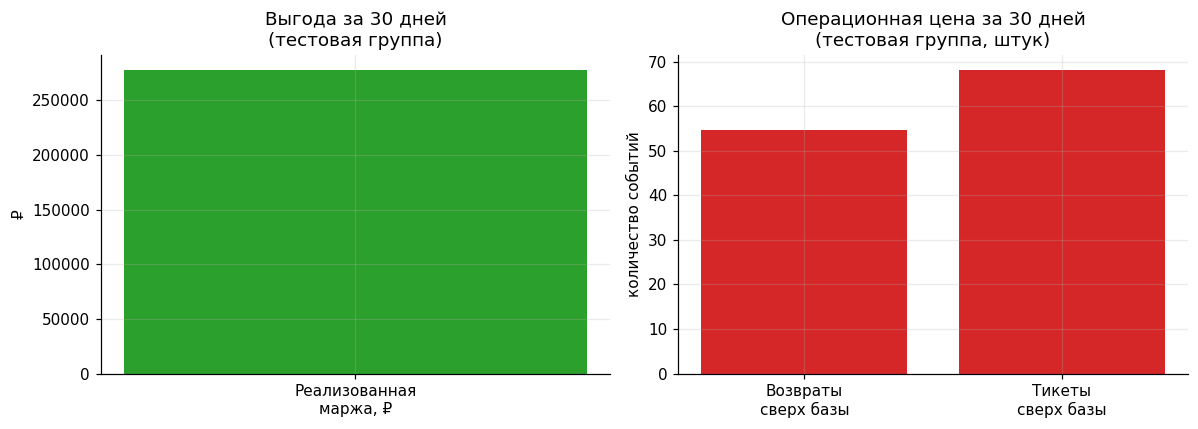

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['Реализованная\nмаржа, ₽'], [realized_margin_gain], color='tab:green')
axes[0].set_title('Выгода за 30 дней\n(тестовая группа)')
axes[0].set_ylabel('₽')

axes[1].bar(['Возвраты\nсверх базы', 'Тикеты\nсверх базы'],
           [extra_returns, extra_ticket_users], color='tab:red')
axes[1].set_title('Операционная цена за 30 дней\n(тестовая группа, штук)')
axes[1].set_ylabel('количество событий')

plt.tight_layout()
plt.show()

За 30 дней тестовая группа принесла компании 277 457 ₽ дополнительной маржи ценой
примерно 55 избыточных возвратов и 68 дополнительных пользователей, обратившихся
в поддержку, то есть **каждые пять тысяч рублей прироста маржи сопровождаются
примерно одним лишним возвратом**. Много это или мало, зависит от стоимости обработки
одного возврата и одного тикета, а этой стоимости в датасете нет.

Именно поэтому строгий вывод здесь ограниченный: экономика роста **выглядит выгодной**
(прирост маржи явно положителен, а операционные объёмы не выглядят катастрофическими
в масштабе всей платформы, 462 возврата и 337 тикетов на 49 301 пользователя за месяц),
но утверждать это с цифрами в руках нельзя, пока неизвестна стоимость единицы возврата
и обращения. Это первый и главный пункт запроса в разделе 8.

## 6.4 Масштаб эффекта: сколько это может стоить компании

Раздел 5.6 уже показал, что раскатка на всю аудиторию даёт **550 947 ₽** маржи
за 30 дней на 49 301 пользователя, больше, чем любой урезанный по сегментам сценарий.
Это ARPU-подобная оценка: наблюдённый месячный эффект, умноженный на размер аудитории.

Здесь пробую сделать на один шаг больше и оценить не месяц, а более длинный горизонт,
то есть выйти на LTV-подобную оценку. Важно сразу сказать: **это не измерение, а
иллюстративный сценарий**. У нас нет предэкспериментальных данных и нет наблюдений
после 30 дня (см. 1.13, п. 4-5), поэтому ничего длиннее месяца эксперимент напрямую
не показывает.

In [86]:
diff_margin_user = mt.margin.mean() - mc.margin.mean()
N_CLEAN = len(ab_mart)

scenarios = pd.DataFrame([
    ('1 месяц (наблюдено напрямую)',
     1, diff_margin_user, diff_margin_user * N_CLEAN,
     'Единственная величина, которую эксперимент фактически измерил'),
    ('3 месяца (эффект сохраняется без изменений)',
     3, diff_margin_user * 3, diff_margin_user * 3 * N_CLEAN,
     'Оптимистично: предполагает отсутствие эффекта новизны и угасания'),
    ('12 месяцев (наивная линейная экстраполяция)',
     12, diff_margin_user * 12, diff_margin_user * 12 * N_CLEAN,
     'Верхняя иллюстративная граница; почти наверняка завышена'),
], columns=['горизонт', 'месяцев', '₽ на пользователя', '₽ на очищенную аудиторию', 'допущение'])

scenarios['₽ на очищенную аудиторию'] = scenarios['₽ на очищенную аудиторию'].round(0)
display(scenarios)

,горизонт,месяцев,₽ на пользователя,₽ на очищенную аудиторию,допущение
0,1 месяц (наблюдено напрямую),1,11.1752,"550,947.0000","Единственная величина, которую эксперимент фак..."
1,3 месяца (эффект сохраняется без изменений),3,33.5255,"1,652,841.0000",Оптимистично: предполагает отсутствие эффекта ...
2,12 месяцев (наивная линейная экстраполяция),12,134.1020,"6,611,362.0000",Верхняя иллюстративная граница; почти наверняк...


Диапазон получается широким, от 551 тысяч рублей в месяц (то, что фактически
измерено) до условных 6.6 млн в наивном годовом пересчёте. Публиковать последнюю
цифру как прогноз было бы ошибкой: линейная экстраполяция игнорирует как минимум
три вещи, которые мы уже знаем из данных. Эффект новизны за 30 дней исключить нельзя
(1.13, п. 3). Возвраты и отток из-за них имеют лаг в 20+ дней и могут проявляться
позже первого месяца использования модели. Смена товарного микса при увеличении
масштаба может отличаться от того, что видно на 6.6% случайной выборки аудитории.

Практический вывод: **551 тысяча рублей за 30 дней это единственная цифра, на
которую можно опираться при принятии решения.** Более длинный горизонт составляет предмет
следующего этапа эксперимента (раздел 7), а не готовую оценку.

## 6.5 Итог раздела 6

1. **Настоящая ценность это маржа на пользователя**, +32.0% с интервалом далеко от нуля,
   устойчива почти во всех сегментах. Остальные продуктовые метрики описывают механизм,
   объясняющий, что рост не является статистическим шумом.
2. **GMV и маржа представляют собой верхнюю границу эффекта**, а не гарантированную
   величину: каннибализация между каналами и долгосрочный отток по данным теста
   не измеримы.
3. **Return Rate, Support rate и Premium Conversion нуждаются в более точных данных**
   до того, как на них можно будет опираться в финансовой модели.
4. **Компромисс реален, но не оценён в деньгах**: 277 тысяч рублей маржи против
   55 избыточных возвратов и 68 обращений в поддержку за тот же период. Соотношение
   выглядит выгодным, но без стоимости единицы операционного события это оценка
   на глаз, а не расчёт.
5. **Единственная цифра, пригодная для решения, это 551 тысяча рублей маржи в месяц**
   при раскатке на всю аудиторию. Экстраполяция на более длинный горизонт представляет
   собой гипотезу, которую нужно проверять, а не факт, на который можно опираться.

Это подводит к разделу 7: рекомендация не может звучать как безусловное «раскатывать
на всех», нужна оговорка про то, что именно ещё нужно узнать в процессе.

---

# 7. Рекомендации руководству

Задание описывает два лагеря внутри компании: одни считают эксперимент успешным
и предлагают раскатать модель на всех как можно быстрее, другие опасаются, что
положительный эффект есть только в отдельных сегментах, а массовый запуск ухудшит
долгосрочные показатели. Данные не подтверждают ни одну из крайних позиций целиком.

## 7.1 Следует ли внедрять модель для всех пользователей

**Нет, не безусловно и не немедленно на 100% аудитории. Рекомендация: поэтапный
запуск с обязательным контролем возвратов, а не одномоментная раскатка и не отказ.**

Аргументы в пользу раскатки весомые: эффект на маржу большой (+32.0%), статистически
надёжный (доверительный интервал далеко от нуля), устойчив во времени (положителен
все 30 дней теста, без признаков затухания, 4.8) и не объясняется артефактами
дизайна (инварианты экспозиции не сдвинулись, 4.2; позиция в ленте роли не играет,
4.6; SRM отсутствует и ковариаты сбалансированы, 1.5).

Но есть и то, что делает немедленную полную раскатку преждевременной:

- **Return Rate вырос на 23.4% с широким интервалом [+2.5%; +48.3%]**, направление
  риска понятно, величина нет (4, 6.2). Раскатывать на 100% значит нести этот риск
  на всю аудиторию, не зная его истинного размера.
- **Веб остаётся единственным сегментом, где эффект статистически не подтверждён**
  (маржа: uplift +16.1%, CI [-2.0%; +37.6%], p = 0.084; см. 5.2). Раскатка на 15.2%
  аудитории без доказанного эффекта это не то же самое, что раскатка на доказанно
  работающий Android.
- **30 дней недостаточно, чтобы исключить эффект новизны** (1.13, п. 3), а линейная
  экстраполяция эффекта на более длинный срок представляет собой гипотезу,
  а не измерение (6.4).
- **GMV и маржа задают верхнюю границу эффекта** из-за неизмеримой каннибализации
  каналов (1.13, п. 7; 6.2).

Итог: данные оправдывают движение вперёд, но не оправдывают закрытие эксперимента
одним решением на всю аудиторию сразу.

## 7.2 Рекомендуемый следующий этап

Предлагаю разделить раскатку на две части, по устройствам, с разной степенью
уверенности, и одновременно расширить измерение вместо того, чтобы останавливать
эксперимент.

In [87]:
plan = pd.DataFrame([
    ('Android', '57.8%', 'Раскатать', 'CTR +29.6%, маржа +43.6%, p < 0.0001 по всем ключевым метрикам (5.2)'),
    ('iOS',     '26.9%', 'Раскатать', 'CTR +13.5%, маржа +17.4%, CI [+3.7%; +33.1%], значим, эффект слабее (5.2)'),
    ('Web',     '15.2%', 'Продолжить тест', 'Маржа CI [-2.0%; +37.6%], p = 0.084, эффект не отличим от нуля (5.2)'),
], columns=['сегмент', 'доля аудитории', 'решение', 'основание'])
display(plan)

print(f'Немедленная раскатка покрывает {28512 + 13285} чел. ({(28512 + 13285) / 49301 * 100:.1f}% очищенной аудитории)')
print(f'и даёт {508081:,.0f} ₽ маржи в месяц, 92.2% от максимума полной раскатки (см. 5.6)')

,сегмент,доля аудитории,решение,основание
0,Android,57.8%,Раскатать,"CTR +29.6%, маржа +43.6%, p < 0.0001 по всем к..."
1,iOS,26.9%,Раскатать,"CTR +13.5%, маржа +17.4%, CI [+3.7%; +33.1%], ..."
2,Web,15.2%,Продолжить тест,"Маржа CI [-2.0%; +37.6%], p = 0.084, эффект не..."


Немедленная раскатка покрывает 41797 чел. (84.8% очищенной аудитории)
и даёт 508,081 ₽ маржи в месяц, 92.2% от максимума полной раскатки (см. 5.6)


Это компромисс между двумя крайностями из постановки задачи. Полная немедленная
раскатка максимизирует ожидаемую выгоду (551 тыс. ₽), но переносит недоказанный
эффект на веб и весь неопределённый риск по возвратам на всю аудиторию сразу.
Полный отказ от раскатки отдаёт 92.2% этой выгоды без необходимости, хотя доказательства
для Android и iOS уже достаточно сильные. Раскатка на Android и iOS с продолжением
теста на web берёт почти всю доказанную выгоду и оставляет наименее доказанный
сегмент под наблюдением, а не под риском.

**Одновременно с раскаткой Android/iOS предлагаю не закрывать эксперимент**, а
перевести его в формат мониторинга:

1. Оставить небольшой контрольный срез (5-10% пользователей Android/iOS) без новой
   модели ещё 60 дней, это единственный способ измерить эффект новизны и получить
   Return Rate и Support Rate без цензурирования по времени (1.7, 1.13 п.1).
2. Продолжить A/B на web в исходном формате до достижения статистической мощности
   по марже (текущий эффект +16.1% при MDE, сопоставимом с уровнем неопределённости,
   нужно либо больше времени, либо больше трафика).
3. Установить алерты по guardrail-метрикам (Return Rate, Support rate) на период
   раскатки: если рост возвратов на полной аудитории превысит верхнюю границу
   наблюдённого интервала (+48.3%), это сигнал остановиться и разбираться, а не
   доводить раскатку до конца по инерции.

## 7.3 Риски, которые необходимо учитывать

In [88]:
risks = pd.DataFrame([
    ('Возвраты',              'Высокий',   'Направление доказано, величина не установлена (CI ×19). При масштабе ошибка в оценке риска умножается на всю аудиторию.'),
    ('Операционная нагрузка', 'Средний',   'Рост обращений в поддержку значим (+50.8%) и, вероятно, занижен из-за усечения данных (1.7).'),
    ('Эффект новизны',        'Средний',   '30 дней не отделяют устойчивый эффект от реакции на новизну ленты (1.13 п.3).'),
    ('Качество роста',        'Низкий',    'Маржинальность оборота снизилась на 0.51 п.п., рост чуть менее эффективен, чем кажется по абсолютным цифрам (4.4).'),
    ('Веб-сегмент',           'Средний',   'Раскатка на недоказанный сегмент означает риск без подтверждённой выгоды (5.2).'),
    ('Каннибализация',        'Неизвестен', 'Не измерима на этих данных, вся оценка GMV/маржи может быть завышена (1.13 п.7).'),
    ('Сбой рандомизации',     'Низкий',    '0.6% пользователей получили двойное назначение из-за бага сервиса; на этот тест не повлияло, но это системный риск для будущих тестов (1.5).'),
], columns=['риск', 'уровень', 'обоснование'])
display(risks)

,риск,уровень,обоснование
0,Возвраты,Высокий,"Направление доказано, величина не установлена ..."
1,Операционная нагрузка,Средний,"Рост обращений в поддержку значим (+50.8%) и, ..."
2,Эффект новизны,Средний,30 дней не отделяют устойчивый эффект от реакц...
3,Качество роста,Низкий,"Маржинальность оборота снизилась на 0.51 п.п.,..."
4,Веб-сегмент,Средний,Раскатка на недоказанный сегмент означает риск...
5,Каннибализация,Неизвестен,"Не измерима на этих данных, вся оценка GMV/мар..."
6,Сбой рандомизации,Низкий,0.6% пользователей получили двойное назначение...


## 7.4 Что нужно исследовать перед полным масштабированием

Коротко, поскольку подробный список данных для запроса вынесен в раздел 8. Здесь фиксирую,
какие вопросы должны получить ответ до решения о раскатке на 100% аудитории,
включая веб:

- Насколько велик Return Rate на самом деле. Нужен более узкий интервал, то есть
  либо больше времени наблюдения, либо больше данных.
- Не угасает ли эффект после 30 дней. Нужен горизонт наблюдения длиннее месяца.
- Насколько эффект на web реален. Нужно либо больше мощности на этом сегменте,
  либо явное решение не запускать его вместе с остальными.
- Какова истинная операционная нагрузка на поддержку без цензурирования данных.
- Компенсирует ли прирост маржи стоимость дополнительных возвратов и обращений.
  Для этого нужна стоимость единицы каждого события, которой в датасете нет.

# 8. Какие дополнительные данные вы запросили бы у продуктовой команды перед окончательным принятием решения?

Список собран из ограничений, которые встретились по ходу всей работы, каждый пункт
ссылается на раздел, где проблема была впервые обнаружена. Отсортирован по тому,
насколько сильно отсутствие данных ограничивает именно решение о раскатке.

In [89]:
requests = pd.DataFrame([
    ('1', 'Стоимость обработки одного возврата и одного тикета поддержки',
     'Перевести компромисс из 6.3 (277 тыс. ₽ маржи против 55 возвратов и 68 тикетов) '
     'в единый денежный net-эффект вместо сопоставления величин в разных единицах', '6.3'),

    ('2', 'История обращений в поддержку за 60+ дней после конца эксперимента '
          '(снять усечение 3 августа)',
     'Получить истинный, а не заниженный размер Support Rate, сейчас известно только, '
     'что он занижен сильнее в тестовой группе (1.7)', '1.7'),

    ('3', 'Данные о заказах вне рекомендательной ленты (поиск, прямой переход, промо) '
          'за период эксперимента',
     'Отделить прирост, созданный моделью, от каннибализации других каналов; '
     'без этого GMV и маржа остаются верхней границей, а не измеренным эффектом (1.13 п.7)', '1.13'),

    ('4', 'Наблюдение за уже назначенными пользователями ещё 60-90 дней '
          '(retention, повторные покупки, LTV)',
     'Отличить устойчивый эффект от эффекта новизны и получить первую реальную '
     'оценку LTV вместо иллюстративной экстраполяции (6.4)', '6.4'),

    ('5', 'Предэкспериментальные данные по активности пользователей (до 1 июля)',
     'Возможность CUPED и A/A-проверки в следующих экспериментах: при том же '
     'размере выборки тест станет мощнее, особенно для Return Rate и Premium Conversion', '1.13'),

    ('6', 'Причина и масштаб сбоя assignment_service_bug в других периодах',
     'Понять, разовый это инцидент или системная проблема сервиса рандомизации, '
     'влияющая на качество будущих экспериментов (1.5)', '1.5'),

    ('7', 'Причина возврата на уровне атрибута товара (размер, цвет, несоответствие фото), '
          'а не только категории',
     'Проверить гипотезу из 4.7: ухудшение внутри категорий, это в целом более '
     'случайные рекомендации или конкретная ошибка (например, по размерной сетке)', '4.7'),

    ('8', 'Экономика Premium-подписки: стоимость привлечения и LTV подписчика',
     'Оценить, насколько прирост Premium Conversion (+30.1%, но на малой базе) '
     'вообще значим для бизнеса в деньгах (6.1)', '6.1'),

    ('9', 'Текущая пропускная способность службы поддержки и логистики возвратов',
     'Понять, выдержит ли операционная команда рост нагрузки при раскатке '
     'на всю аудиторию, а не только на 25 тыс. пользователей теста (7.3)', '7.3'),

    ('10', 'Отдельный, статистически мощный тест на веб-аудитории',
     'Текущий эффект на web не отличим от нуля (p = 0.084), нужно понять, '
     'это отсутствие эффекта или недостаток данных (5.2, 7.2)', '5.2'),
], columns=['№', 'что запросить', 'зачем', 'раздел'])

display(requests[['№', 'что запросить', 'зачем', 'раздел']])

,№,что запросить,зачем,раздел
0,1,Стоимость обработки одного возврата и одного т...,Перевести компромисс из 6.3 (277 тыс. ₽ маржи ...,6.3
1,2,История обращений в поддержку за 60+ дней посл...,"Получить истинный, а не заниженный размер Supp...",1.7
2,3,Данные о заказах вне рекомендательной ленты (п...,"Отделить прирост, созданный моделью, от канниб...",1.13
3,4,Наблюдение за уже назначенными пользователями ...,Отличить устойчивый эффект от эффекта новизны ...,6.4
4,5,Предэкспериментальные данные по активности пол...,Возможность CUPED и A/A-проверки в следующих э...,1.13
5,6,Причина и масштаб сбоя assignment_service_bug ...,"Понять, разовый это инцидент или системная про...",1.5
6,7,Причина возврата на уровне атрибута товара (ра...,Проверить гипотезу из 4.7: ухудшение внутри ка...,4.7
7,8,Экономика Premium-подписки: стоимость привлече...,"Оценить, насколько прирост Premium Conversion ...",6.1
8,9,Текущая пропускная способность службы поддержк...,"Понять, выдержит ли операционная команда рост ...",7.3
9,10,"Отдельный, статистически мощный тест на веб-ау...",Текущий эффект на web не отличим от нуля (p = ...,5.2


### Как это меняет уверенность в решении на наш взгляд:

Пункты 1-4 самые важные: без них решение о полной раскатке принимается с известными
дырами в экономике (нет цены возвратов), в измерении эффекта (нет каннибализации)
и во времени (нет данных дальше 30 дня). Пункты 5-6 не блокируют текущее решение,
но повышают качество последующих экспериментов. Пункты 7-10 уточняют детали,
которые помогут точнее нацелить раскатку, но не меняют её принципиальную логику.

Если бы пришлось принимать решение прямо сейчас, без этих данных, рекомендация
осталась бы прежней: раскатка на Android и iOS с продолжением контролируемого
наблюдения на web и по возвратам (раздел 7). Разница в том, что без пунктов 1-4
это решение опирается на разумную оценку, а с ними на измеренный результат.